# Initialization

### Imports

In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import numpy as np
import tqdm as tqdm_package
from tqdm.notebook import tqdm
from scipy.integrate import odeint
from torch.nn.modules.normalization import LocalResponseNorm

from torch.func import jacrev, vmap

import neurodiffeq
from neurodiffeq import diff
from neurodiffeq.conditions import (
    IVP,
    DirichletBVP,
    DirichletBVP2D,
    BundleIVP,
    NoCondition,
    BundleDirichletBVP,
)
from neurodiffeq.solvers import *
from neurodiffeq.networks import FCNN, SinActv
from neurodiffeq.monitors import Monitor1D
from neurodiffeq.generators import (
    Generator1D,
    Generator2D,
    PredefinedGenerator,
    BaseGenerator,
    PredefinedGenerator,
)
from neurodiffeq.callbacks import ActionCallback
from neurodiffeq import diff
from datetime import datetime
from typing import Callable, Optional, Any

import os
import sys
import random
import copy as copy
import cmath as cmath
import types
import subprocess
import platform
import time
import inspect
import warnings
import json
from copy import deepcopy
from warnings import warn
import zipfile
import re
from collections import defaultdict

from skfem import MeshLine, Basis, ElementLineP1, BilinearForm, asm, condense, solve
from skfem.helpers import grad

import seaborn as sns
from cycler import cycler
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
from dataclasses import dataclass, field

from typing import Callable, Optional, Dict, Tuple

Array = np.ndarray

### Helpers

In [ ]:
def _sync_if_needed():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

### Package versions

In [ ]:
import sys
sys.path.append("./src")

from helpers import get_version, save_reproducibility_snapshot, is_colab, set_paper_style

In [ ]:
package_versions = {
    "python": sys.version,
    "torch": get_version(torch),
    "numpy": get_version(np),
    "tqdm": get_version(tqdm_package),
    "scipy": get_version(__import__("scipy")),
    "neurodiffeq": get_version(neurodiffeq),
    "seaborn": get_version(sns),
    "cycler": get_version(__import__("cycler")),
    "matplotlib": get_version(__import__("matplotlib")),
}

with open("imported_packages_versions.txt", "w") as f:
    for k, v in package_versions.items():
        f.write(f"{k}: {v}\n")

{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'torch': '2.10.0+cpu', 'numpy': '2.0.2', 'tqdm': '4.67.3', 'scipy': '1.16.3', 'neurodiffeq': '0.6.3-dev', 'seaborn': '0.13.2', 'cycler': '0.12.1', 'matplotlib': '3.10.0'}


In [ ]:
save_reproducibility_snapshot()

### Google Drive connect

In [ ]:
if is_colab():
    from google.colab import drive

    mount_path = "/content/drive"
    drive.mount(mount_path)

    dir_path = "/content/drive/MyDrive/Colab Notebooks/Diploma/D28"

    os.chdir(dir_path)

Mounted at /content/drive


### Plots setup

In [ ]:
set_paper_style()

### Random state generator

In [ ]:
seed = 42


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(seed)

### Save functions

In [ ]:
def load_matching_state_dict(model, state_dict):
    model_dict = model.state_dict()

    filtered_state = {
        k: v
        for k, v in state_dict.items()
        if k in model_dict and model_dict[k].shape == v.shape
    }

    skipped = {
        k: {"checkpoint": tuple(v.shape), "model": tuple(model_dict[k].shape)}
        for k, v in state_dict.items()
        if k in model_dict and model_dict[k].shape != v.shape
    }

    unexpected = {
        k: tuple(v.shape) for k, v in state_dict.items() if k not in model_dict
    }

    model.load_state_dict(filtered_state, strict=False)

    return {"skipped_shape_mismatch": skipped, "unexpected_keys": unexpected}


def _normalize_optimizer_checkpoint_name(name):
    if name is None:
        return None

    normalized = str(name).strip().lower().replace("-", "_").replace(" ", "_")
    aliases = {
        "l_bfgs": "lbfgs",
        "torch.optim.adam": "adam",
        "torch.optim.lbfgs": "lbfgs",
    }
    return aliases.get(normalized, normalized)


def _get_optimizer_checkpoint_name(solver):
    optimizer = getattr(solver, "optimizer", None)
    explicit_name = getattr(solver, "optimizer_name", None)
    if explicit_name is not None:
        return _normalize_optimizer_checkpoint_name(explicit_name)
    if optimizer is None:
        return None
    return _normalize_optimizer_checkpoint_name(optimizer.__class__.__name__)


def _resolve_optimizer_for_checkpoint(solver, checkpoint, optimizer_lookup=None):
    saved_name = _normalize_optimizer_checkpoint_name(checkpoint.get("optimizer_name"))
    current_optimizer = getattr(solver, "optimizer", None)
    current_name = _normalize_optimizer_checkpoint_name(getattr(solver, "optimizer_name", None))
    if current_name is None and current_optimizer is not None:
        current_name = _normalize_optimizer_checkpoint_name(current_optimizer.__class__.__name__)

    if saved_name is None:
        return current_optimizer, current_name

    candidates = {}
    if optimizer_lookup:
        candidates.update(
            {
                _normalize_optimizer_checkpoint_name(name): optimizer
                for name, optimizer in optimizer_lookup.items()
                if optimizer is not None
            }
        )

    named_attrs = {
        "adam": getattr(solver, "adam_optimizer", None),
        "lbfgs": getattr(solver, "lbfgs_optimizer", None),
    }
    for name, optimizer in named_attrs.items():
        if optimizer is not None:
            candidates[name] = optimizer

    if current_optimizer is not None and current_name is not None:
        candidates.setdefault(current_name, current_optimizer)

    resolved_optimizer = candidates.get(saved_name)
    if resolved_optimizer is None:
        available = ", ".join(sorted(candidates)) or "none"
        raise ValueError(
            f"Checkpoint was saved with optimizer '{saved_name}', but no matching "
            f"optimizer is available on the current solver. Available: {available}"
        )

    return resolved_optimizer, saved_name


def save_nets(path, solver, save_optimizer=True):
    nets = solver.all_nets
    n_rows, n_cols = nets.shape

    H_state = []
    head_state = []

    for i in range(n_rows):
        H_state.append(nets[i, 0].H_model.state_dict())
        for j in range(n_cols):
            head_state.append(nets[i, j].head_model.state_dict())

    best_nets_state = []
    best_nets_list = solver.best_nets_list

    if isinstance(best_nets_list, (list, tuple, np.ndarray)):
        for row in best_nets_list:
            if not isinstance(row, (list, tuple, np.ndarray)):
                continue

            row_state = []
            for net in row:
                if not hasattr(net, "H_model") or not hasattr(net, "head_model"):
                    continue

                row_state.append(
                    {
                        "H_model": net.H_model.state_dict(),
                        "head_model": net.head_model.state_dict(),
                    }
                )

            best_nets_state.append(row_state)

    checkpoint = {
        "H_state": H_state,
        "head_state": head_state,
        "best_nets_state": best_nets_state,
        "n_rows": n_rows,
        "n_cols": n_cols,
        "global_epoch": solver.global_epoch,
        "train_loss": solver.metrics_history["train_loss"],
        "add_loss": solver.metrics_history["add_loss"],
    }

    if save_optimizer and hasattr(solver, "optimizer") and solver.optimizer is not None:
        checkpoint["optimizer_name"] = _get_optimizer_checkpoint_name(solver)
        checkpoint["optimizer_state"] = solver.optimizer.state_dict()

    torch.save(checkpoint, path)


def load_nets(
    path,
    solver,
    load_heads=True,
    load_optimizer=False,
    load_best_nets=False,
    map_location="cpu",
    optimizer_lookup=None,
):
    checkpoint = torch.load(path, map_location=map_location, weights_only=False)

    H_state = checkpoint["H_state"]
    head_state = checkpoint["head_state"]
    n_rows, n_cols = solver.all_nets.shape

    ckpt_rows = checkpoint.get("n_rows")
    ckpt_cols = checkpoint.get("n_cols")

    if ckpt_rows is not None and ckpt_cols is not None:
        if ckpt_rows != n_rows or ckpt_cols != n_cols:
            print(
                f"Checkpoint shape {(ckpt_rows, ckpt_cols)} "
                f"does not match solver shape {(n_rows, n_cols)}"
            )

    if load_optimizer:
        optimizer_state = checkpoint.get("optimizer_state")
        if optimizer_state is None:
            raise ValueError("Checkpoint does not contain optimizer_state")
        optimizer, optimizer_name = _resolve_optimizer_for_checkpoint(
            solver,
            checkpoint,
            optimizer_lookup=optimizer_lookup,
        )
        optimizer.load_state_dict(optimizer_state)
        solver.optimizer = optimizer
        solver.optimizer_name = optimizer_name

    if checkpoint.get("train_loss") is not None:
        solver.metrics_history["train_loss"] = checkpoint["train_loss"]

    if checkpoint.get("add_loss") is not None:
        solver.metrics_history["add_loss"] = checkpoint["add_loss"]

    max_rows = min(n_rows, len(H_state))

    for i in range(max_rows):
        load_matching_state_dict(solver.all_nets[i, 0].H_model, H_state[i])

        if load_heads:
            for j in range(n_cols):
                idx = i * n_cols + j
                if idx >= len(head_state):
                    continue

                load_matching_state_dict(
                    solver.all_nets[i, j].head_model, head_state[idx]
                )

    if load_best_nets:
        best_nets_state = checkpoint.get("best_nets_state")
        if best_nets_state is not None:
            if len(best_nets_state) != len(solver.best_nets_list):
                raise ValueError("best_nets_list outer size does not match checkpoint")

            for i, row_state in enumerate(best_nets_state):
                if len(row_state) != len(solver.best_nets_list[i]):
                    raise ValueError(f"best_nets_list inner size mismatch at row {i}")

                for j, net_state in enumerate(row_state):
                    solver.best_nets_list[i][j].H_model.load_state_dict(
                        net_state["H_model"]
                    )
                    if load_heads:
                        solver.best_nets_list[i][j].head_model.load_state_dict(
                            net_state["head_model"]
                        )

    return solver, checkpoint["global_epoch"]

# Environment Setup

### Vizualization functions

#### Plot specific runs

In [ ]:
def ema(x, alpha=0.05):
    x = np.asarray(x)
    y = np.zeros_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i - 1]
    return y

In [ ]:
def plot_specific_runs(
    data,
    equation_name,
    models,
    metric="mse",
    head_idx=(0,),
    use_ema=False,
    start_from=None,
    title=None,
):
    data = data[equation_name]

    if not isinstance(head_idx, (list, tuple)):
        head_idx = [head_idx]

    def get_metric_data(model, head):
        if metric in {"mae", "mse", "l2_rel"}:
            return data[model][metric][head]

        if metric == "add_loss":
            if "None" in model:
                return None
            return [v for v in data[model][metric] if v != 0.0]

        return data[model][metric]

    plt.figure(figsize=(8, 5))

    for head in head_idx:
        for model in models:
            model_data = get_metric_data(model, head)

            if model_data is None:
                continue

            if start_from is not None:
                model_data = model_data[start_from:]

            x = np.arange(len(model_data))

            if use_ema:
                plt.plot(
                    x,
                    ema(model_data, alpha=0.2),
                    linestyle="--",
                    label=f"EMA {model} (head {head})",
                )

            plt.plot(
                x,
                model_data,
                linestyle="-",
                label=f"Raw {model} (head {head})",
            )

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel(metric)

    plot_title = title or f"{metric.upper()} comparison: {equation_name}, Heads {head_idx}"
    plt.title(plot_title)

    plt.legend()
    plt.grid(True)
    plt.show()

#### Save metrics

In [ ]:
def save_metrics_plots_across_heads(results):
    for result in results:
        for metric in ["mse", "mae", "l2_rel"]:
            m_cb = result["metric_cb"]

            save_dir = f"{result["save_dir"]}/plots/{metric}"

            os.makedirs(save_dir, exist_ok=True)

            if metric == "mae":
                data = m_cb.mae
            elif metric == "mse":
                data = m_cb.mse
            elif metric == "l2_rel":
                data = m_cb.mse

            for head in range(len(data)):
                plt.figure()
                plt.loglog(True)
                plt.plot(np.arange(0, len(data[head])), data[head])
                plt.title(f"{metric.upper()} for head #{head}")
                plt.xlabel("Step")
                plt.ylabel(metric.upper())
                plt.savefig(os.path.join(save_dir, f"{metric}_head_{head}.png"))
                plt.close()

#### 1D

In [ ]:
def plot_solution_times(
    num_solver,
    times=(0.0, 0.2, 0.5, 0.8),
    r=0.01,
    dt=0.001,
    dx=0.0001,
    x_left=0.0,
    x_right=1.0,
    title="Exact solution",
):
    plt.figure(figsize=(8, 5))

    for t in times:
        x, _, u_ref = num_solver(r, dt, t, 0, x_left, x_right, dx)

        x = x.cpu().detach().numpy() if torch.is_tensor(x) else np.asarray(x)
        u_ref = (
            u_ref.cpu().detach().numpy()
            if torch.is_tensor(u_ref)
            else np.asarray(u_ref)
        )

        plt.plot(x, u_ref, linewidth=2, label=f"Solution at t = {t}")

    plt.xlabel("x")
    plt.ylabel("u(x, t)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_1d_solution_comparison_few(
    x,
    reference,
    regularized,
    vanilla,
    reference_label="Reference",
    regularized_label="Regularized",
    vanilla_label="Vanilla",
    error_label="Absolute Error",
    title_solution="Solution",
    title_error="Pointwise Error",
    filename=None,
    save_dir="."
):
    x = x.cpu().detach().numpy() if torch.is_tensor(x) else np.asarray(x)
    reference = reference.cpu().detach().numpy() if torch.is_tensor(reference) else np.asarray(reference)
    regularized = regularized.cpu().detach().numpy() if torch.is_tensor(regularized) else np.asarray(regularized)
    vanilla = vanilla.cpu().detach().numpy() if torch.is_tensor(vanilla) else np.asarray(vanilla)

    regularized_error = np.abs(regularized - reference)
    vanilla_error = np.abs(vanilla - reference)

    regularized_max_error = regularized_error.max()
    vanilla_max_error = vanilla_error.max()

    regularized_l2re = np.sqrt(np.sum((regularized - reference) ** 2) / np.sum(reference ** 2))
    vanilla_l2re = np.sqrt(np.sum((vanilla - reference) ** 2) / np.sum(reference ** 2))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(x, reference, "k-", linewidth=2, label=reference_label, alpha=0.8)
    ax1.plot(x, regularized, "r--", linewidth=2, label=regularized_label, alpha=0.7)
    ax1.plot(x, vanilla, "g-.", linewidth=2, label=vanilla_label, alpha=0.7)
    ax1.set_xlabel("x", fontsize=11)
    ax1.set_ylabel("u(x)", fontsize=11)
    ax1.set_title(
        f"Regularized L2RE: {regularized_l2re:.2e} | Vanilla L2RE: {vanilla_l2re:.2e}",
        fontsize=11
    )
    ax1.legend(loc="best", frameon=False)
    ax1.grid(True, alpha=0.3)

    ax2.plot(x, regularized_error, "r--", linewidth=1.5, label=f"{regularized_label} error", alpha=0.8)
    ax2.plot(x, vanilla_error, "g-.", linewidth=1.5, label=f"{vanilla_label} error", alpha=0.8)
    ax2.set_xlabel("x", fontsize=11)
    ax2.set_ylabel(error_label, fontsize=11)
    ax2.set_title(
        f"Regularized max: {regularized_max_error:.2e} | Vanilla max: {vanilla_max_error:.2e}",
        fontsize=11
    )
    ax2.legend(loc="best", frameon=False)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    if filename is not None:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches="tight")

    plt.show()

In [ ]:
def plot_1d_solution_comparison(
    x,
    pred,
    exact,
    pred_label="Predicted",
    exact_label="Exact",
    error_label="|Error|",
    title_solution="Solution",
    title_error="Pointwise Error",
    filename=None,
    save_dir="."
):
    x = x.cpu().detach().numpy() if torch.is_tensor(x) else np.asarray(x)
    pred = pred.cpu().detach().numpy() if torch.is_tensor(pred) else np.asarray(pred)
    exact = exact.cpu().detach().numpy() if torch.is_tensor(exact) else np.asarray(exact)

    error = np.abs(pred - exact)
    max_error = error.max()
    l2re = np.sqrt(np.sum((pred - exact) ** 2) / np.sum(exact ** 2))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(x, exact, "k-", linewidth=2, label=exact_label, alpha=0.8)
    ax1.plot(x, pred, "r--", linewidth=2, label=pred_label, alpha=0.7)
    ax1.set_xlabel("x", fontsize=11)
    ax1.set_ylabel("u(x)", fontsize=11)
    ax1.set_title(f"L2RE: {l2re:.2e}", fontsize=11)
    ax1.legend(loc="best", frameon=False)
    ax1.grid(True, alpha=0.3)

    ax2.plot(x, error, "b-", linewidth=1.5, alpha=0.8)
    ax2.set_xlabel("x", fontsize=11)
    ax2.set_ylabel(error_label, fontsize=11)
    ax2.set_title(f"Max: {max_error:.2e}", fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    if filename is not None:
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches="tight")

    plt.show()

#### Heatmap

In [ ]:
def plot_solution_heatmap(
    exact_solution,
    prediction,
    x,
    t,
    pred_label="Prediction",
    exact_label="Exact solution",
    error_label="Absolute Error",
):
    exact_solution = (
        exact_solution.detach().cpu().numpy()
        if torch.is_tensor(exact_solution)
        else np.asarray(exact_solution)
    )
    prediction = (
        prediction.detach().cpu().numpy()
        if torch.is_tensor(prediction)
        else np.asarray(prediction)
    )
    x = x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)
    t = t.detach().cpu().numpy() if torch.is_tensor(t) else np.asarray(t)

    err = np.abs(exact_solution - prediction)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    plt.subplots_adjust(wspace=0.28)

    vmin_sol = min(exact_solution.min(), prediction.min())
    vmax_sol = max(exact_solution.max(), prediction.max())

    im1 = axes[0].imshow(
        prediction,
        extent=[x.min(), x.max(), t.min(), t.max()],
        origin="lower",
        aspect="auto",
        cmap="jet",
        vmin=vmin_sol,
        vmax=vmax_sol,
    )
    axes[0].set_title(pred_label)
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("t")
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    im2 = axes[1].imshow(
        exact_solution,
        extent=[x.min(), x.max(), t.min(), t.max()],
        origin="lower",
        aspect="auto",
        cmap="jet",
        vmin=vmin_sol,
        vmax=vmax_sol,
    )
    axes[1].set_title(exact_label)
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("t")
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    im3 = axes[2].imshow(
        err,
        extent=[x.min(), x.max(), t.min(), t.max()],
        origin="lower",
        aspect="auto",
        cmap="hot",
    )
    axes[2].set_title(error_label)
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("t")
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(t.min(), t.max())

    plt.tight_layout()
    plt.show()

### Numerical solvers

In [ ]:
def solve_burgers(r, dt, T, idx, x_left, x_right, dx):
    nsteps = int(T / dt)

    def burgers_profile(x, idx=0):
        return -np.sin(np.pi * x + idx * (np.pi / 6.0))

    mesh = MeshLine(np.arange(x_left, x_right + dx, dx))
    basis = Basis(mesh, ElementLineP1())

    @BilinearForm
    def mass(u, v, w):
        return u * v

    @BilinearForm
    def diffusion(u, v, w):
        return r * grad(u)[0] * grad(v)[0]

    @BilinearForm
    def convection(u, v, w):
        return w.u_prev * grad(u)[0] * v

    M = asm(mass, basis)
    K = asm(diffusion, basis)

    x = basis.doflocs[0]
    u = burgers_profile(x, idx).copy()
    u0 = u.copy()

    D = basis.get_dofs(lambda X: np.isclose(X[0], x_left) | np.isclose(X[0], x_right))

    for n in range(nsteps):
        u_prev_h = basis.interpolate(u)
        C = asm(convection, basis, u_prev=u_prev_h)

        A = M / dt + C + K
        b = M @ (u / dt)

        x_bc = np.zeros(basis.N)
        x_bc[D.flatten()] = 0.0

        AII, bI, xI, I = condense(A, b, D=D, x=x_bc)
        u = xI.copy()
        u[I] = solve(AII, bI)

    return x, u0, u

In [ ]:
def solve_allen_cahn(r, dt, T, idx, x_left, x_right, dx, reaction_coef = 5):
    nsteps = int(T / dt)

    def ac_profile(x, idx=0):
        return x**2 * np.cos(np.pi * x + idx * np.pi / 6.0)

    def ac_ic(idx=0):
        def f(x):
            return ac_profile(x, idx)
        return f

    def ac_bc_left(x_left, idx=0):
        return ac_profile(np.array([x_left]), idx)[0]

    def ac_bc_right(x_right, idx=0):
        return ac_profile(np.array([x_right]), idx)[0]

    mesh = MeshLine(np.arange(x_left, x_right + dx, dx))
    basis = Basis(mesh, ElementLineP1())

    @BilinearForm
    def mass(u, v, w):
        return u * v

    @BilinearForm
    def diffusion(u, v, w):
        return r * grad(u)[0] * grad(v)[0]

    M = asm(mass, basis)
    K = asm(diffusion, basis)

    x = basis.doflocs[0]
    u = ac_ic(idx)(x).copy()
    u0 = u.copy()

    left_dofs = basis.get_dofs(lambda X: np.isclose(X[0], x_left))
    right_dofs = basis.get_dofs(lambda X: np.isclose(X[0], x_right))
    D = basis.get_dofs(lambda X: np.isclose(X[0], x_left) | np.isclose(X[0], x_right))

    u_bc = np.zeros(basis.N)
    u_bc[left_dofs.flatten()] = ac_bc_left(x_left, idx)
    u_bc[right_dofs.flatten()] = ac_bc_right(x_right, idx)

    u[left_dofs.flatten()] = u_bc[left_dofs.flatten()]
    u[right_dofs.flatten()] = u_bc[right_dofs.flatten()]

    A = M / dt + K

    for _ in range(nsteps):
        reaction = reaction_coef * (u - u**3)
        b = M @ (u / dt + reaction)
        u = solve(*condense(A, b, D=D, x=u_bc))

    return x, u0, u

In [ ]:
def solve_fisher_kpp(r, dt, T, idx, x_left, x_right, dx, D=1):
    nsteps = round(T / dt)
    idx += 1

    def fisher_ic_np(x, k):
        xi = (x - x_left) / (x_right - x_left)
        return (np.exp(-k * xi) - np.exp(-k)) / (1.0 - np.exp(-k))

    npoints = int(round((x_right - x_left) / dx)) + 1
    mesh = MeshLine(np.linspace(x_left, x_right, npoints))
    basis = Basis(mesh, ElementLineP1())

    @BilinearForm
    def mass(u, v, w):
        return u * v

    @BilinearForm
    def diffusion(u, v, w):
        return D * grad(u)[0] * grad(v)[0]

    M = asm(mass, basis)
    K = asm(diffusion, basis)

    x = basis.doflocs[0]
    u = fisher_ic_np(x, idx).copy()
    u0 = u.copy()

    left_dofs = basis.get_dofs(lambda X: np.isclose(X[0], x_left))
    right_dofs = basis.get_dofs(lambda X: np.isclose(X[0], x_right))
    bc_dofs = basis.get_dofs(
        lambda X: np.isclose(X[0], x_left) | np.isclose(X[0], x_right)
    )

    u_bc = np.zeros(basis.N)
    u_bc[left_dofs.flatten()] = 1.0
    u_bc[right_dofs.flatten()] = 0.0

    A = M / dt + K

    for _ in range(nsteps):
        reaction = r * u * (1.0 - u)
        b = M @ (u / dt + reaction)
        u = solve(*condense(A, b, D=bc_dofs, x=u_bc))

    return x, u0, u

### MeshGenerator and IC/BC Bundle

In [ ]:
# Mesh generators for the bundle solver #
class MeshGenerator(BaseGenerator):
    def __init__(self, g1, pg):

        super(MeshGenerator, self).__init__()
        self.g1 = g1
        self.pg = pg

    def get_examples(self):

        u = self.g1.get_examples()
        u = u.reshape(-1, 1, 1)

        bundle_params = self.pg.get_examples()
        if isinstance(bundle_params, torch.Tensor):
            bundle_params = (bundle_params,)
        assert len(bundle_params[0].shape) == 1, "shape error, ask shuheng"
        n_params = len(bundle_params)

        bundle_params = torch.stack(bundle_params, dim=1)
        bundle_params = bundle_params.reshape(1, -1, n_params)

        uu, bb = torch.broadcast_tensors(u, bundle_params)
        uu = uu[:, :, 0].reshape(-1)
        bb = [bb[:, :, i].reshape(-1) for i in range(n_params)]

        return uu, *bb


class SolutionBundle2D(BaseSolution):
    def _compute_u(self, net, condition, *coordinates):
        return condition.enforce(*net, *coordinates)


class BundleIBVP1D(BaseCondition):
    r"""An initial & boundary condition on a 1-D range where :math:`x\in[x_0, x_1]` and time starts at :math:`t_0`.
    The conditions should have the following parts:

    - :math:`u(x,t_0)=u_0(x)`,
    - :math:`u(x_0,t)=g(t)` or :math:`u'_x(x_0,t)=p(t)`,
    - :math:`u(x_1,t)=h(t)` or :math:`u'_x(x_1,t)=q(t)`,

    where :math:`\displaystyle u'_x=\frac{\partial u}{\partial x}`.

    :param x_min: The lower bound of x, the :math:`x_0`.
    :type x_min: float
    :param x_max: The upper bound of x, the :math:`x_1`.
    :type x_max: float
    :param t_min: The initial time, the :math:`t_0`.
    :type t_min: float
    :param t_min_val: The initial condition, the :math:`u_0(x)`.
    :type t_min_val: callable
    :param x_min_val: The Dirichlet boundary condition when :math:`x = x_0`, the :math:`u(x_0, t)`, defaults to None.
    :type x_min_val: callable, optional
    :param x_min_prime: The Neumann boundary condition when :math:`x = x_0`, the :math:`u'_x(x_0, t)`, defaults to None.
    :type x_min_prime: callable, optional
    :param x_max_val: The Dirichlet boundary condition when :math:`x = x_1`, the :math:`u(x_1, t)`, defaults to None.
    :type x_max_val: callable, optional
    :param x_max_prime: The Neumann boundary condition when :math:`x = x_1`, the :math:`u'_x(x_1, t)`, defaults to None.
    :type x_max_prime: callable, optional
    :raises NotImplementedError: When unimplemented boundary conditions are configured.

    .. note::
        This condition cannot be passed to ``neurodiffeq.conditions.EnsembleCondition`` unless both boundaries uses
        Dirichlet conditions (by specifying only ``x_min_val`` and ``x_max_val``) and ``force`` is set to True in
        EnsembleCondition's constructor.
    """

    def __init__(
        self,
        x_min,
        x_max,
        t_min,
        t_min_val,
        x_min_val=None,
        x_min_prime=None,
        x_max_val=None,
        x_max_prime=None,
    ):
        super().__init__()
        n_conditions = sum(
            c is not None for c in [x_min_val, x_min_prime, x_max_val, x_max_prime]
        )
        if (
            n_conditions != 2
            or (x_min_val and x_min_prime)
            or (x_max_val and x_max_prime)
        ):
            raise NotImplementedError(
                "Sorry, this boundary condition is not implemented."
            )
        self.x_min, self.x_min_val, self.x_min_prime = x_min, x_min_val, x_min_prime
        self.x_max, self.x_max_val, self.x_max_prime = x_max, x_max_val, x_max_prime
        self.t_min, self.t_min_val = t_min, t_min_val

    def enforce(self, net, *coordinates):
        r"""Enforces this condition on a network with inputs `x` and `t`

        :param net: The network whose output is to be re-parameterized.
        :type net: `torch.nn.Module`
        :param x: The :math:`x`-coordinates of the samples; i.e., the spatial coordinates.
        :type x: `torch.Tensor`
        :param t: The :math:`t`-coordinates of the samples; i.e., the temporal coordinates.
        :type t: `torch.Tensor`
        :return: The re-parameterized output, where the condition is automatically satisfied.
        :rtype: `torch.Tensor`

        .. note::
            This method overrides the default method of ``neurodiffeq.conditions.BaseCondition`` .
            In general, you should avoid overriding ``enforce`` when implementing custom boundary conditions.
        """
        x = coordinates[0]
        t = coordinates[1]

        def ANN(coordinates):
            # out = net(torch.cat(coordinates, dim=1))
            out = net(torch.stack(coordinates, dim=0).squeeze().t())

            if self.ith_unit is not None:
                out = out[:, self.ith_unit].view(-1, 1)
            return out

        uxt = ANN(coordinates)
        if self.x_min_val and self.x_max_val:
            return self.parameterize(uxt, x, t)
        elif self.x_min_val and self.x_max_prime:
            x1 = self.x_max * torch.ones_like(x, requires_grad=True)
            ux1t = ANN(x1, t)
            return self.parameterize(uxt, x, t, ux1t, x1)
        elif self.x_min_prime and self.x_max_val:
            x0 = self.x_min * torch.ones_like(x, requires_grad=True)
            ux0t = ANN(x0, t)
            return self.parameterize(uxt, x, t, ux0t, x0)
        elif self.x_min_prime and self.x_max_prime:
            x0 = self.x_min * torch.ones_like(x, requires_grad=True)
            x1 = self.x_max * torch.ones_like(x, requires_grad=True)
            ux0t = ANN(x0, t)
            ux1t = ANN(x1, t)
            return self.parameterize(uxt, x, t, ux0t, x0, ux1t, x1)
        else:
            raise NotImplementedError(
                "Sorry, this boundary condition is not implemented."
            )

    def parameterize(self, u, x, t, *additional_tensors):
        r"""Re-parameterizes outputs such that the initial and boundary conditions are satisfied.

        The Initial condition is always :math:`u(x,t_0)=u_0(x)`. There are four boundary conditions that are
        currently implemented:

        - For Dirichlet-Dirichlet boundary condition :math:`u(x_0,t)=g(t)` and :math:`u(x_1,t)=h(t)`:

          The re-parameterization is
          :math:`\displaystyle u(x,t)=A(x,t)+\tilde{x}\big(1-\tilde{x}\big)\Big(1-e^{-\tilde{t}}\Big)\mathrm{ANN}(x,t)`,
          where :math:`\displaystyle A(x,t)=u_0(x)+
          \tilde{x}\big(h(t)-h(t_0)\big)+\big(1-\tilde{x}\big)\big(g(t)-g(t_0)\big)`.

        - For Dirichlet-Neumann boundary condition :math:`u(x_0,t)=g(t)` and :math:`u'_x(x_1, t)=q(t)`:

          The re-parameterization is
          :math:`\displaystyle u(x,t)=A(x,t)+\tilde{x}\Big(1-e^{-\tilde{t}}\Big)
          \Big(\mathrm{ANN}(x,t)-\big(x_1-x_0\big)\mathrm{ANN}'_x(x_1,t)-\mathrm{ANN}(x_1,t)\Big)`,
          where :math:`\displaystyle A(x,t)=u_0(x)+\big(x-x_0\big)\big(q(t)-q(t_0)\big)+\big(g(t)-g(t_0)\big)`.

        - For Neumann-Dirichlet boundary condition :math:`u'_x(x_0,t)=p(t)` and :math:`u(x_1, t)=h(t)`:

          The re-parameterization is
          :math:`\displaystyle u(x,t)=A(x,t)+\big(1-\tilde{x}\big)\Big(1-e^{-\tilde{t}}\Big)
          \Big(\mathrm{ANN}(x,t)-\big(x_1-x_0\big)\mathrm{ANN}'_x(x_0,t)-\mathrm{ANN}(x_0,t)\Big)`,
          where :math:`\displaystyle A(x,t)=u_0(x)+\big(x_1-x\big)\big(p(t)-p(t_0)\big)+\big(h(t)-h(t_0)\big)`.

        - For Neumann-Neumann boundary condition :math:`u'_x(x_0,t)=p(t)` and :math:`u'_x(x_1, t)=q(t)`

          The re-parameterization is
          :math:`\displaystyle u(x,t)=A(x,t)+\left(1-e^{-\tilde{t}}\right)
          \Big(
          \mathrm{ANN}(x,t)-\big(x-x_0\big)\mathrm{ANN}'_x(x_0,t)
          +\frac{1}{2}\tilde{x}^2\big(x_1-x_0\big)
          \big(\mathrm{ANN}'_x(x_0,t)-\mathrm{ANN}'_x(x_1,t)\big)
          \Big)`,
          where :math:`\displaystyle A(x,t)=u_0(x)
          -\frac{1}{2}\big(1-\tilde{x}\big)^2\big(x_1-x_0\big)\big(p(t)-p(t_0)\big)
          +\frac{1}{2}\tilde{x}^2\big(x_1-x_0\big)\big(q(t)-q(t_0)\big)`.

        Notations:

        - :math:`\displaystyle\tilde{t}=\frac{t-t_0}{t_1-t_0}`,
        - :math:`\displaystyle\tilde{x}=\frac{x-x_0}{x_1-x_0}`,
        - :math:`\displaystyle\mathrm{ANN}` is the neural network,
        - and :math:`\displaystyle\mathrm{ANN}'_x=\frac{\partial ANN}{\partial x}`.

        :param output_tensor: Output of the neural network.
        :type output_tensor: `torch.Tensor`
        :param x: The :math:`x`-coordinates of the samples; i.e., the spatial coordinates.
        :type x: `torch.Tensor`
        :param t: The :math:`t`-coordinates of the samples; i.e., the temporal coordinates.
        :type t: `torch.Tensor`
        :param additional_tensors: additional tensors that will be passed by ``enforce``
        :type additional_tensors: `torch.Tensor`
        :return: The re-parameterized output of the network.
        :rtype: `torch.Tensor`
        """

        t0 = self.t_min * torch.ones_like(t, requires_grad=True)
        x_tilde = (x - self.x_min) / (self.x_max - self.x_min)
        t_tilde = t - self.t_min

        if self.x_min_val and self.x_max_val:
            return self._parameterize_dd(u, x, t, x_tilde, t_tilde, t0)
        elif self.x_min_val and self.x_max_prime:
            return self._parameterize_dn(
                u, x, t, x_tilde, t_tilde, t0, *additional_tensors
            )
        elif self.x_min_prime and self.x_max_val:
            return self._parameterize_nd(
                u, x, t, x_tilde, t_tilde, t0, *additional_tensors
            )
        elif self.x_min_prime and self.x_max_prime:
            return self._parameterize_nn(
                u, x, t, x_tilde, t_tilde, t0, *additional_tensors
            )
        else:
            raise NotImplementedError(
                "Sorry, this boundary condition is not implemented."
            )

    # When we have Dirichlet boundary conditions on both ends of the domain:
    def _parameterize_dd(self, uxt, x, t, x_tilde, t_tilde, t0):
        Axt = (
            self.t_min_val(x)
            + x_tilde * (self.x_max_val(t) - self.x_max_val(t0))
            + (1 - x_tilde) * (self.x_min_val(t) - self.x_min_val(t0))
        )
        return Axt + x_tilde * (1 - x_tilde) * (1 - torch.exp(-t_tilde)) * uxt

    # When we have Dirichlet boundary condition on the left end of the domain
    # and Neumann boundary condition on the right end of the domain:
    def _parameterize_dn(self, uxt, x, t, x_tilde, t_tilde, t0, ux1t, x1):
        Axt = (
            (self.x_min_val(t) - self.x_min_val(t0))
            + self.t_min_val(x)
            + x_tilde
            * (self.x_max - self.x_min)
            * (self.x_max_prime(t) - self.x_max_prime(t0))
        )
        return Axt + x_tilde * (1 - torch.exp(-t_tilde)) * (
            uxt - (self.x_max - self.x_min) * diff(ux1t, x1) - ux1t
        )

    # When we have Neumann boundary condition on the left end of the domain
    # and Dirichlet boundary condition on the right end of the domain:
    def _parameterize_nd(self, uxt, x, t, x_tilde, t_tilde, t0, ux0t, x0):
        Axt = (
            (self.x_max_val(t) - self.x_max_val(t0))
            + self.t_min_val(x)
            + (x_tilde - 1)
            * (self.x_max - self.x_min)
            * (self.x_min_prime(t) - self.x_min_prime(t0))
        )
        return Axt + (1 - x_tilde) * (1 - torch.exp(-t_tilde)) * (
            uxt + (self.x_max - self.x_min) * diff(ux0t, x0) - ux0t
        )

    # When we have Neumann boundary conditions on both ends of the domain:
    def _parameterize_nn(self, uxt, x, t, x_tilde, t_tilde, t0, ux0t, x0, ux1t, x1):
        Axt = (
            self.t_min_val(x)
            - 0.5
            * (1 - x_tilde) ** 2
            * (self.x_max - self.x_min)
            * (self.x_min_prime(t) - self.x_min_prime(t0))
            + 0.5
            * x_tilde**2
            * (self.x_max - self.x_min)
            * (self.x_max_prime(t) - self.x_max_prime(t0))
        )
        return Axt + (1 - torch.exp(-t_tilde)) * (
            uxt
            - x_tilde * (self.x_max - self.x_min) * diff(ux0t, x0)
            + 0.5
            * x_tilde**2
            * (self.x_max - self.x_min)
            * (diff(ux0t, x0) - diff(ux1t, x1))
        )

### FCNN with Dropout

In [ ]:
SUPPORTED_WEIGHT_INIT_METHODS = {"xavier", "orthogonal", "small_normal", "default"}


def normalize_weights_init_method(method):
    if method is None:
        return None

    normalized = str(method).strip().lower().replace("-", "_").replace(" ", "_")
    aliases = {
        "small_normal_weights": "small_normal",
        "normal_small": "small_normal",
    }
    normalized = aliases.get(normalized, normalized)

    if normalized not in SUPPORTED_WEIGHT_INIT_METHODS:
        supported = ", ".join(sorted(SUPPORTED_WEIGHT_INIT_METHODS))
        raise ValueError(
            f"Unsupported weights_init_method '{method}'. Use one of: {supported}."
        )

    return normalized


def initialize_linear_layer(layer, method="xavier", *, small_normal_std=1e-2):
    method = normalize_weights_init_method(method)
    if method is None:
        return layer

    if small_normal_std <= 0:
        raise ValueError("small_normal_std must be positive")

    if method == "xavier":
        nn.init.xavier_uniform_(layer.weight)
    elif method == "orthogonal":
        nn.init.orthogonal_(layer.weight)
    elif method == "small_normal":
        nn.init.normal_(layer.weight, mean=0.0, std=small_normal_std)

    if layer.bias is not None:
        nn.init.zeros_(layer.bias)

    return layer


def initialize_linear_weights(module, method="xavier", *, small_normal_std=1e-2):
    for layer in module.modules():
        if isinstance(layer, nn.Linear):
            initialize_linear_layer(
                layer,
                method=method,
                small_normal_std=small_normal_std,
            )
    return module


class FCNN_Dropout(nn.Module):
    def __init__(
        self,
        n_input_units=1,
        n_output_units=1,
        n_hidden_units=None,
        n_hidden_layers=None,
        actv=nn.Tanh,
        hidden_units=None,
        p_drop=0.0,
        drop_last=False,
        bias=True,
        weights_init_method="xavier",
        small_normal_std=1e-2,
    ):
        super(FCNN_Dropout, self).__init__()

        if n_hidden_units is None and n_hidden_layers is not None:
            n_hidden_units = 32
        elif n_hidden_units is not None and n_hidden_layers is None:
            n_hidden_layers = 1

        if n_hidden_units is not None or n_hidden_layers is not None:
            if hidden_units is None:
                hidden_units = tuple(n_hidden_units for _ in range(n_hidden_layers + 1))
                warn(
                    f"`n_hidden_units` and `n_hidden_layers` are deprecated, "
                    f"pass `hidden_units={hidden_units}` instead",
                    FutureWarning,
                )
            else:
                warn(
                    f"Ignoring `n_hidden_units` and `n_hidden_layers` in favor of `hidden_units={hidden_units}`",
                    FutureWarning,
                )

        if hidden_units is None:
            hidden_units = (32, 32)

        if not isinstance(hidden_units, tuple):
            hidden_units = tuple(hidden_units)

        units = (n_input_units,) + hidden_units
        layers = []
        for i in range(len(units) - 1):
            layers.append(nn.Linear(units[i], units[i + 1], bias=bias))
            layers.append(actv())
            if p_drop and (drop_last or i < len(units) - 2):
                layers.append(nn.Dropout(p_drop))

        layers.append(nn.Linear(units[-1], n_output_units, bias=bias))
        self.NN = nn.Sequential(*layers)
        initialize_linear_weights(
            self,
            method=weights_init_method,
            small_normal_std=small_normal_std,
        )

    def forward(self, t):
        return self.NN(t)

### Network setup

In [ ]:
class FourierFeatureEncoding(nn.Module):
    def __init__(
        self,
        n_input_units,
        mapping_size=32,
        scale=3,
        include_input=False,
        trainable=False,
    ):
        super().__init__()

        if mapping_size <= 0:
            raise ValueError("mapping_size must be positive")

        self.n_input_units = n_input_units
        self.mapping_size = mapping_size
        self.scale = scale
        self.include_input = include_input

        B = torch.randn(n_input_units, mapping_size) * scale
        if trainable:
            self.B = nn.Parameter(B)
        else:
            self.register_buffer("B", B)

    @property
    def output_dim(self):
        encoded_dim = 2 * self.mapping_size
        if self.include_input:
            encoded_dim += self.n_input_units
        return encoded_dim

    def forward(self, x):
        projection = x @ self.B
        encoded = [torch.sin(projection), torch.cos(projection)]
        if self.include_input:
            encoded.insert(0, x)
        return torch.cat(encoded, dim=-1)


class EncodedBody(nn.Module):
    def __init__(self, encoder, body):
        super().__init__()
        self.encoder = encoder
        self.body = body
        self.NN = body.NN

    def forward(self, x):
        return self.body(self.encoder(x))


def _normalize_hidden_units(hidden_units):
    if hidden_units is None:
        return ()

    if isinstance(hidden_units, int):
        hidden_units = (hidden_units,)
    elif not isinstance(hidden_units, tuple):
        hidden_units = tuple(hidden_units)

    if any(unit <= 0 for unit in hidden_units):
        raise ValueError("Hidden layer sizes must be positive integers")

    return hidden_units


def _resolve_network_bias(network_config, attr_name):
    attr_value = getattr(network_config, attr_name)
    if attr_value is None:
        return bool(network_config.use_bias)
    return bool(attr_value)


def build_body_model(network_config, *, n_input_units, basis_length):
    encoding = network_config.input_encoding.lower()
    body_units = _normalize_hidden_units(network_config.body_units)
    body_bias = _resolve_network_bias(network_config, "use_bias_in_body")

    if encoding not in {"identity", "fourier"}:
        raise ValueError(
            f"Unsupported input_encoding '{network_config.input_encoding}'. "
            "Use 'identity' or 'fourier'."
        )

    if encoding == "fourier":
        encoder = FourierFeatureEncoding(
            n_input_units=n_input_units,
            mapping_size=network_config.fourier_mapping_size,
            scale=network_config.fourier_scale,
            include_input=network_config.fourier_include_input,
            trainable=network_config.fourier_trainable,
        )
        body = FCNN_Dropout(
            n_input_units=encoder.output_dim,
            hidden_units=body_units,
            n_output_units=basis_length,
            bias=body_bias,
            weights_init_method=network_config.weights_init_method,
            small_normal_std=network_config.small_normal_std,
        )
        return EncodedBody(encoder, body)

    return FCNN_Dropout(
        n_input_units=n_input_units,
        hidden_units=body_units,
        n_output_units=basis_length,
        bias=body_bias,
        weights_init_method=network_config.weights_init_method,
        small_normal_std=network_config.small_normal_std,
    )


def build_head_model(network_config, *, basis_length):
    head_units = _normalize_hidden_units(network_config.head_units)
    head_bias = _resolve_network_bias(network_config, "use_bias_in_heads")
    units = (basis_length,) + head_units + (1,)
    layers = []

    for i in range(len(units) - 2):
        layers.append(
            nn.Linear(
                units[i],
                units[i + 1],
                bias=head_bias,
            )
        )
        layers.append(nn.Tanh())

    layers.append(
        nn.Linear(
            units[-2],
            units[-1],
            bias=head_bias,
        )
    )

    head = nn.Sequential(*layers)
    initialize_linear_weights(
        head,
        method=network_config.weights_init_method,
        small_normal_std=network_config.small_normal_std,
    )
    return head


class NET(nn.Module):
    def __init__(self, H_model, head_model):
        super(NET, self).__init__()
        self.H_model = H_model
        self.head_model = head_model

    def forward(self, x):
        x = self.H_model(x)
        x = self.head_model(x)
        return x


class NET_FREEZE(nn.Module):
    def __init__(self, H_model, head_model):
        super(NET_FREEZE, self).__init__()

        for param in H_model.parameters():
            param.requires_grad = False
        self.H_model = H_model
        self.head_model = head_model
        # Freeze the parameters of H_model
        # for param in self.H_model.parameters():
        # param.requires_grad = False

    def forward(self, x):
        x = self.H_model(x)
        x = self.head_model(x)
        return x


def _requires_closure(optimizer):
    # starting from torch v1.13, simple optimizers no longer have a `closure` argument
    closure_param = inspect.signature(optimizer.step).parameters.get("closure")
    return closure_param and closure_param.default == inspect._empty

### 2D

In [ ]:
class MHSolver2D(Solver2D):
    r"""A solver class for solving ODEs (single-input differential equations)
    , or a bundle of ODEs for different values of its parameters and/or conditions

    :param ode_system:
        The ODE system to solve, which maps a torch.Tensor or a tuple of torch.Tensors, to a tuple of ODE residuals,
        both the input and output must have shape (n_samples, 1).
    :type ode_system: callable
    :param conditions:
        List of conditions for each target function.
    :type conditions: list[`neurodiffeq.conditions.BaseCondition`]
    :param t_min:
        Lower bound of input (start time).
        Ignored if ``train_generator`` and ``valid_generator`` are both set.
    :type t_min: float, optional
    :param t_max:
        Upper bound of input (start time).
        Ignored if ``train_generator`` and ``valid_generator`` are both set.
    :type t_max: float, optional
    :param theta_min:
        Lower bound of input (parameters and/or conditions). If conditions are included in the bundle,
        the order should match the one inferred by the values of the ``bundle_param_lookup`` input
        in the ``neurodiffeq.conditions.BundleIVP``.
        Defaults to None.
        Ignored if ``train_generator`` and ``valid_generator`` are both set.
    :type theta_min: float or tuple, optional
    :param theta_max:
        Upper bound of input (parameters and/or conditions). If conditions are included in the bundle,
        the order should match the one inferred by the values of the ``bundle_param_lookup`` input
        in the ``neurodiffeq.conditions.BundleIVP``.
        Defaults to None.
        Ignored if ``train_generator`` and ``valid_generator`` are both set.
    :type theta_max: float or tuple, optional
    :param eq_param_index:
        Index (or indices) of bundle parameter that appears in the equation.
        E.g., if there are 5 bundle parameters generated and the first (index 0) and last (index 4) parameters are used
        in the equation, then eq_param_index should be (0, 4).
        The signature of the original equation should have, in addition to functions to solve for and coordinates,
        2 more parameters, corresponding to bundle parameters indexed at 0 and 4, in that order.
    :type eq_param_index: int or tuple[int], optional
    :param nets:
        List of neural networks for parameterized solution.
        If provided, length of ``nets`` must equal that of ``conditions``
    :type nets: list[torch.nn.Module], optional
    :param train_generator:
        Generator for sampling training points,
        which must provide a ``.get_examples()`` method and a ``.size`` field.
        ``train_generator`` must be specified if ``t_min`` and ``t_max`` are not set.
        If provided, the generator must generate bundle parameters too.
    :type train_generator: `neurodiffeq.generators.BaseGenerator`, optional
    :param valid_generator:
        Generator for sampling validation points,
        which must provide a ``.get_examples()`` method and a ``.size`` field.
        ``valid_generator`` must be specified if ``t_min`` and ``t_max`` are not set.
        If provided, the generator must generate bundle parameters too.
    :type valid_generator: `neurodiffeq.generators.BaseGenerator`, optional
    :param analytic_solutions:
        Analytical solutions to be compared with neural net solutions.
        It maps a torch.Tensor to a tuple of function values.
        Output shape should match that of ``nets``.
    :type analytic_solutions: callable, optional
    :param optimizer:
        Optimizer to be used for training.
        Defaults to a ``torch.optim.Adam`` instance that trains on all parameters of ``nets``.
    :type optimizer: ``torch.nn.optim.Optimizer``, optional
    :param loss_fn:
        The loss function used for training.

        - If a str, must be present in the keys of `neurodiffeq.losses._losses`.
        - If a `torch.nn.modules.loss._Loss` instance, just pass the instance.
        - If any other callable, it must map
          A) a residual tensor (shape `(n_points, n_equations)`),
          B) a function values tuple (length `n_funcs`, each element a tensor of shape `(n_points, 1)`), and
          C) a coordinate values tuple (length `n_coords`, each element a tensor of shape `(n_coords, 1)`
          to a tensor of empty shape (i.e. a scalar). The returned tensor must be connected to the computational graph,
          so that backpropagation can be performed.

    :type loss_fn:
        str or `torch.nn.moduesl.loss._Loss` or callable
    :param n_batches_train:
        Number of batches to train in every epoch, where batch-size equals ``train_generator.size``.
        Defaults to 1.
    :type n_batches_train: int, optional
    :param n_batches_valid:
        Number of batches to validate in every epoch, where batch-size equals ``valid_generator.size``.
        Defaults to 4.
    :type n_batches_valid: int, optional
    :param metrics:
        Additional metrics to be logged (besides loss). ``metrics`` should be a dict where

        - Keys are metric names (e.g. 'analytic_mse');
        - Values are functions (callables) that computes the metric value.
          These functions must accept the same input as the differential equation ``ode_system``.

    :type metrics: dict[str, callable], optional
    :param n_output_units:
        Number of output units for each neural network.
        Ignored if ``nets`` is specified.
        Defaults to 1.
    :type n_output_units: int, optional
    :param batch_size:
        **[DEPRECATED and IGNORED]**
        Each batch will use all samples generated.
        Please specify ``n_batches_train`` and ``n_batches_valid`` instead.
    :type batch_size: int
    :param shuffle:
        **[DEPRECATED and IGNORED]**
        Shuffling should be performed by generators.
    :type shuffle: bool
    """

    def __init__(
        self,
        pde_system,
        conditions_list,
        all_nets,
        theta_min=None,
        theta_max=None,
        eq_param_index=(),
        n_samplings=32,
        method="equally-spaced-noisy",
        equations_number=None,
        flatten=False,
        UR_period=100,
        regularization=None,
        regularization_lambda=0,
        t_min=0,
        t_max=1,
        t_sampling=64,
        x_min=0,
        x_max=1,
        x_sampling=64,
        param_min=0,
        param_max=1,
        param_sampling=64,
        *args,
        **kwargs,
    ):

        # Pop and set all kwargs as attributes of the instance
        for key, value in kwargs.items():
            setattr(self, key, value)

        self.equations = pde_system
        self.equations_number = equations_number
        self.UR_period = UR_period
        self.TL = flatten

        self.regularization = regularization
        self.regularization_lambda = regularization_lambda

        self.t_min = t_min
        self.t_max = t_max
        self.t_sampling = t_sampling

        self.x_min = x_min
        self.x_max = x_max
        self.x_sampling = x_sampling

        self.param_min = param_min
        self.param_max = param_max
        self.param_sampling = param_sampling

        self.all_conditions = conditions_list
        self.conditions = self.all_conditions[:, 0]
        N_FUNCTIONS = len(self.conditions)
        # 1 coordinate (time) for ODEs, 2 for PDEs
        N_COORDS = 2

        # Note: It is intentionally design in this way where `eq_param_index` and `self.eq_param_index`
        # both contain values offset by `N_FUNCTIONS + N_COORDS`. The first one (not bound to `self`) is used for the
        # `eq_param_filter` closure, while the second one (bound to `self`) is used for `_get_internal_variables()`.
        eq_param_index = tuple(N_FUNCTIONS + N_COORDS + idx for idx in eq_param_index)
        self.eq_param_index = eq_param_index

        def _diff_eqs_wrapper(*variables):
            funcs_and_coords = variables[: N_FUNCTIONS + N_COORDS]
            eq_params = tuple(variables[idx] for idx in eq_param_index)
            return pde_system(*funcs_and_coords, *eq_params)

        # Prepare the variables for the Multihead #
        self.n_heads = len(self.all_conditions[0, :])  # Define the number of heads #
        self.best_nets_list = np.ones(self.n_heads, dtype=object)
        self.all_nets = all_nets  # Define all the nets to iterate #
        self.nets = self.all_nets[:, 0]
        self.pde_list = []
        for head in range(
            self.n_heads
        ):  # Define the generators and append them on the list #
            pde_system = self.equations[head]
            super().__init__(pde_system=pde_system, *args, **kwargs)
            self.pde_list.append(self.diff_eqs)

        self.metrics_history["r2_loss"] = []
        self.metrics_history["add_loss"] = []

    def custom_epoch(self, key):
        if self.n_batches[key] <= 0:
            return

        def make_closure(batch, head):
            def closure(zero_grad=True, backward=None):
                if backward is None:
                    backward = key == "train"

                if key == "train" and zero_grad:
                    self.optimizer.zero_grad()

                funcs = [
                    self.compute_func_val(n, c, *batch)
                    for n, c in zip(self.nets, self.conditions)
                ]

                residuals = self.diff_eqs(*funcs, *batch)
                residuals = torch.cat(residuals, dim=1)

                try:
                    r_loss = self.loss_fn(residuals, funcs, batch)

                    if self.regularization is not None:
                        if self.regularization == "UR":
                            add_loss = self.ur_loss(residuals, funcs, batch, head)
                        elif self.regularization == "L1":
                            add_loss = self.l1_regularization(head)
                        elif self.regularization == "L2":
                            add_loss = self.l2_regularization(head)
                        elif self.regularization == "J":
                            add_loss = self.jacobian_frobenius_reg_exact(head)
                        elif self.regularization == "gPINN":
                            add_loss = self.gpinn_loss(residuals, batch, head)
                    else:
                        add_loss = torch.tensor(
                            0.0, device=r_loss.device, dtype=r_loss.dtype
                        )
                    total_loss = r_loss + add_loss
                except TypeError as e:
                    warnings.warn(
                        "You might need to update your code. "
                        "Since v0.4.0; both `criterion` and `additional_loss` require three inputs: "
                        "`residual`, `funcs`, and `coords`. See documentation for more.",
                        FutureWarning,
                    )
                    raise e

                if backward:
                    total_loss.backward()

                return total_loss, r_loss, add_loss

            return closure

        self._phase = key

        epoch_total_loss = 0.0
        epoch_residual_loss = 0.0
        epoch_add_loss = 0.0

        requires_closure = _requires_closure(self.optimizer)

        if key == "train" and requires_closure:
            head_batches = [
                (head, [self._generate_batch(key) for _ in range(self.n_batches[key])])
                for head in range(self.n_heads)
            ]

            def optimizer_closure():
                self.optimizer.zero_grad()
                accumulated_loss = None

                for head, batches in head_batches:
                    self.nets = self.all_nets[:, head]
                    self.conditions = self.all_conditions[:, head]
                    self.diff_eqs = self.pde_list[head]

                    for batch in batches:
                        batch_total_loss, _, _ = make_closure(batch, head)(
                            zero_grad=False,
                            backward=False,
                        )
                        accumulated_loss = (
                            batch_total_loss
                            if accumulated_loss is None
                            else accumulated_loss + batch_total_loss
                        )

                accumulated_loss.backward()
                return accumulated_loss

            self.optimizer.step(optimizer_closure)

            for head, batches in head_batches:
                self.nets = self.all_nets[:, head]
                self.conditions = self.all_conditions[:, head]
                self.diff_eqs = self.pde_list[head]

                for batch in batches:
                    batch_total_loss, batch_r_loss, batch_add_loss = make_closure(
                        batch,
                        head,
                    )(zero_grad=False, backward=False)

                    epoch_total_loss += batch_total_loss.detach().item()
                    epoch_residual_loss += batch_r_loss.detach().item()
                    epoch_add_loss += batch_add_loss.detach().item()

            self.metrics_history["r2_loss"].append(epoch_residual_loss)
            self.metrics_history["add_loss"].append(epoch_add_loss)

            if key == "valid" or self.n_batches["valid"] == 0:
                self._update_best(key)

            self._update_history(epoch_total_loss, "loss", key)
            return

        if key == "train" and not requires_closure:
            self.optimizer.zero_grad()

        for head in range(self.n_heads):
            head_total_loss = 0.0
            head_residual_loss = 0.0
            head_add_loss = 0.0

            self.nets = self.all_nets[:, head]
            self.conditions = self.all_conditions[:, head]
            self.diff_eqs = self.pde_list[head]

            for batch_id in range(self.n_batches[key]):
                batch = self._generate_batch(key)
                closure = make_closure(batch, head)

                if key == "train":
                    batch_total_loss, batch_r_loss, batch_add_loss = closure(
                        zero_grad=False, backward=True
                    )
                else:
                    with torch.no_grad():
                        batch_total_loss, batch_r_loss, batch_add_loss = closure(
                            zero_grad=False, backward=False
                        )

                head_total_loss += batch_total_loss.detach().item()
                head_residual_loss += batch_r_loss.detach().item()
                head_add_loss += batch_add_loss.detach().item()

            epoch_total_loss += head_total_loss
            epoch_residual_loss += head_residual_loss
            epoch_add_loss += head_add_loss

        if key == "train" and not requires_closure:
            self._do_optimizer_step()

        self.metrics_history["r2_loss"].append(epoch_residual_loss)
        self.metrics_history["add_loss"].append(epoch_add_loss)

        if key == "valid" or self.n_batches["valid"] == 0:
            self._update_best(key)

        self._update_history(epoch_total_loss, "loss", key)

    def run_custom_epoch(self):
        r"""Run a training epoch, update history, and perform gradient descent."""
        self.custom_epoch("train")

    def _update_best(self, key):
        """Update ``self.lowest_loss`` and ``self.best_nets``
        if current training/validation loss is lower than ``self.lowest_loss``
        """
        current_loss = self.metrics_history["r2_loss"][-1]
        if (self.lowest_loss is None) or current_loss < self.lowest_loss:
            self.lowest_loss = current_loss
            for i in range(self.n_heads):
                self.best_nets_list[i] = deepcopy(self.all_nets[:, i])

    def fit(self, max_epochs, callbacks=(), tqdm_file="default", **kwargs):
        r"""Run multiple epochs of training and validation, update best loss at the end of each epoch.

        If ``callbacks`` is passed, callbacks are run, one at a time,
        after training, validating and updating best model.

        :param max_epochs: Number of epochs to run.
        :type max_epochs: int
        :param callbacks:
            A list of callback functions.
            Each function should accept the ``solver`` instance itself as its **only** argument.
        :rtype callbacks: list[callable]
        :param tqdm_file:
            File to write tqdm progress bar. If set to None, tqdm is not used at all.
            Defaults to ``sys.stderr``.
        :type tqdm_file: io.StringIO or _io.TextIOWrapper

        .. note::
            1. This method does not return solution, which is done in the ``.get_solution()`` method.
            2. A callback ``cb(solver)`` can set ``solver._stop_training`` to True to perform early stopping.
        """
        self._stop_training = False
        self._max_local_epoch = max_epochs
        if not hasattr(self, "global_epoch"):
            self.global_epoch = 0

        self.callbacks = callbacks

        monitor = kwargs.pop("monitor", None)
        if monitor:
            warnings.warn(
                "Passing `monitor` is deprecated, "
                "use a MonitorCallback and pass a list of callbacks instead"
            )
            callbacks = [monitor.to_callback()] + list(callbacks)
        if kwargs:
            raise ValueError(
                f"Unknown keyword argument(s): {list(kwargs.keys())}"
            )  # pragma: no cover

        flag = False
        if str(tqdm_file) == "default":
            bar = tqdm(
                total=max_epochs,
                desc="Training Progress",
                colour="blue",
                dynamic_ncols=True,
            )
        elif tqdm_file is not None:
            bar = tqdm_file
        else:
            flag = True

        for local_epoch in range(max_epochs):
            # stop training if self._stop_training is set to True by a callback
            if self._stop_training:
                break

            # register cumulative epoch so repeated optimizer phases keep callback numbering monotonic
            self.local_epoch += 1
            self.run_custom_epoch()
            self.run_valid_epoch()
            for cb in callbacks:
                cb(self)
            if not flag:
                bar.update(1)

    def get_solution(self, copy=True, best=True, head=None):
        r"""Get a (callable) solution object. See this usage example:

        .. code-block:: python3

            solution = solver.get_solution()
            point_coords = train_generator.get_examples()
            value_at_points = solution(point_coords)

        :param copy:
            Whether to make a copy of the networks so that subsequent training doesn't affect the solution;
            Defaults to True.
        :type copy: bool
        :param best:
            Whether to return the solution with lowest loss instead of the solution after the last epoch.
            Defaults to True.
        :type best: bool
        :return:
            A solution object which can be called.
            To evaluate the solution on certain points,
            you should pass the coordinates vector(s) to the returned solution.
        :rtype: BaseSolution
        """
        if head is not None:
            nets = [np.array([self.all_nets[0, head]], dtype=object)]
            conditions = [self.all_conditions[0, head]]

        else:
            if best:
                nets = self.best_nets_list
            else:
                nets = np.ones(self.n_heads, dtype=object)
                for i in range(self.n_heads):
                    nets[i] = deepcopy(self.all_nets[:, i])

            conditions = self.all_conditions[0]

        if copy:
            nets = deepcopy(nets)
            conditions = deepcopy(conditions)

        return SolutionBundle2D(nets, conditions)

    def _get_internal_variables(self):
        available_variables = super(BundleSolver2D, self)._get_internal_variables()
        available_variables.update(
            {
                "r_min": self.r_min,
                "r_max": self.r_max,
                "eq_param_index": self.eq_param_index,
            }
        )
        return available_variables

    def l1_regularization(self, head):
        if (
            head != self.n_heads - 1
            or self.local_epoch % self.UR_period != 0
            or not self.TL
        ):
            return torch.tensor([0.0])

        loss_sum = torch.zeros((), device=next(self.all_nets[0][0].parameters()).device)
        for idx in range(len(self.nets)):

            body_model = self.all_nets[idx][0].H_model
            last_layer = body_model.NN[-1]
            l1 = last_layer.weight.abs().sum()
            loss_sum = loss_sum + l1

        return loss_sum * self.regularization_lambda

    def l2_regularization(self, head):
        if (
            head != self.n_heads - 1
            or self.local_epoch % self.UR_period != 0
            or not self.TL
        ):
            return torch.tensor([0.0])

        loss_sum = torch.zeros((), device=next(self.all_nets[0][0].parameters()).device)
        for idx in range(len(self.nets)):

            body_model = self.all_nets[idx][0].H_model
            last_layer = body_model.NN[-1]
            l2 = last_layer.weight.pow(2).sum()
            loss_sum = loss_sum + l2

        return loss_sum * self.regularization_lambda

    def jacobian_frobenius_reg_exact(self, head):
        if (
            head != self.n_heads - 1
            or self.local_epoch % self.UR_period != 0
            or not self.TL
        ):
            return torch.tensor(
                0.0, device=self.device if hasattr(self, "device") else None
            )

        nu_list = torch.linspace(
            self.param_min,
            self.param_max,
            self.param_sampling,
            device=self.device if hasattr(self, "device") else None,
        )
        t_list = torch.linspace(
            self.t_min,
            self.t_max,
            self.t_sampling,
            device=self.device if hasattr(self, "device") else None,
        )
        x_list = torch.linspace(
            self.x_min,
            self.x_max,
            self.x_sampling,
            device=self.device if hasattr(self, "device") else None,
        )

        T, X, N = torch.meshgrid(t_list, x_list, nu_list, indexing="ij")

        inp = torch.cat(
            [T.reshape(-1, 1), X.reshape(-1, 1), N.reshape(-1, 1)], dim=1
        ).requires_grad_(True)

        jacobian_loss = inp.new_tensor(0.0)

        for idx in range(len(self.nets)):
            H = self.nets[idx].H_model(inp)  # [P, M], P = number of sampled points

            grads = []
            M = H.shape[1]

            for j in range(M):
                g = torch.autograd.grad(
                    outputs=H[:, j].sum(),
                    inputs=inp,
                    create_graph=True,
                    retain_graph=True,
                )[
                    0
                ]  # [P, 3]

                grads.append(g)

            J = torch.stack(grads, dim=1)  # [P, M, 3]
            jacobian_loss = jacobian_loss + (J**2).mean()

        return self.regularization_lambda * jacobian_loss

    def ur_loss(self, r, f, x, head):
        if (
            head != self.n_heads - 1
            or self.local_epoch % self.UR_period != 0
            or not self.TL
        ):
            device = self.device if hasattr(self, "device") else None
            return torch.tensor(0.0, device=device)

        param0 = next(self.nets[0].parameters())
        device = param0.device

        flat_metric = float(len(self.nets))

        nu_list = torch.linspace(
            self.param_min, self.param_max, self.param_sampling, device=device
        )
        t_list = torch.linspace(self.t_min, self.t_max, self.t_sampling, device=device)
        x_list = torch.linspace(self.x_min, self.x_max, self.x_sampling, device=device)

        T, X, N = torch.meshgrid(t_list, x_list, nu_list, indexing="ij")
        inp = torch.stack((T, X, N), dim=-1).reshape(-1, 3).requires_grad_(True)

        g_det = torch.ones_like(T)

        inp_dim = inp.shape[1]
        eye = (
            torch.eye(inp_dim, device=device).unsqueeze(0).expand(inp.shape[0], -1, -1)
        )

        for net in self.nets:
            H = net.H_model(inp)

            h_partials = [
                diff(H[:, j], inp, shape_check=False) for j in range(H.shape[1])
            ]
            h_partials = torch.stack(h_partials, dim=1)

            partial_omega = torch.cat((eye, h_partials), dim=1)
            g_MAT = partial_omega.transpose(1, 2) @ partial_omega

            g_det = g_det + torch.sqrt(torch.linalg.det(g_MAT)).reshape_as(T)

        ur_loss = torch.sum(g_det - flat_metric)
        return ur_loss * self.regularization_lambda

    def gpinn_loss(self, residuals, batch, head):
        if (
            head != self.n_heads - 1
            or self.local_epoch % self.UR_period != 0
            or not self.TL
        ):
            device = self.device if hasattr(self, "device") else None
            return torch.tensor(0.0, device=device)

        loss = 0.0
        for j in range(residuals.shape[1]):
            rj = residuals[:, j : j + 1]

            grads = torch.autograd.grad(
                outputs=rj,
                inputs=batch,
                grad_outputs=torch.ones_like(rj),
                create_graph=True,
                retain_graph=True,
                allow_unused=False,
            )

            for g in grads:
                loss = loss + (g**2).mean()

        return self.regularization_lambda * loss

### Callbacks

In [ ]:
class DoSchedulerStep(ActionCallback):
    def __init__(self, scheduler):
        super().__init__()
        self.scheduler = scheduler

    def __call__(self, solver):
        self.scheduler.step()


class SaveCallback:
    def __init__(self, n, save_dir="./model_solutions"):
        self.n = n
        self.save_dir = save_dir

        os.makedirs(self.save_dir, exist_ok=True)

    def __call__(self, model):
        epoch = getattr(model, "global_epoch", model.local_epoch)
        if epoch % self.n != 0:
            return
        path = os.path.join(self.save_dir, f"solution_epoch_{epoch}.pt")

        save_nets(path, model)


class MetricsCallback:
    def __init__(
        self,
        x,
        t,
        r,
        convergence_value,
        n_heads,
        period=250,
        reference_fns_container=None,
        reference_solutions=None,
    ):
        self.reference_fns_container = reference_fns_container
        self.reference_solutions = reference_solutions
        self.convergence_value = convergence_value
        self.period = period

        self.training_time = None

        self.x = x
        self.t = t
        self.r_values = torch.as_tensor(r, dtype=x.dtype, device=x.device).reshape(-1)
        if self.r_values.numel() == 1:
            self.r_values = self.r_values.repeat(n_heads)
        elif self.r_values.numel() != n_heads:
            raise ValueError(
                f"MetricsCallback expected 1 or {n_heads} parameter values, "
                f"got {self.r_values.numel()}"
            )

        self.predictions = [[] for _ in range(n_heads)]
        self.mse = [[] for _ in range(n_heads)]
        self.mae = [[] for _ in range(n_heads)]
        self.l2_rel = [[] for _ in range(n_heads)]
        self.convergence_epoch = [0 for _ in range(n_heads)]

    def _get_head_r_value(self, head):
        return self.r_values[head]

    def _get_head_r_tensor(self, head):
        head_r = self._get_head_r_value(head).detach()
        return torch.ones_like(self.x, requires_grad=True) * head_r

    def _get_reference_solution(self, head):
        if self.reference_fns_container is not None:
            head_r = self._get_head_r_tensor(head)
            try:
                return self.reference_fns_container(self.x, self.t, head, r=head_r)
            except TypeError:
                return self.reference_fns_container(self.x, self.t, head)

        if self.reference_solutions is not None:
            u_ref = self.reference_solutions[head]
            if not torch.is_tensor(u_ref):
                u_ref = torch.tensor(u_ref, dtype=self.x.dtype, device=self.x.device)
            else:
                u_ref = u_ref.to(device=self.x.device, dtype=self.x.dtype)
            return u_ref

        raise ValueError(
            "Either reference_fns_container or reference_solutions must be provided."
        )

    def __call__(self, solver: MHSolver2D):
        if solver.local_epoch % self.period != 0:
            return

        for head in range(solver.n_heads):
            sol = solver.get_solution(head=head, copy=False)

            r_eval = self._get_head_r_tensor(head)
            u_ref = self._get_reference_solution(head)
            u_pred = sol(self.x, self.t, r_eval)

            u_ref_np = u_ref.detach().cpu().numpy()
            u_pred_np = u_pred.detach().cpu().numpy()

            diff = u_pred_np - u_ref_np

            mse = np.mean(diff**2)
            mae = np.mean(np.abs(diff))
            l2 = np.linalg.norm(diff) / np.linalg.norm(u_ref_np)

            if mae < self.convergence_value and self.convergence_epoch[head] == 0:
                self.convergence_epoch[head] = solver.local_epoch

            self.mse[head].append(mse)
            self.mae[head].append(mae)
            self.l2_rel[head].append(l2)

# Training setup

### Initial/Boundary conditions

In [ ]:
# =========================
# Allen-Cahn
# =========================

def allen_cahn(x, idx):
    return x**2 * torch.cos(np.pi * x + idx * (torch.pi / 6))


def allen_cahn_ic(idx=0):
    def ic(x):
        return allen_cahn(x, idx)

    return ic


def make_allen_cahn_bc_left(x_left: float, idx=0):
    def bc_left(t):
        x = torch.full_like(t, x_left)
        return allen_cahn(x, idx)

    return bc_left


def make_allen_cahn_bc_right(x_right: float, idx=0):
    def bc_right(t):
        x = torch.full_like(t, x_right)
        return allen_cahn(x, idx)

    return bc_right


# =========================
# Fisher-KPP
# =========================


def fisher_ic(idx):
    idx += 1
    idx = torch.as_tensor(idx)

    def ic(x):
        x = torch.as_tensor(x, device=idx.device)
        result = (torch.exp(-idx * x) - torch.exp(-idx)) / (1 - torch.exp(-idx))
        return result

    return ic


def make_fisher_bc_left(x_left: float, idx=0):
    def bc_left(t):
        return torch.ones_like(t)

    return bc_left


def make_fisher_bc_right(x_right: float, idx=0):
    def bc_right(t):
        return torch.zeros_like(t)

    return bc_right


# =========================
# Burgers equation
# =========================


def burgers_ic(idx):
    def ic(x):
        return -torch.sin(torch.pi * x + idx * (torch.pi / 6))

    return ic


def make_burgers_bc_left(x_left: float = 0.0, idx=None):
    def bc_left(t):
        return torch.zeros_like(t)

    return bc_left


def make_burgers_bc_right(x_right: float = 1.0, idx=None):
    def bc_right(t):
        return torch.zeros_like(t)

    return bc_right

### Differential equations

In [ ]:
def burgers_equation(head):
    def equation(u, x, t, nu):
        term1 = diff(u, t)
        term2 = u * diff(u, x)
        term3 = -nu * diff(u, x, order=2)
        return [term1 + term2 + term3]

    equation.head = head
    equation.name = "burgers"
    return equation


def allen_cahn_equation(head):
    def equation(u, x, t, eps):
        term1 = diff(u, t)
        term2 = -eps * diff(u, x, order=2)
        term3 = 5 * u**3 - 5 * u
        return [term1 + term2 + term3]

    equation.head = head
    equation.name = "allen_cahn"
    return equation


def fisher_kpp_equation(head):
    def equation(u, x, t, r, D=1):
        term1 = diff(u, t)
        term2 = -D * diff(u, x, order=2)
        term3 = -r * u * (1 - u)
        return [term1 + term2 + term3]

    equation.head = head
    equation.name = "fisher_kpp"
    return equation


def generate_equations(n_heads, equation_factory):
    eq_dict = {f"equations_{head}": equation_factory(head) for head in range(n_heads)}
    return eq_dict

### Dataclass definition

In [ ]:
@dataclass
class DomainConfig:
    t_min: float = 0.0
    t_max: float = 1.0
    t_num: int = 64

    x_min: float = 0.0
    x_max: float = 1.0
    x_num: int = 64

    param_min: float = 1.0
    param_max: float = 1.0
    param_num: int = 1


@dataclass
class NetworkConfig:
    body_units: tuple[int, ...] = (20, 20, 20, 20, 20)
    head_units: tuple[int, ...] = (20, 20)
    basis_length: Optional[int] = 20
    use_bias: bool = True
    use_bias_in_body: Optional[bool] = None
    use_bias_in_heads: Optional[bool] = None
    small_normal_std: float = 1e-2
    weights_init_method: str = "default"
    input_encoding: str = "identity"
    fourier_mapping_size: int = 32
    fourier_scale: float = 3.0
    fourier_include_input: bool = False
    fourier_trainable: bool = False


@dataclass
class OptimizerConfig:
    mode: str = "adam_then_lbfgs"  # one of: adam, lbfgs, adam_then_lbfgs
    lr: float = 1e-3
    amsgrad: bool = False
    lbfgs_epochs: int = 0
    lbfgs_lr: float = 1.0
    lbfgs_max_iter: int = 20
    lbfgs_max_eval: Optional[int] = None
    lbfgs_tolerance_grad: float = 1e-7
    lbfgs_tolerance_change: float = 1e-9
    lbfgs_history_size: int = 100
    lbfgs_line_search_fn: Optional[str] = "strong_wolfe"


@dataclass
class SchedulerConfig:
    warmup_start_factor: float = 1e-3
    warmup_iters: int = 1000
    step_size: int = 1000
    gamma: float = 0.985
    sequential_milestone: Optional[int] = None


@dataclass
class SolverBehaviorConfig:
    n_batches_train: int = 1
    n_batches_valid: int = 0


@dataclass
class TrainConfig:
    epochs: int = 10_000
    save_period: int = 10_000
    regularization_period: int = 100


@dataclass
class EvalConfig:
    period: int = 5
    dx: float = 0.0001
    t_i: float = 0.2
    param_i: float = 1.0
    convergence_value: float = 1e-3


@dataclass
class IOConfig:
    equation_name: Optional[str] = None
    models_save_dir: Optional[str] = None
    TL_path: Optional[str] = None
    load_heads: bool = False


@dataclass
class EquationSpec:
    name: str
    equation_factory: Callable
    ic_fn: Callable
    bc_left_builder: Callable[[float], Callable]
    bc_right_builder: Callable[[float], Callable]
    exact_fns_container: Optional[Callable] = None
    numerical_solution_func: Optional[Callable] = None
    equations_number: int = 1
    ib_conditions_size: int = 1
    seed: int = 42


@dataclass
class RegularizationSetup:
    name: str
    reg_type: Optional[str]
    reg_lambda: float
    use_regularization: bool = True


@dataclass
class RunConfig:
    domain: DomainConfig
    network: NetworkConfig
    optimizer: OptimizerConfig
    scheduler: SchedulerConfig
    solver_behavior: SolverBehaviorConfig
    train: TrainConfig
    eval: EvalConfig
    io: IOConfig
    equation: EquationSpec
    regularizations: dict[str, Any] = field(default_factory=dict)

### Helpers

In [ ]:
def build_ib_conditions(config: RunConfig):
    eq = config.equation
    d = config.domain
    return [
        BundleIBVP1D(
            t_min=d.t_min,
            t_min_val=eq.ic_fn(head),
            x_min=d.x_min,
            x_min_val=eq.bc_left_builder(d.x_min, idx=head),
            x_max=d.x_max,
            x_max_val=eq.bc_right_builder(d.x_max, idx=head),
        )
        for head in range(eq.ib_conditions_size)
    ]


def build_eval_tensors(config: RunConfig):
    d = config.domain
    e = config.eval

    x = torch.arange(d.x_min, d.x_max + e.dx, e.dx, requires_grad=True)
    t = torch.full_like(x, e.t_i, requires_grad=True)
    p = torch.linspace(
        d.param_min,
        d.param_max,
        config.equation.ib_conditions_size,
        dtype=x.dtype,
        device=x.device,
    )

    return x, t, p


def build_regularization_setups(equation_name, reg_lambdas):
    setups = []

    for regtype, lambdas in reg_lambdas.items():
        for lambda_v in lambdas:

            setups.append(
                RegularizationSetup(
                    name=f"{equation_name}_{regtype}_lambda_{lambda_v}",
                    reg_type=regtype,
                    reg_lambda=lambda_v,
                    use_regularization=regtype is not None,
                )
            )

    return setups


def build_save_dir(root_dir: str, model_name: str):
    save_dir = os.path.join(root_dir, model_name)
    os.makedirs(save_dir, exist_ok=True)
    return save_dir


def build_callbacks(
    config: RunConfig,
    *,
    scheduler_cb,
    save_dir: str,
    x_eval,
    t_eval,
    p_eval,
):
    d = config.domain
    e = config.eval
    callbacks = []

    if scheduler_cb is not None:
        callbacks.append(scheduler_cb)

    callbacks.append(SaveCallback(n=config.train.save_period, save_dir=save_dir))

    metric_cb = None
    if config.equation.exact_fns_container is not None:
        metric_cb = MetricsCallback(
            x=x_eval,
            t=t_eval,
            r=p_eval,
            reference_fns_container=config.equation.exact_fns_container,
            period=config.eval.period,
            convergence_value=config.eval.convergence_value,
            n_heads=config.equation.ib_conditions_size,
        )
    else:
        reference_solutions = []
        for head_idx in range(config.equation.ib_conditions_size):
            head_param = float(p_eval[head_idx].detach().cpu())
            x_num, u0, u_num = config.equation.numerical_solution_func(
                r=head_param,
                dt=1e-4,
                T=e.t_i,
                idx=head_idx,
                x_left=d.x_min,
                x_right=d.x_max,
                dx=e.dx,
            )
            reference_solutions.append(u_num)

        metric_cb = MetricsCallback(
            x=x_eval,
            t=t_eval,
            r=p_eval,
            convergence_value=config.eval.convergence_value,
            n_heads=config.equation.ib_conditions_size,
            period=config.eval.period,
            reference_solutions=reference_solutions,
        )
    print(metric_cb)
    callbacks.append(metric_cb)

    return callbacks


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def unique_trainable_parameters(modules):
    seen = set()
    for module in modules:
        for p in module.parameters():
            if not p.requires_grad or id(p) in seen:
                continue
            seen.add(id(p))
            yield p


def to_jsonable(obj):
    if hasattr(obj, "detach"):
        return obj.detach().cpu().tolist()
    if hasattr(obj, "tolist"):
        return obj.tolist()
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(x) for x in obj]
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    return obj


def save_experiments_to_json(results, total_time, save_path=None):
    if save_path is None:
        raise ValueError("save_path must be defined")

    summary = {}

    for run in results:
        model_name = run["model_name"]
        metric_cb = run["metric_cb"]
        model_solver = run["solver"]

        equation_name = run["equation_name"]
        if equation_name is None:
            equation_name = getattr(
                run["regularization_setup"], "equation_name", "unknown_equation"
            )

        if equation_name not in summary:
            summary[equation_name] = {}

        summary[equation_name][model_name] = {
            "convergence_value": to_jsonable(metric_cb.convergence_value),
            "predictions": to_jsonable(metric_cb.predictions),
            "mse": to_jsonable(metric_cb.mse),
            "mae": to_jsonable(metric_cb.mae),
            "l2_rel": to_jsonable(metric_cb.l2_rel),
            "r2_loss": run["solver"].metrics_history["r2_loss"],
            "add_loss": run["solver"].metrics_history["add_loss"],
            "convergence_epoch": to_jsonable(metric_cb.convergence_epoch),
            "eval_period": to_jsonable(metric_cb.period),
            "regularization_period": to_jsonable(model_solver.UR_period),
            "train_time": to_jsonable(metric_cb.training_time),
        }
    summary[equation_name]["total_time"] = total_time

    with open(f"{save_path}/{equation_name}_data.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=4, ensure_ascii=False)

    return summary

### Full setup

In [ ]:
def normalize_optimizer_mode(mode):
    normalized = str(mode).strip().lower().replace("-", "_").replace(" ", "_")
    aliases = {
        "adam_lbfgs": "adam_then_lbfgs",
        "adam_then_l_bfgs": "adam_then_lbfgs",
        "l_bfgs": "lbfgs",
    }
    normalized = aliases.get(normalized, normalized)

    valid_modes = {"adam", "lbfgs", "adam_then_lbfgs"}
    if normalized not in valid_modes:
        supported = ", ".join(sorted(valid_modes))
        raise ValueError(f"Unsupported optimizer mode '{mode}'. Use one of: {supported}.")

    return normalized


def make_baseline_regularization_setup(equation_name):
    return RegularizationSetup(
        name=f"{equation_name}_None_lambda_0.0",
        reg_type=None,
        reg_lambda=0.0,
        use_regularization=False,
    )


def setup_PINN_2D_from_config(
    config: RunConfig,
    *,
    init_cond,
    regularization_setup: Optional[RegularizationSetup] = None,
):
    d = config.domain
    tcfg = config.train
    ncfg = config.network
    ocfg = config.optimizer
    scfg = config.scheduler
    bcfg = config.solver_behavior
    io = config.io
    eq = config.equation
    optimizer_mode = normalize_optimizer_mode(ocfg.mode)

    if regularization_setup is None:
        regularization_setup = make_baseline_regularization_setup(eq.name)

    nu_list = torch.linspace(d.param_min, d.param_max, d.param_num)
    t_list = torch.linspace(d.t_min, d.t_max, d.t_num)
    x_list = torch.linspace(d.x_min, d.x_max, d.x_num)

    T, X, N = torch.meshgrid(t_list, x_list, nu_list, indexing="ij")
    train_generator = PredefinedGenerator(X, T, N)

    init_cond = np.array(init_cond, dtype=object).reshape(1, -1)
    n_heads = int(len(init_cond[0, :]))

    basis_length = ncfg.basis_length if ncfg.basis_length is not None else n_heads

    H = [
        build_body_model(
            ncfg,
            n_input_units=3,
            basis_length=basis_length,
        )
        for _ in range(eq.equations_number)
    ]

    heads = [
        [
            build_head_model(
                ncfg,
                basis_length=basis_length,
            )
            for __ in range(n_heads)
        ]
        for _ in range(len(H))
    ]

    nets = np.empty((len(H), n_heads), dtype=object)
    for i in range(len(H)):
        for j in range(n_heads):
            nets[i, j] = NET(H[i], heads[i][j])

    eq_dict = generate_equations(n_heads, eq.equation_factory)
    equation_list = [eq_dict[f"equations_{head}"] for head in range(n_heads)]

    optimizer_params = list(unique_trainable_parameters(nets.reshape(-1)))

    adam = None
    if optimizer_mode in {"adam", "adam_then_lbfgs"}:
        adam = torch.optim.Adam(
            optimizer_params,
            lr=ocfg.lr,
            amsgrad=ocfg.amsgrad,
        )

    lbfgs = None
    if optimizer_mode in {"lbfgs", "adam_then_lbfgs"} and ocfg.lbfgs_epochs > 0:
        lbfgs = torch.optim.LBFGS(
            optimizer_params,
            lr=ocfg.lbfgs_lr,
            max_iter=ocfg.lbfgs_max_iter,
            max_eval=ocfg.lbfgs_max_eval,
            tolerance_grad=ocfg.lbfgs_tolerance_grad,
            tolerance_change=ocfg.lbfgs_tolerance_change,
            history_size=ocfg.lbfgs_history_size,
            line_search_fn=ocfg.lbfgs_line_search_fn,
        )

    scheduler = None
    scheduler_cb = None
    if adam is not None:
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            adam,
            start_factor=scfg.warmup_start_factor,
            total_iters=scfg.warmup_iters,
        )

        main_scheduler = torch.optim.lr_scheduler.StepLR(
            adam,
            step_size=scfg.step_size,
            gamma=scfg.gamma,
        )

        scheduler_milestone = (
            scfg.warmup_iters
            if scfg.sequential_milestone is None
            else scfg.sequential_milestone
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            adam,
            schedulers=[warmup_scheduler, main_scheduler],
            milestones=[scheduler_milestone],
        )
        scheduler_cb = DoSchedulerStep(scheduler=scheduler)

    solver = MHSolver2D(
        pde_system=equation_list,
        equations_number=eq.equations_number,
        conditions=init_cond,
        conditions_list=init_cond,
        all_nets=nets,
        train_generator=train_generator,
        valid_generator=None,
        xy_min=(d.x_min, d.t_min),
        xy_max=(d.x_max, d.t_max),
        t_min=d.t_min,
        t_max=d.t_max,
        t_sampling=d.t_num,
        x_min=d.x_min,
        x_max=d.x_max,
        x_sampling=d.x_num,
        param_min=d.param_min,
        param_max=d.param_max,
        param_sampling=d.param_num,
        eq_param_index=(0,),
        n_batches_valid=bcfg.n_batches_valid,
        n_batches_train=bcfg.n_batches_train,
        optimizer=adam if adam is not None else lbfgs,
        UR_period=tcfg.regularization_period,
        flatten=regularization_setup.use_regularization,
        regularization=regularization_setup.reg_type,
        regularization_lambda=regularization_setup.reg_lambda,
    )

    if regularization_setup is not None:
        if hasattr(solver, "regularization_setup"):
            solver.regularization_setup = regularization_setup

    solver.adam_optimizer = adam
    solver.lbfgs_optimizer = lbfgs
    solver.optimizer_name = _get_optimizer_checkpoint_name(solver)

    if io.TL_path:
        load_nets(
            io.TL_path,
            solver=solver,
            load_heads=io.load_heads,
        )

    return solver, nets, adam, lbfgs, scheduler, scheduler_cb, train_generator

### Runner

In [ ]:
def run_experiment(config: RunConfig):
    if config.io.models_save_dir is None:
        raise ValueError("config.io.models_save_dir must be set")

    if config.domain.param_num != config.equation.ib_conditions_size:
        raise ValueError(
            "IB conditions and equation parameters should have the same size"
        )

    set_seed(config.equation.seed)
    os.makedirs(config.io.models_save_dir, exist_ok=True)
    optimizer_mode = normalize_optimizer_mode(config.optimizer.mode)

    ib_conditions = build_ib_conditions(config)
    x_eval, t_eval, p_eval = build_eval_tensors(config)

    regularization_setups = build_regularization_setups(
        config.equation.name,
        config.regularizations,
    )

    enabled_regularizations = [
        setup for setup in regularization_setups if setup.reg_type is not None
    ]
    if enabled_regularizations:
        regularization_applications = (
            config.train.epochs // config.train.regularization_period
        )
        if regularization_applications < 10:
            warnings.warn(
                f"Regularization will run only {regularization_applications} time(s) "
                f"in {config.train.epochs} epochs. Decrease train.regularization_period "
                "if this run is meant to measure a regularization effect.",
                RuntimeWarning,
            )

    results = []
    total_start = time.perf_counter()

    init_checkpoint_path = os.path.join(
        config.io.models_save_dir, "shared_initialization.pt"
    )

    for run_idx, regularization_setup in enumerate(regularization_setups):
        save_dir = build_save_dir(config.io.models_save_dir, regularization_setup.name)
        save_run_config_txt(config, save_dir, regularization_setup)

        solver, nets, adam, lbfgs, scheduler, scheduler_cb, train_generator = (
            setup_PINN_2D_from_config(
                config,
                init_cond=ib_conditions,
                regularization_setup=regularization_setup,
            )
        )
        if run_idx == 0:
            save_nets(
                init_checkpoint_path,
                solver,
                save_optimizer=False,
            )
        else:
            load_nets(
                init_checkpoint_path,
                solver=solver,
                load_heads=True,
                load_optimizer=False,
                load_best_nets=False,
            )
        parameters_number = count_params(nets[0, 0])

        callbacks = build_callbacks(
            config,
            scheduler_cb=scheduler_cb,
            save_dir=save_dir,
            x_eval=x_eval,
            t_eval=t_eval,
            p_eval=p_eval,
        )

        _sync_if_needed()
        train_start = time.perf_counter()

        if adam is not None:
            solver.optimizer = adam
            solver.optimizer_name = "adam"
            solver.fit(config.train.epochs, callbacks=callbacks)

        if lbfgs is not None:
            solver.optimizer = lbfgs
            solver.optimizer_name = "lbfgs"
            lbfgs_callbacks = [cb for cb in callbacks if cb is not scheduler_cb]
            solver.fit(config.optimizer.lbfgs_epochs, callbacks=lbfgs_callbacks)

        # if adam is None and lbfgs is None:
        #     raise ValueError(f"Optimizer mode '{optimizer_mode}' did not create an optimizer")

        _sync_if_needed()
        training_time = time.perf_counter() - train_start

        metric_cb = callbacks[-1] if callbacks else None
        if metric_cb is not None and hasattr(metric_cb, "training_time"):
            metric_cb.training_time = training_time

        results.append(
            {
                "equation_name": config.equation.name,
                "model_name": regularization_setup.name,
                "save_dir": save_dir,
                "regularization_setup": regularization_setup,
                "solver": solver,
                "nets": nets,
                "optimizer": adam,
                "lbfgs_optimizer": lbfgs,
                "scheduler": scheduler,
                "scheduler_cb": scheduler_cb,
                "metric_cb": metric_cb,
                "train_generator": train_generator,
                "param_num": parameters_number,
                "init_checkpoint_path": init_checkpoint_path,
            }
        )

    _sync_if_needed()
    total_time = time.perf_counter() - total_start

    save_experiments_to_json(results, total_time, save_path=config.io.models_save_dir)

    return results

### Run state save

In [ ]:
def _callable_name(value):
    module = getattr(value, "__module__", None)
    qualname = getattr(value, "__qualname__", None) or getattr(value, "__name__", None)
    if qualname is None:
        return repr(value)
    if module and module != "__main__":
        return f"{module}.{qualname}"
    return qualname


def _format_config_value(value, indent=0):
    child_indent = indent + 2
    child_pad = " " * child_indent
    simple_types = (str, int, float, bool, type(None))

    if hasattr(value, "__dataclass_fields__"):
        lines = [f"{value.__class__.__name__}:"]
        for field_name in value.__dataclass_fields__:
            field_value = getattr(value, field_name)
            formatted = _format_config_value(field_value, child_indent)
            if "\n" in formatted:
                lines.append(f"{child_pad}{field_name}:")
                lines.extend(
                    f"{' ' * (child_indent + 2)}{line}"
                    for line in formatted.splitlines()
                )
            else:
                lines.append(f"{child_pad}{field_name}: {formatted}")
        return "\n".join(lines)

    if isinstance(value, dict):
        if not value:
            return "{}"
        lines = []
        for key in sorted(value, key=lambda item: str(item)):
            formatted = _format_config_value(value[key], child_indent)
            if "\n" in formatted:
                lines.append(f"{child_pad}{repr(key)}:")
                lines.extend(
                    f"{' ' * (child_indent + 2)}{line}"
                    for line in formatted.splitlines()
                )
            else:
                lines.append(f"{child_pad}{repr(key)}: {formatted}")
        return "\n".join(lines)

    if isinstance(value, (list, tuple, set)):
        if not value:
            return repr(value)
        if all(isinstance(item, simple_types) for item in value):
            return repr(value)
        lines = []
        for item in value:
            formatted = _format_config_value(item, child_indent)
            if "\n" in formatted:
                lines.append(f"{child_pad}-")
                lines.extend(
                    f"{' ' * (child_indent + 2)}{line}"
                    for line in formatted.splitlines()
                )
            else:
                lines.append(f"{child_pad}- {formatted}")
        return "\n".join(lines)

    if callable(value):
        return _callable_name(value)

    return repr(value)


def save_run_config_txt(config: RunConfig, save_dir: str, regularization_setup=None):
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, "run_config.txt")

    with open(path, "w", encoding="utf-8") as f:
        f.write("RUN CONFIGURATION\n")
        f.write(f"Saved at: {datetime.now().isoformat(timespec='seconds')}\n")
        f.write(f"Save dir: {save_dir}\n\n")

        if regularization_setup is not None:
            f.write("Run-specific regularization setup:\n")
            f.write(_format_config_value(regularization_setup))
            f.write("\n\n")

        f.write("Full RunConfig:\n")
        f.write(_format_config_value(config))
        f.write("\n")

    return path

### Equation registry

In [ ]:
EQUATION_REGISTRY = {}


def register_equation(spec: EquationSpec):
    EQUATION_REGISTRY[spec.name] = spec


def make_run_config(
    *,
    equation_name: str,
    models_save_dir: str,
    domain: Optional[DomainConfig] = None,
    network: Optional[NetworkConfig] = None,
    optimizer: Optional[OptimizerConfig] = None,
    scheduler: Optional[SchedulerConfig] = None,
    solver_behavior: Optional[SolverBehaviorConfig] = None,
    train: Optional[TrainConfig] = None,
    eval_cfg: Optional[EvalConfig] = None,
    io: Optional[IOConfig] = None,
    regularizations: Optional[dict[str, Any]] = None,
):
    if equation_name not in EQUATION_REGISTRY:
        raise ValueError(f"Unknown equation '{equation_name}'")

    os.makedirs(models_save_dir, exist_ok=True)

    eq_spec = EQUATION_REGISTRY[equation_name]

    if regularizations is None:
        regularizations = {None: [0.0]}

    final_io = io or IOConfig()
    final_io.equation_name = equation_name
    final_io.models_save_dir = models_save_dir

    return RunConfig(
        domain=domain or DomainConfig(),
        network=network or NetworkConfig(),
        optimizer=optimizer or OptimizerConfig(),
        scheduler=scheduler or SchedulerConfig(),
        solver_behavior=solver_behavior or SolverBehaviorConfig(),
        train=train or TrainConfig(),
        eval=eval_cfg or EvalConfig(),
        io=final_io,
        equation=eq_spec,
        regularizations=regularizations or {},
    )

# Training process

### Regularizations setup

In [ ]:
def build_regularization_values(
    regnames=("UR", "J", "gPINN", "L1", "L2"),
    ks=(2, 4, 7),
    powers=range(-6, 6),
    include_baseline=True,
):
    def generate_lambdas():
        return [k * (10**p) for k in ks for p in powers]

    values = {name: generate_lambdas() for name in regnames}

    if include_baseline:
        values[None] = [0.0]

    return values

In [ ]:
regularization_values = build_regularization_values(powers=range(-7, 3), ks=(1,))

print(regularization_values["UR"])

[1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]


#

---

### Plots Creation

In [ ]:
zip_path = "david_finall.zip"
extract_path = "final_model_states"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


#### Allen-Cahn

In [ ]:
allen_cahn_spec = EquationSpec(
    name="allen-cahn",
    equation_factory=allen_cahn_equation,
    ic_fn=allen_cahn_ic,
    bc_left_builder=make_allen_cahn_bc_left,
    bc_right_builder=make_allen_cahn_bc_right,
    exact_fns_container=None,
    numerical_solution_func=solve_allen_cahn,
    equations_number=1,
    ib_conditions_size=1,
    seed=52,
)

register_equation(allen_cahn_spec)

allen_cahn_run = make_run_config(
    equation_name="allen-cahn",
    models_save_dir=f"./allen-cahn_loader",
    domain=DomainConfig(
        t_min=0.0,
        t_max=1.0,
        t_num=32,
        x_min=-1.0,
        x_max=1.0,
        x_num=64,
        param_min=0.0001,
        param_max=0.0001,
        param_num=1,
    ),
    network=NetworkConfig(
        body_units=(20, 20, 20, 20, 20, 20),
        head_units=(16, 16),
        basis_length=8,
        input_encoding="identity",
        use_bias=True,
        weights_init_method="default",
        small_normal_std=1e-2,
    ),
    optimizer=OptimizerConfig(
        mode="lbfgs",
        lbfgs_epochs=1,
        lbfgs_lr=0.5,
        lbfgs_max_iter=75,
    ),
    train=TrainConfig(
        epochs=0,
        save_period=100,
        regularization_period=1,
    ),
    eval_cfg=EvalConfig(
        dx=0.1,
        t_i=0.5,
        param_i=0.0001,
        convergence_value=1e-3,
        period=1,
    ),
    regularizations={
                      None: [0.0]},
                    )

results_allen_cahn = run_experiment(allen_cahn_run)

/usr/local/lib/python3.12/dist-packages/neurodiffeq/solvers.py:197: RuntimeWarning: Setting n_batches_valid=0 will update lowest_loss and best_net with training loss instead of validation loss. This is a problem for <class 'torch.optim.lbfgs.LBFGS'> optimizer because it updates the parameters before the training loss computed. This leads to potentially worse solution in `best_net`!
  warnings.warn(f"Setting n_batches_valid=0 will update lowest_loss and best_net with training loss "


Training Progress:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
local_head = 0
dt = 0.001
r_i = 0.0001
t_i = 0.5

x = torch.arange(
    -1.0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_allen_cahn = solve_allen_cahn(r_i, 1e-4, t_i, 0, -1.0, 1.0, dt)

In [ ]:
base = "./final_model_states/david_finall/allen-cahn_52"
allen_cahn_dirs = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]

allen-cahn_gPINN_lambda_1e-06


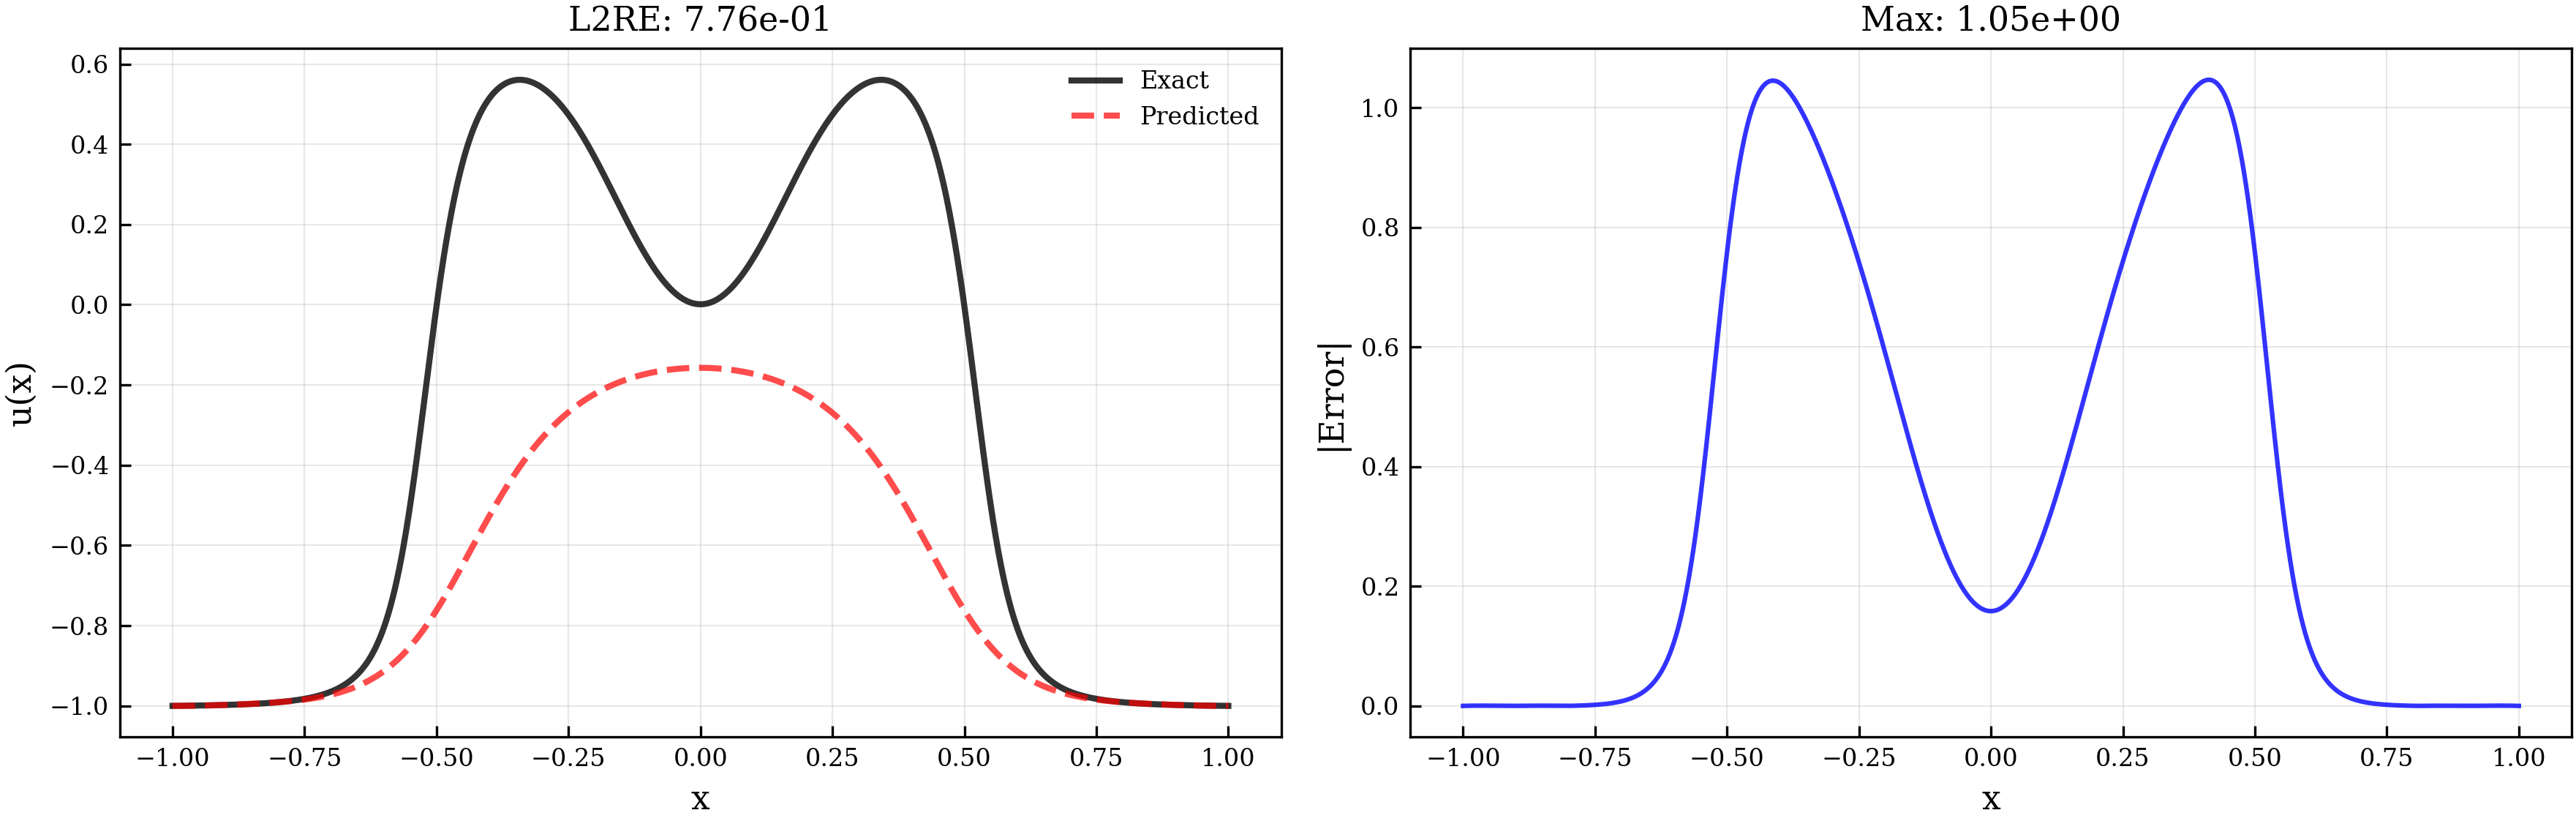

allen-cahn_L2_lambda_0.0001


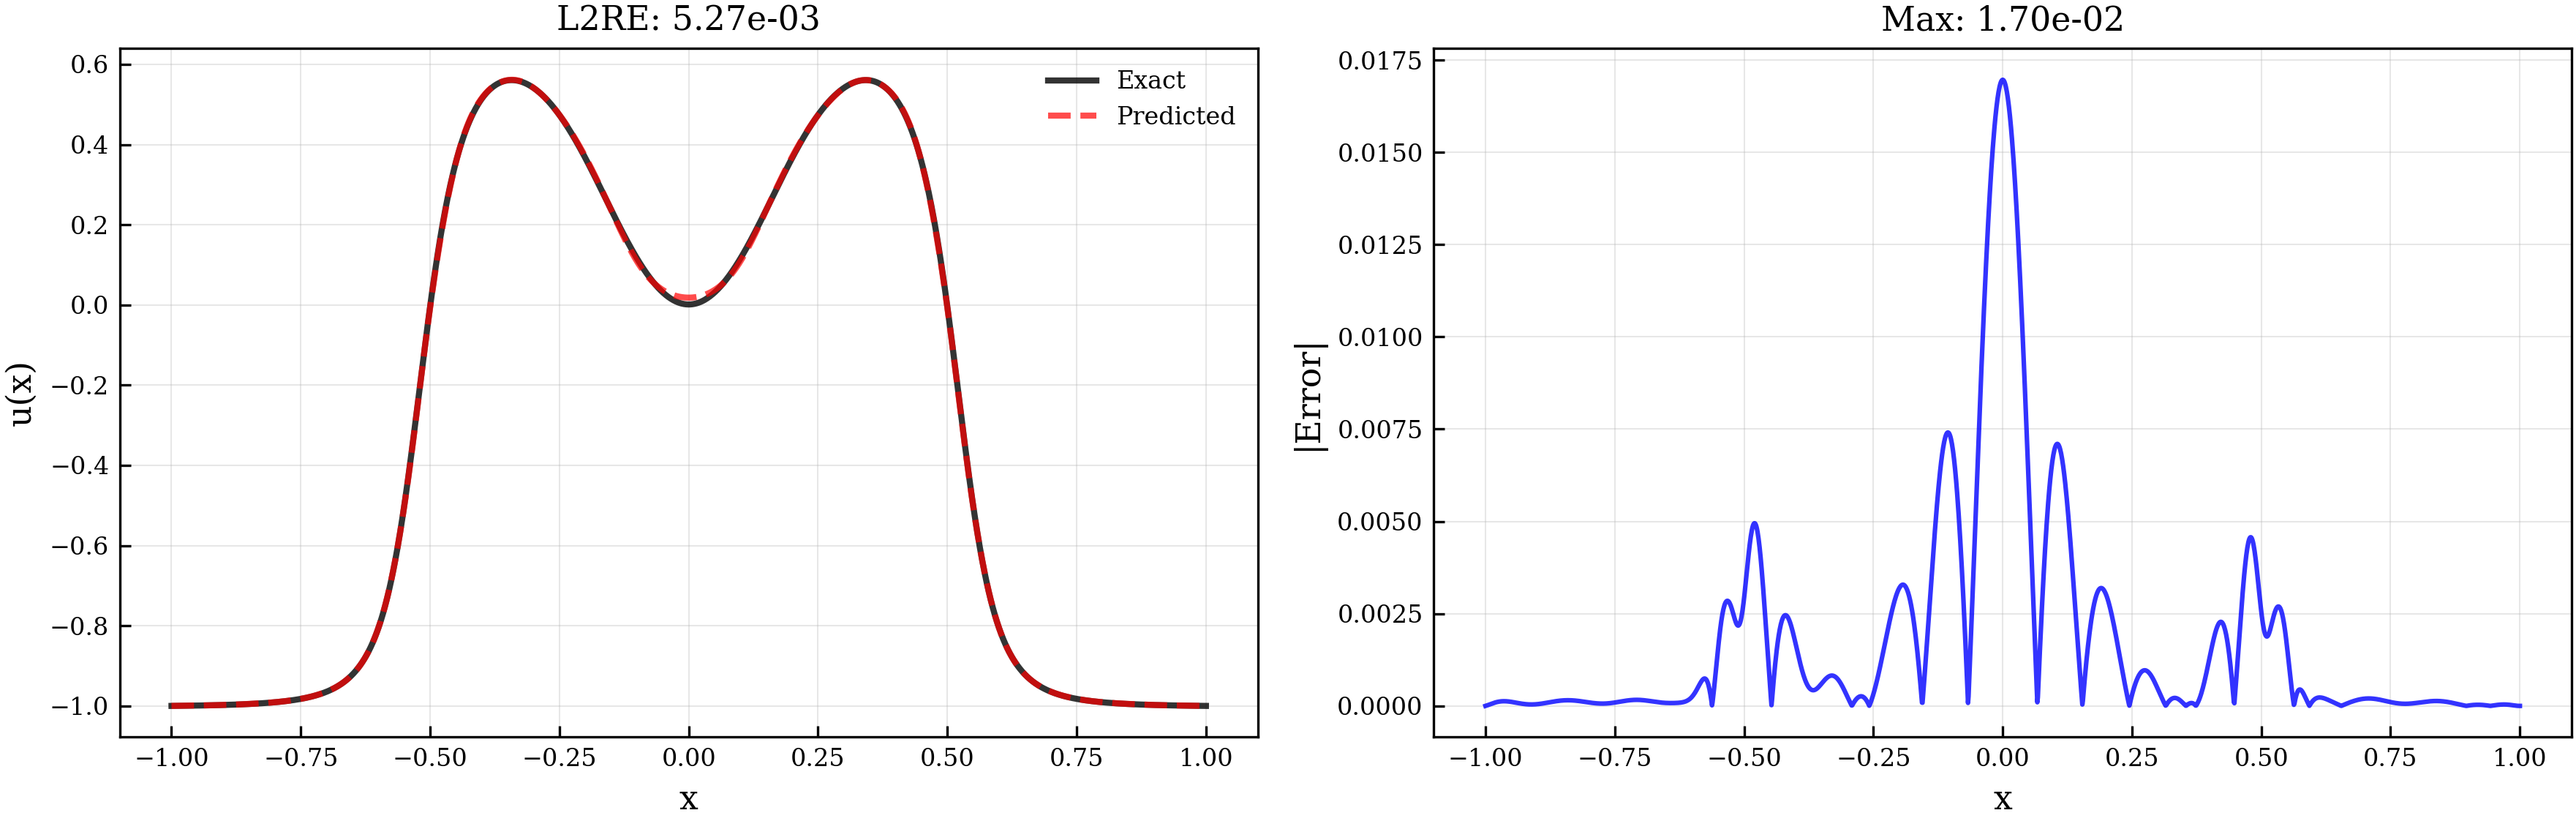

allen-cahn_J_lambda_1e-07


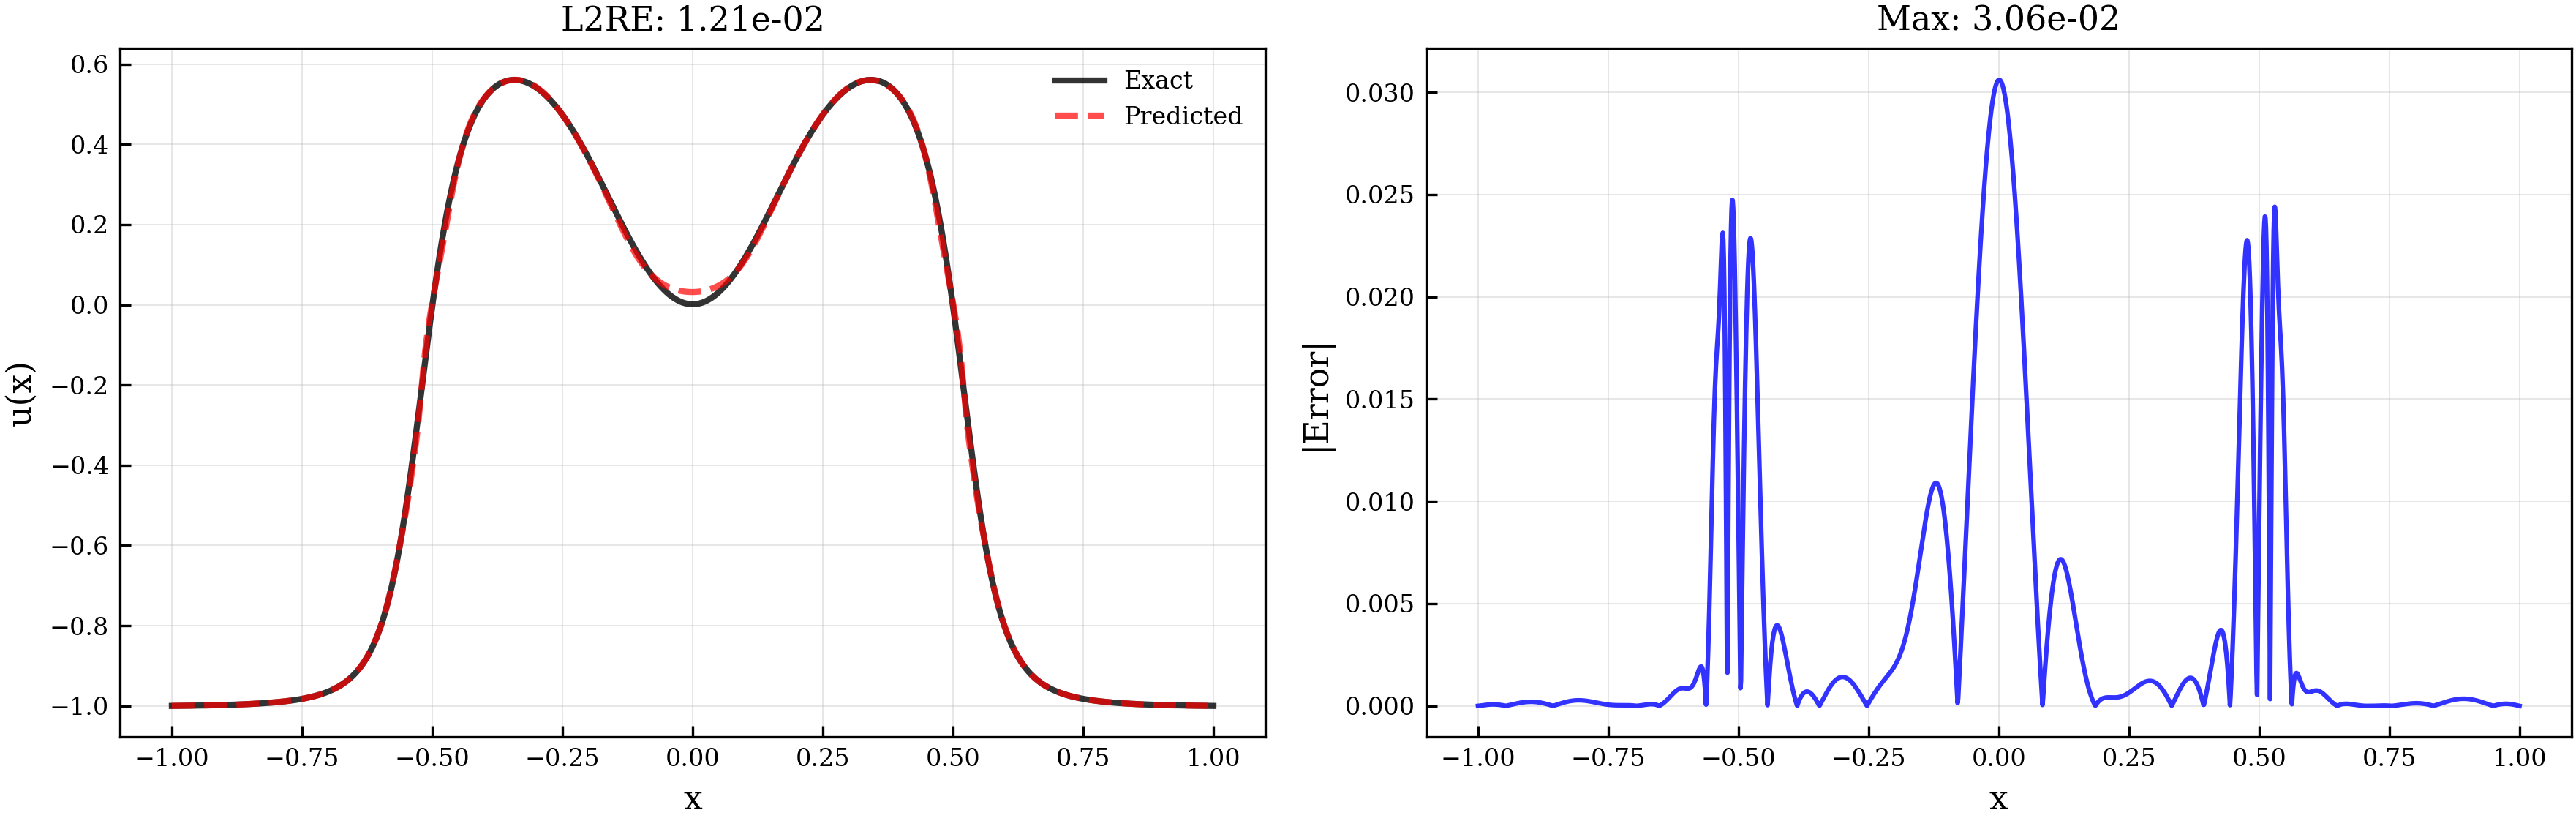

allen-cahn_UR_lambda_1e-07


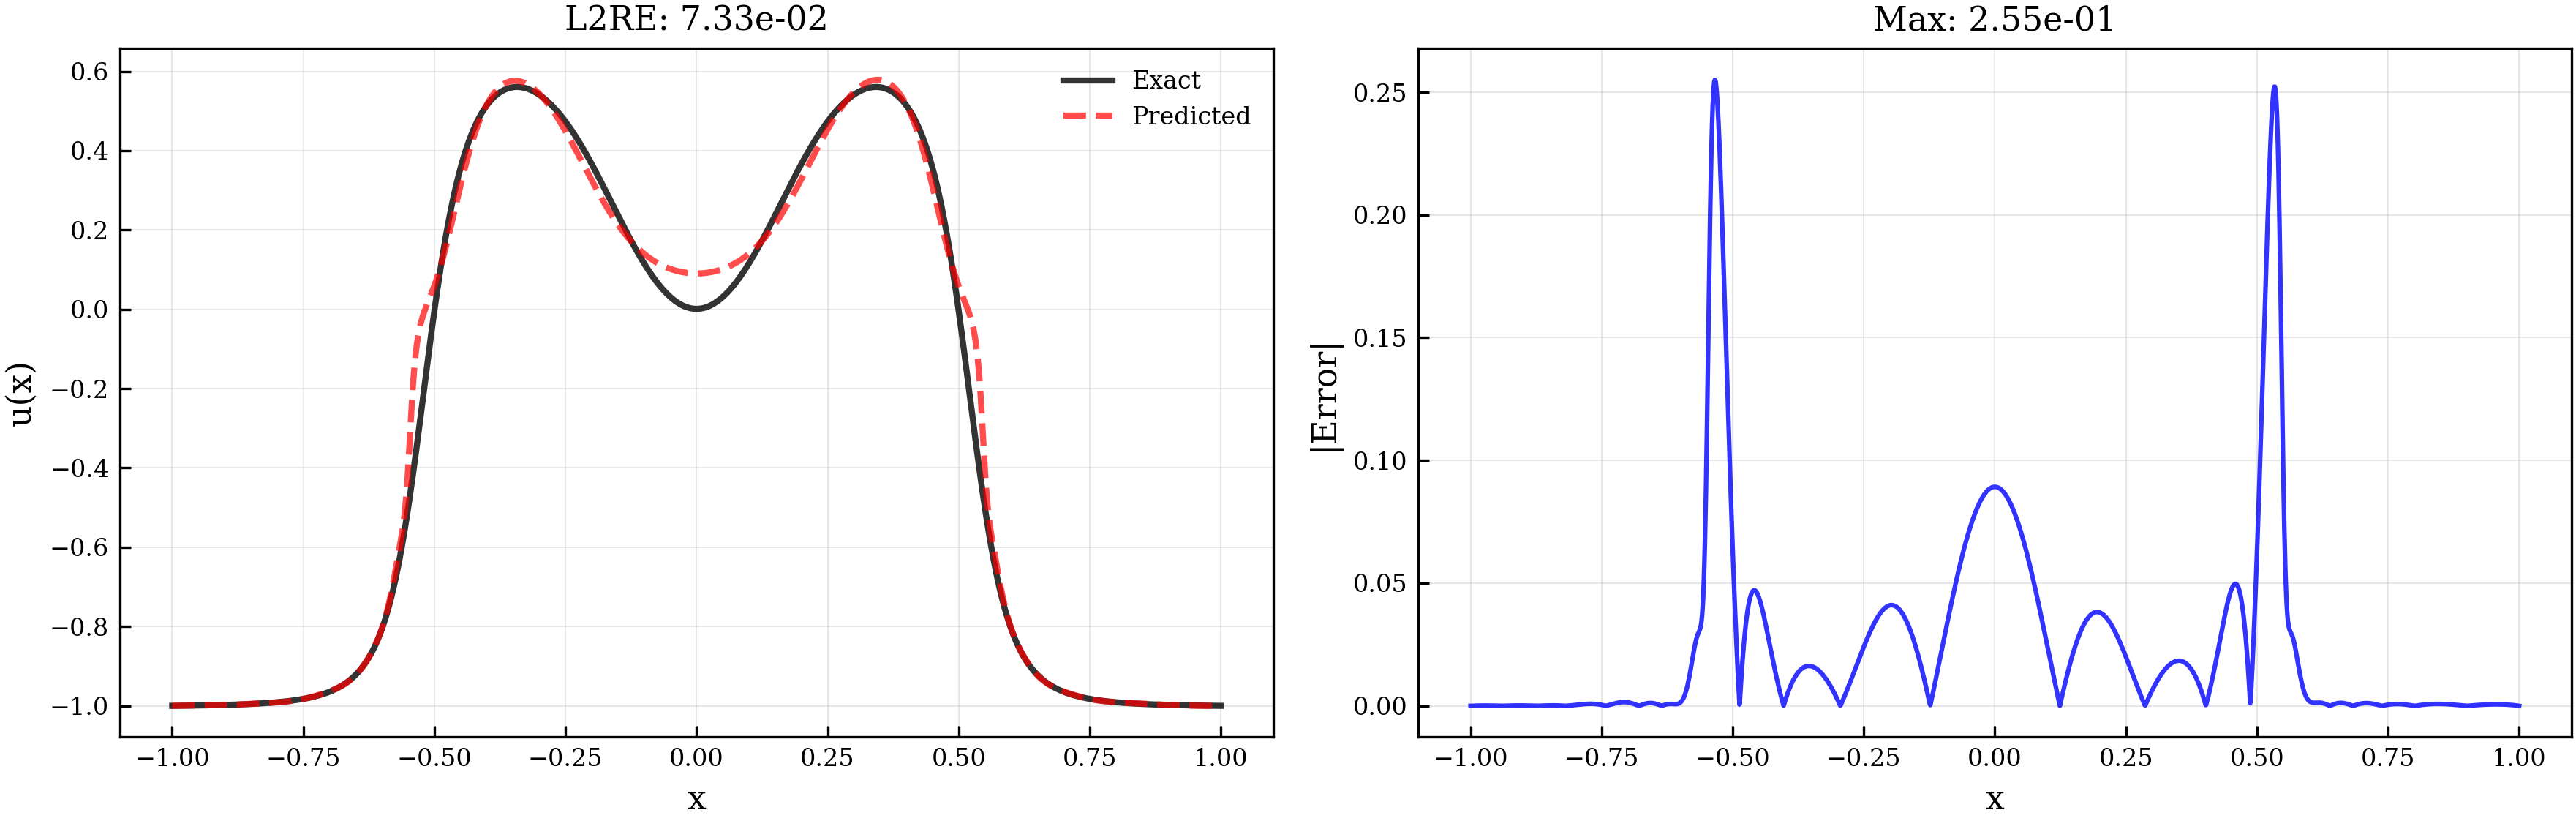

allen-cahn_L1_lambda_1e-05


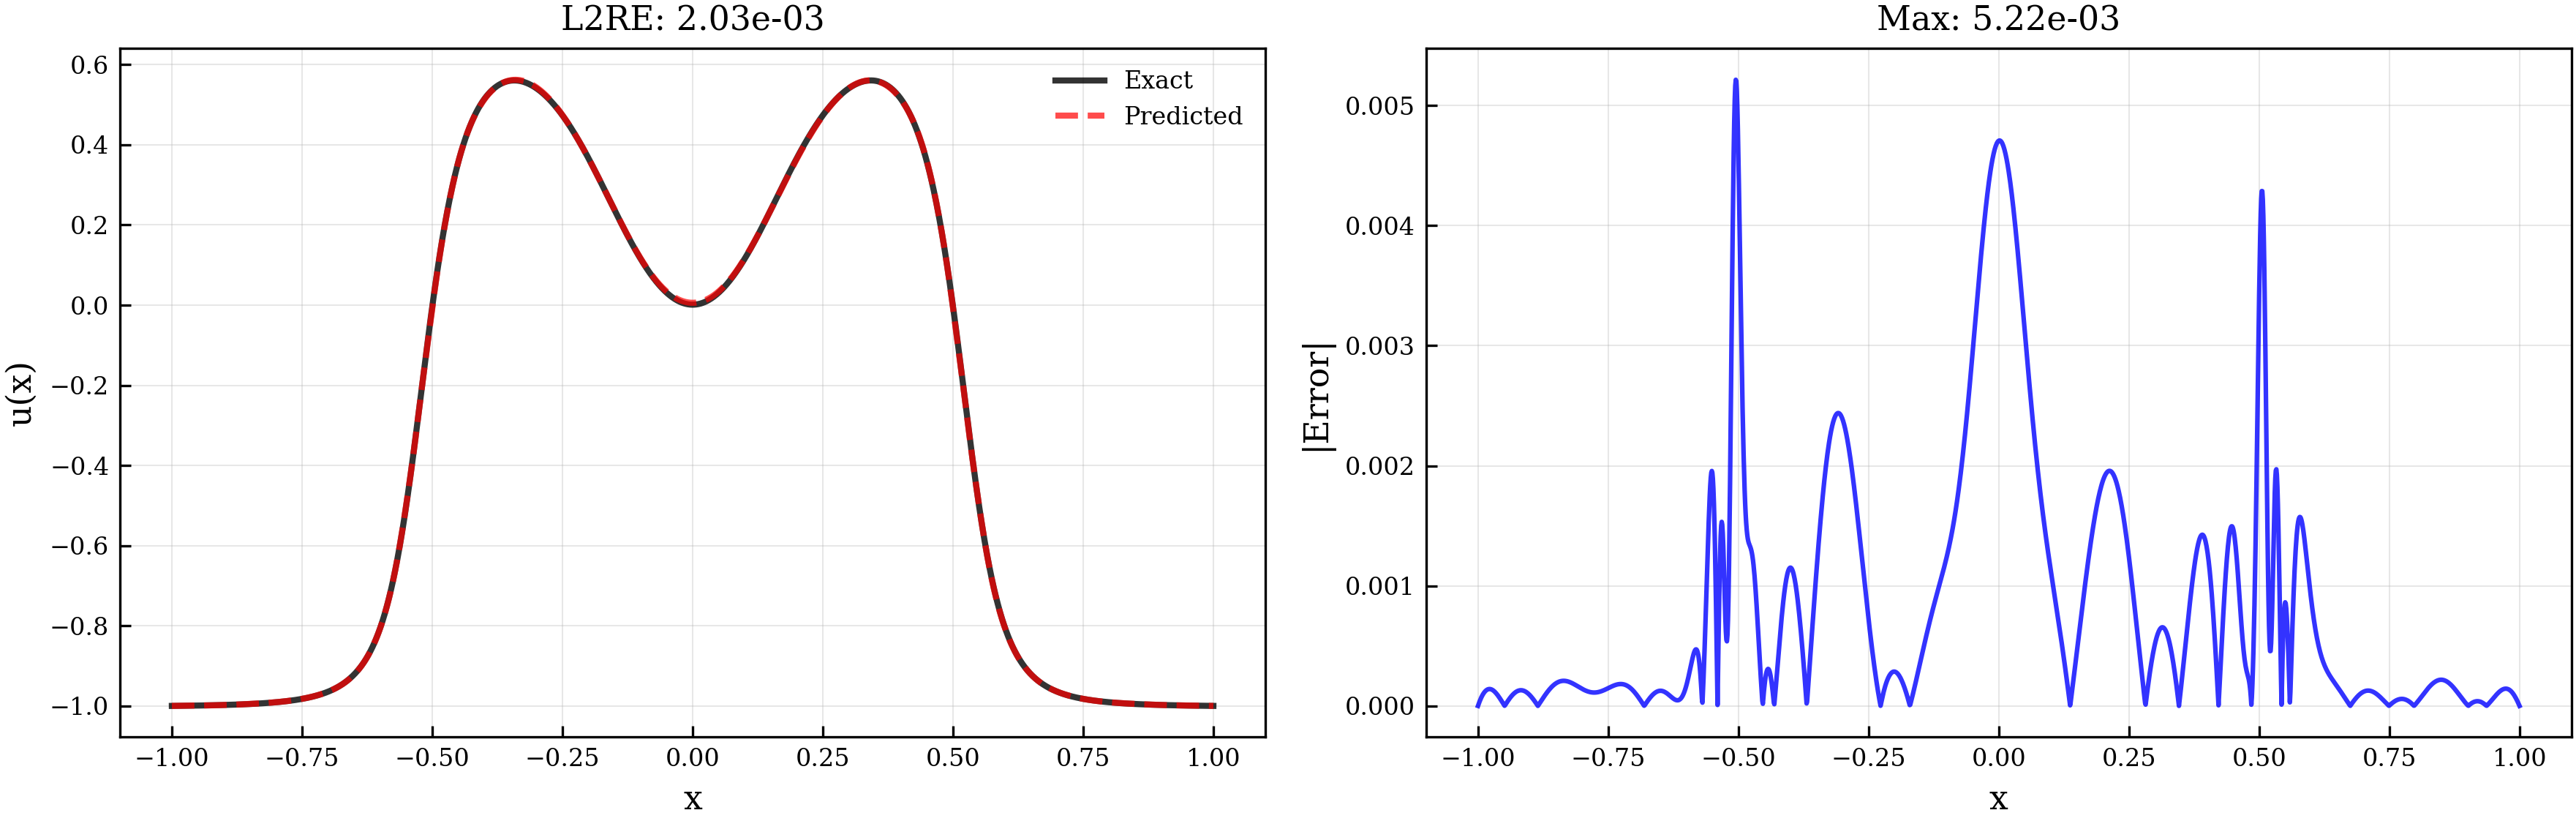

allen-cahn_None_lambda_0.0


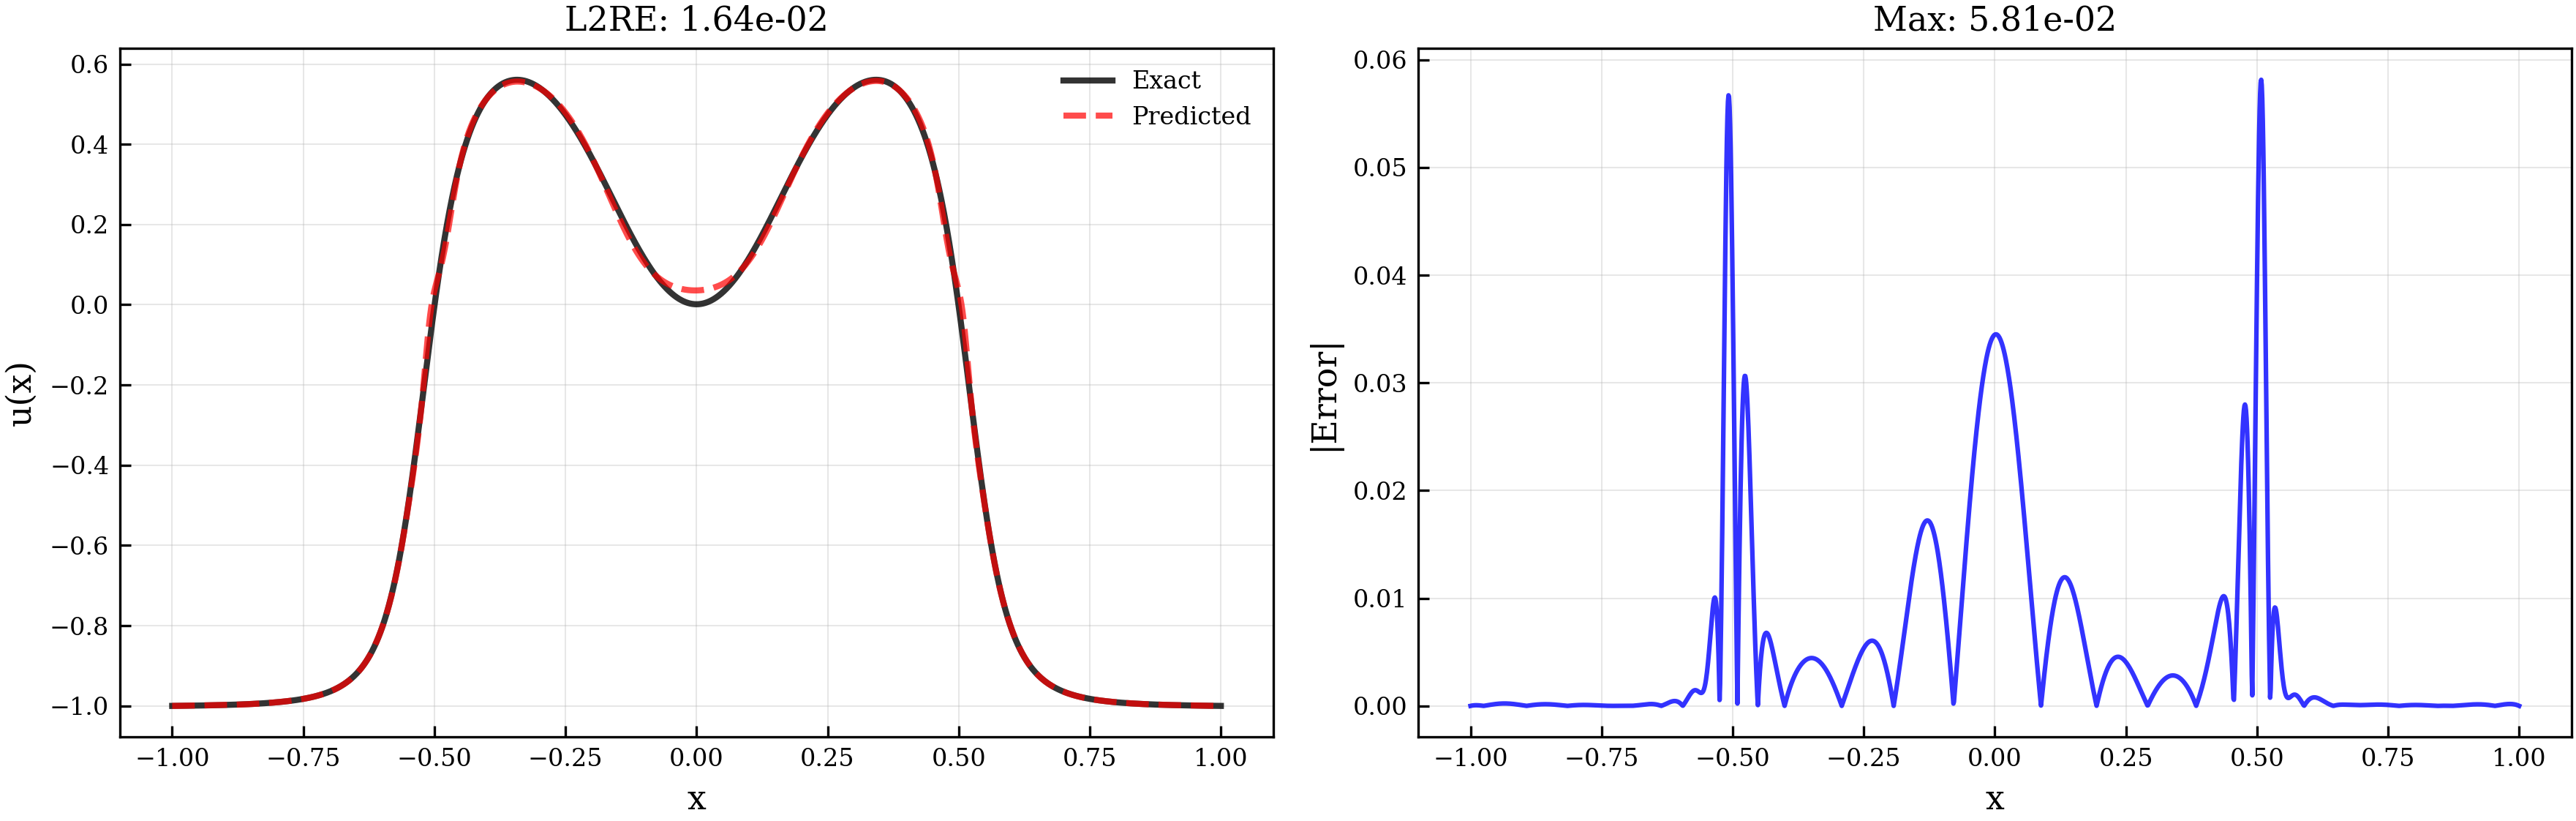

In [ ]:
for dir in allen_cahn_dirs:
  solver = results_allen_cahn[0]["solver"]
  solver = load_nets(f"./final_model_states/david_finall/allen-cahn_52/{dir}/solution_epoch_5300.pt", solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  print(dir)
  plot_1d_solution_comparison(x, u_pred, u_ref_allen_cahn, filename=f"solution_{dir}".replace(".", "_"), save_dir="./final_plots/allen_cahn")

#### Burgers

In [ ]:
burger_spec = EquationSpec(
    name="burgers",
    equation_factory=burgers_equation,
    ic_fn=burgers_ic,
    bc_left_builder=make_burgers_bc_left,
    bc_right_builder=make_burgers_bc_right,
    exact_fns_container=None,
    numerical_solution_func=solve_burgers,
    equations_number=1,
    ib_conditions_size=1,
    seed=52,
)

register_equation(burger_spec)

burgers_run = make_run_config(
    equation_name="burgers",
    models_save_dir=f"./burgers_52",
    domain=DomainConfig(
        t_min=0.0,
        t_max=1.0,
        t_num=64,
        x_min=0.0,
        x_max=1.0,
        x_num=64,
        param_min=0.01/np.pi,
        param_max=0.01/np.pi,
        param_num=1,
    ),
      network=NetworkConfig(
        body_units=(64, 64, 64, 64),
        head_units=(32, 32),
        basis_length=32,
        input_encoding="identity",
        use_bias=True,
        weights_init_method="default",
        small_normal_std=1e-2,
    ),
    optimizer=OptimizerConfig(
        mode="lbfgs",
        lbfgs_epochs=1,
        lbfgs_lr=0.5,
        lbfgs_max_iter=75,
    ),
    train=TrainConfig(
        epochs=0,
        save_period=100,
        regularization_period=1,
    ),
    eval_cfg=EvalConfig(
        dx=0.1,
        t_i=0.5,
        param_i=0.0001,
        convergence_value=1e-3,
        period=1,
    ),
    regularizations={None: [0.0]},
    )


results_burgers = run_experiment(burgers_run)

Training Progress:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
local_head = 0
dt = 0.001
r_i = 0.01/np.pi
t_i = 0.5

x = torch.arange(
    0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_burgers = solve_burgers(r_i, 1e-4, t_i, 0, 0, 1.0, dt)

In [ ]:
base = "./final_model_states/david_finall/burgers_52"
burgers_dirs = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]

burgers_gPINN_lambda_1e-07


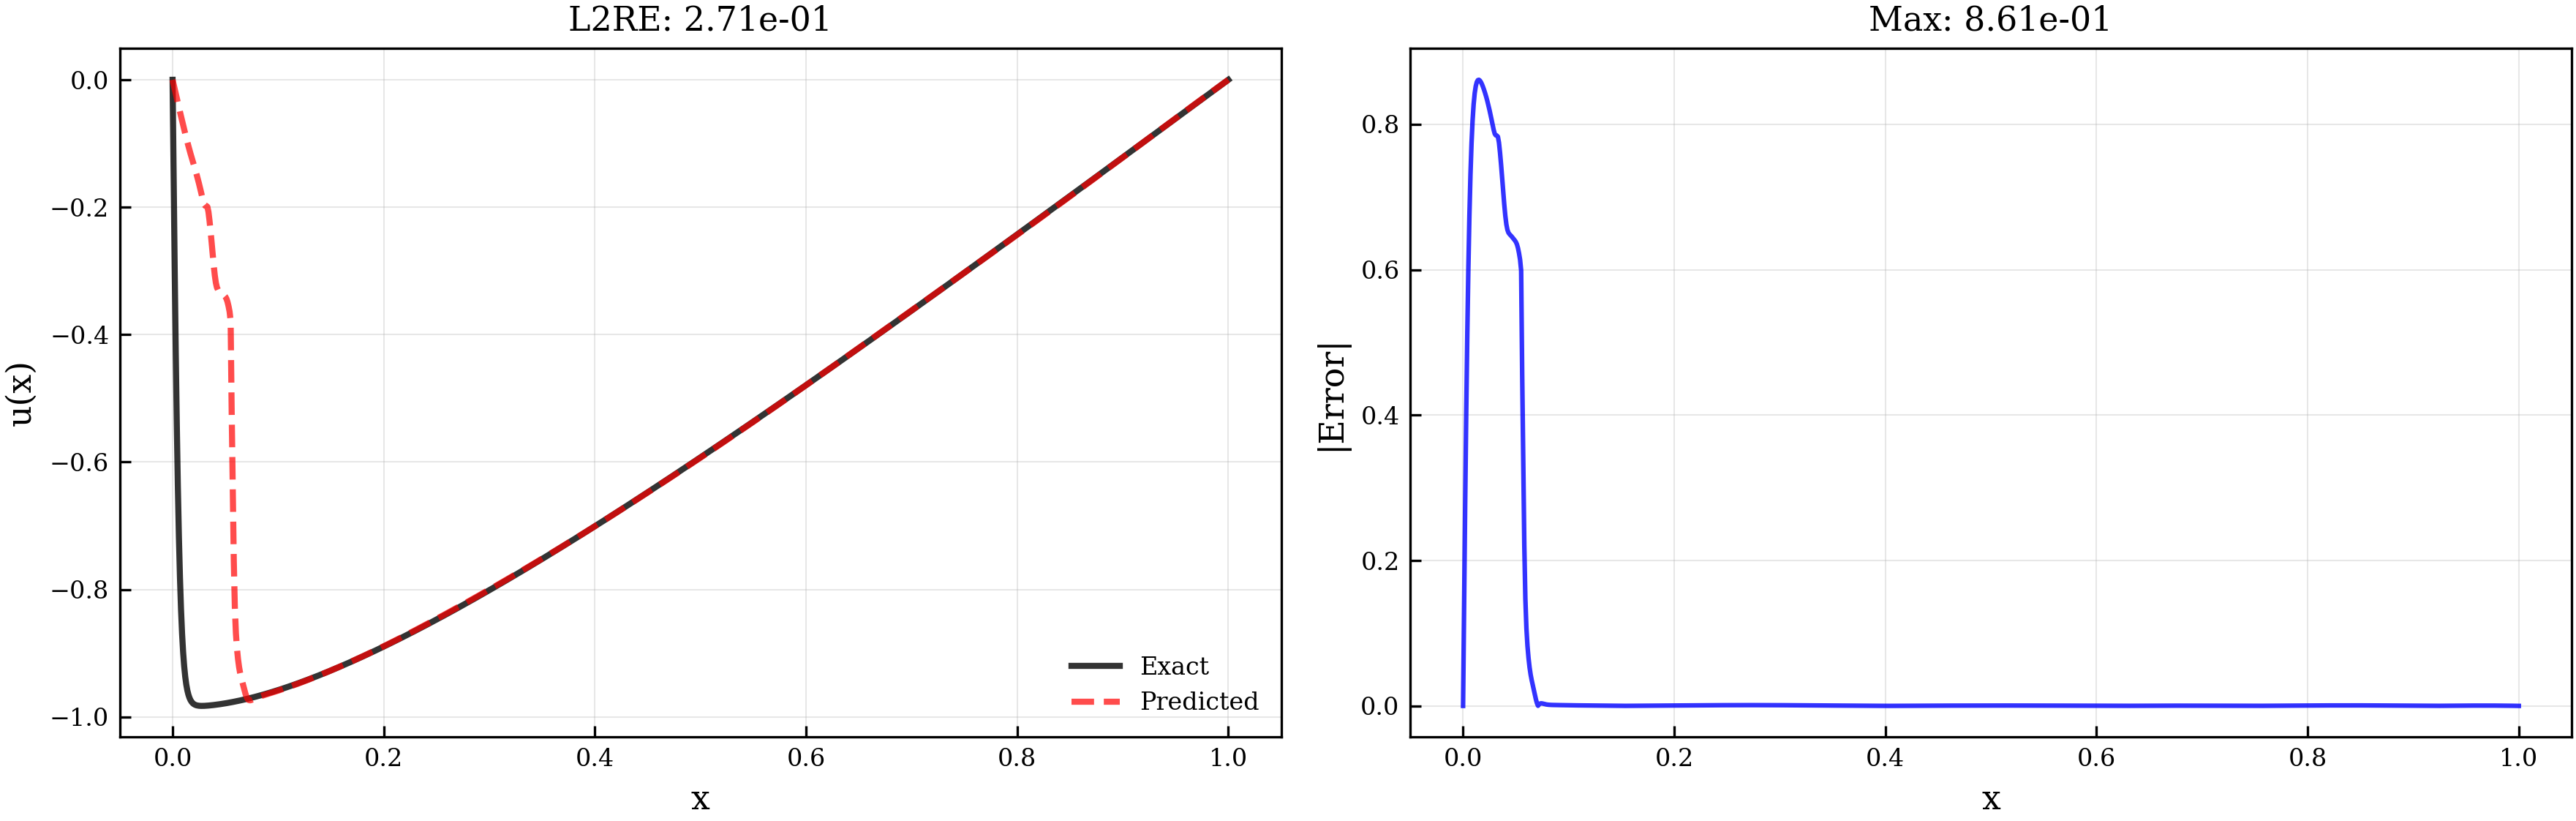

burgers_L1_lambda_0.0001


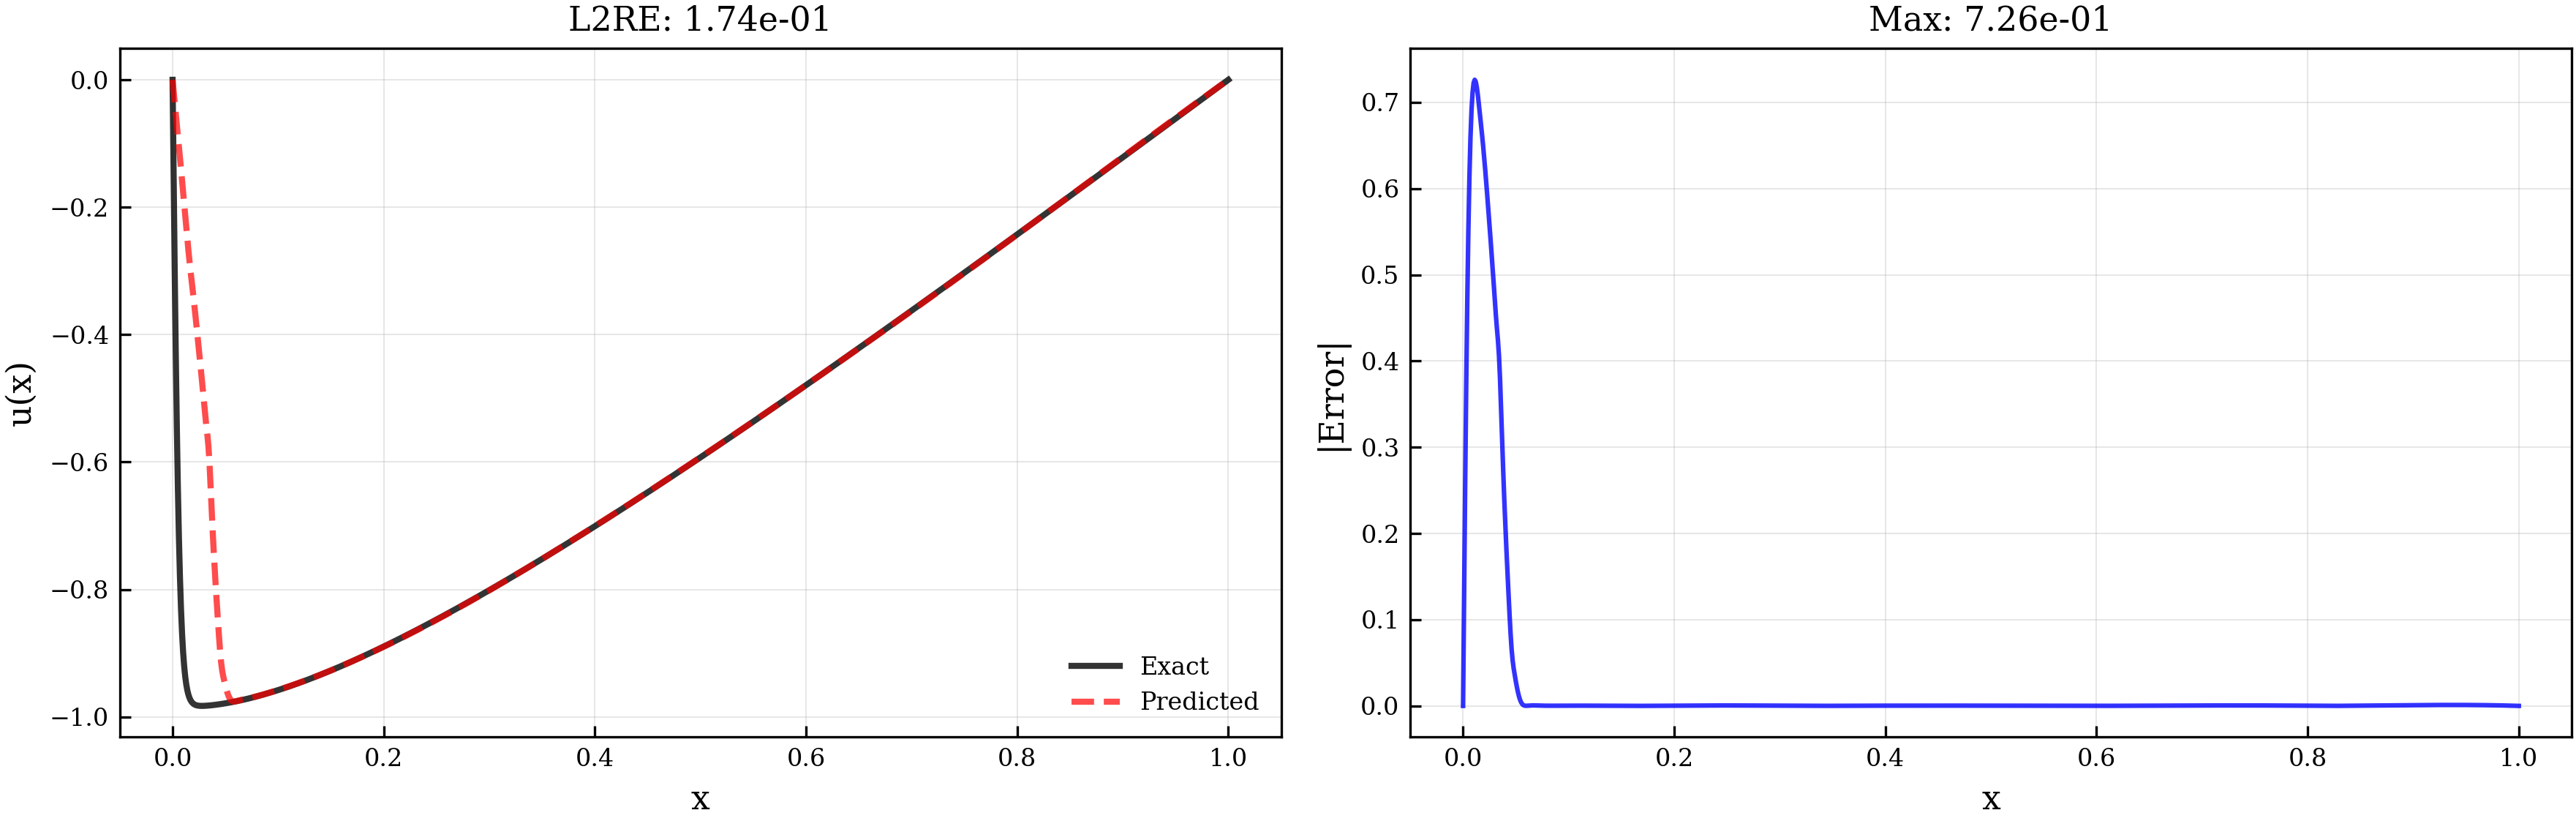

burgers_None_lambda_0.0


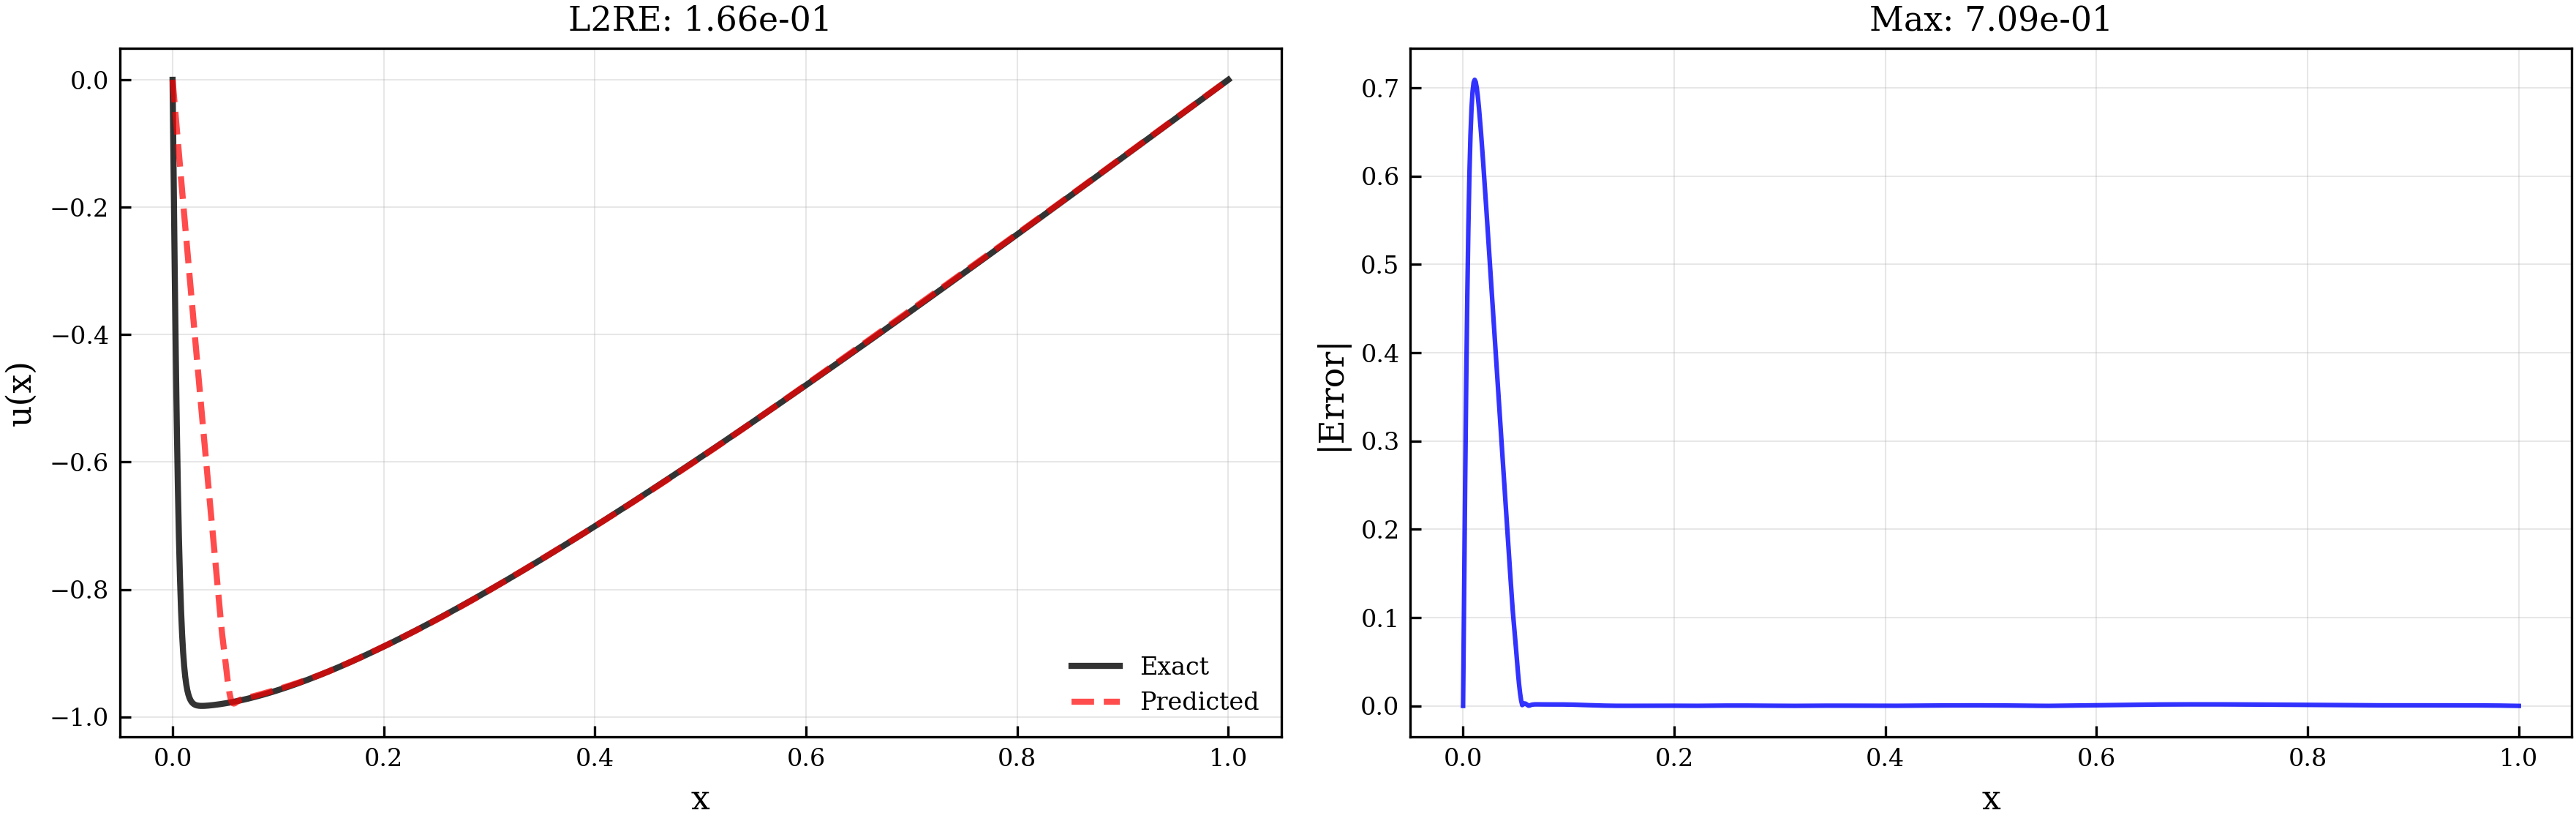

burgers_J_lambda_0.1


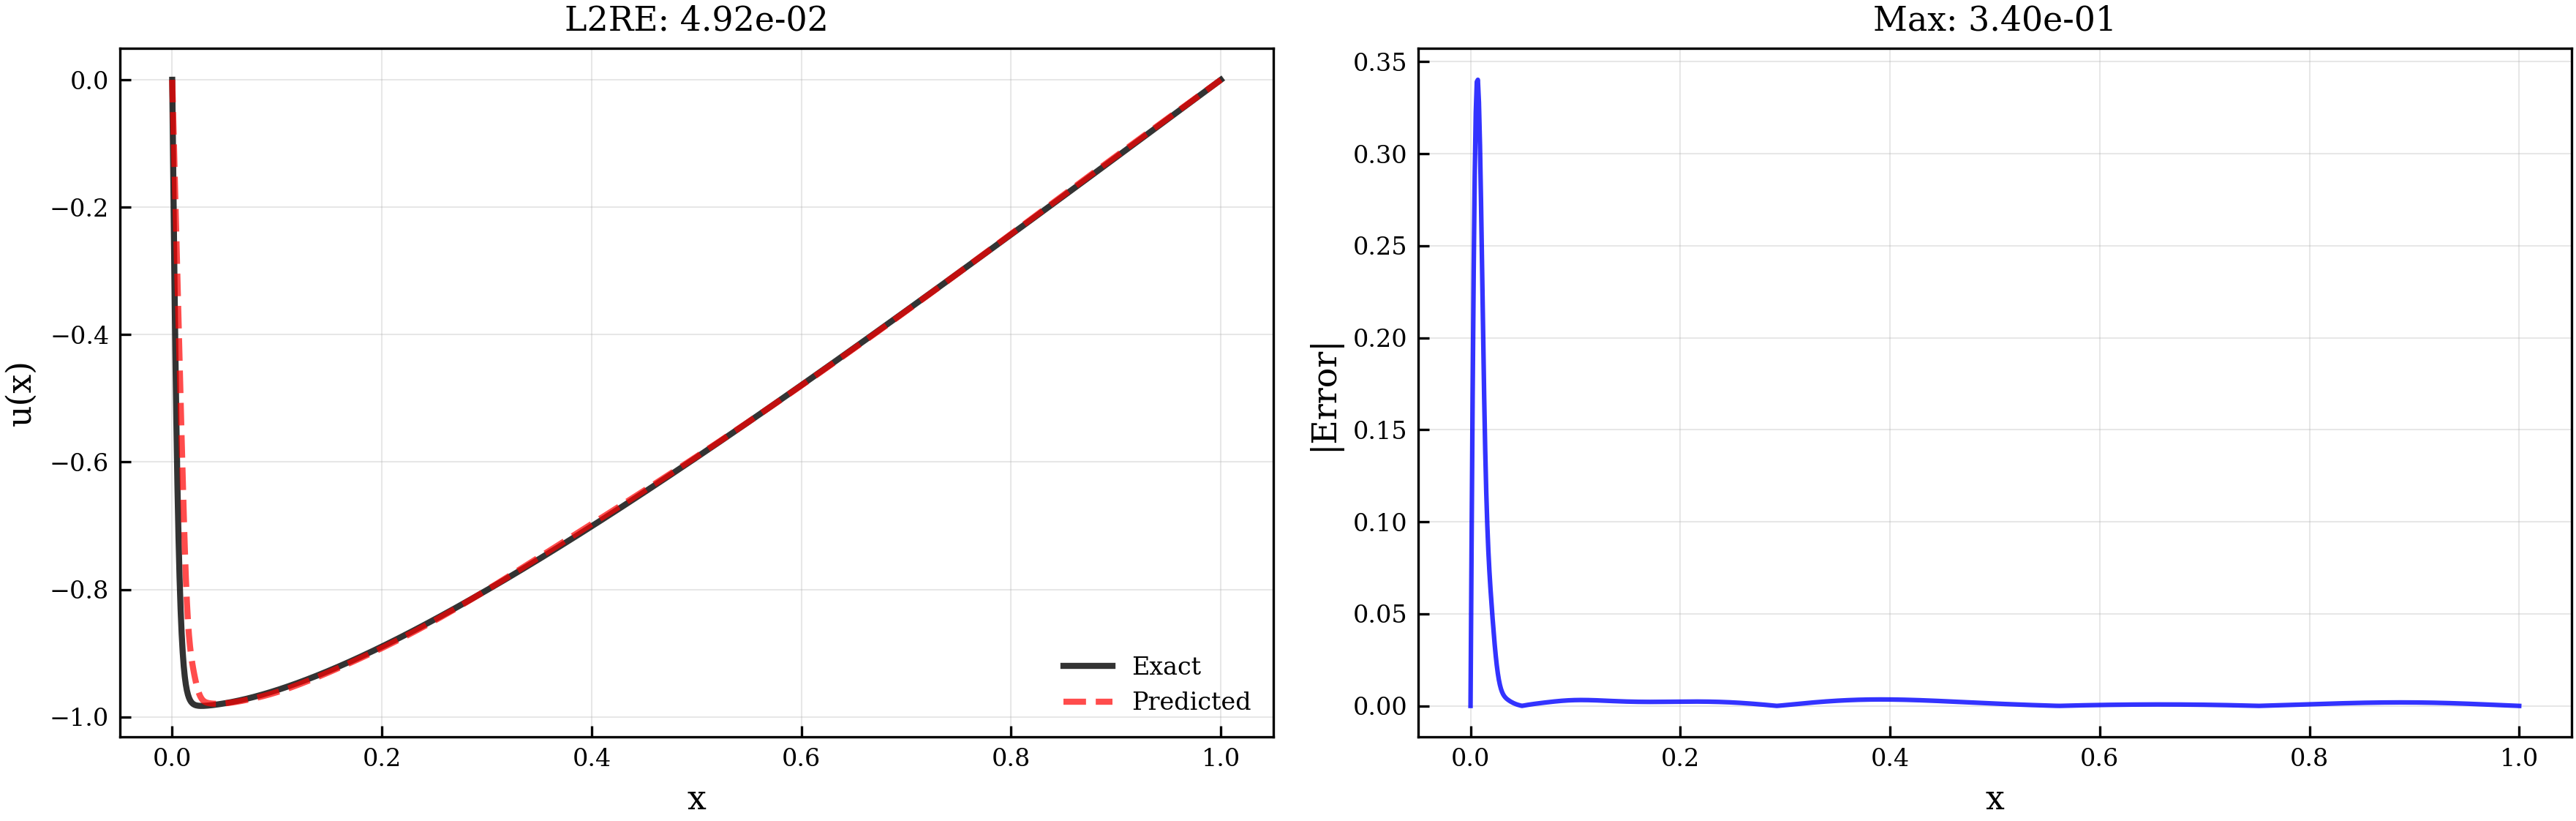

burgers_UR_lambda_1e-06


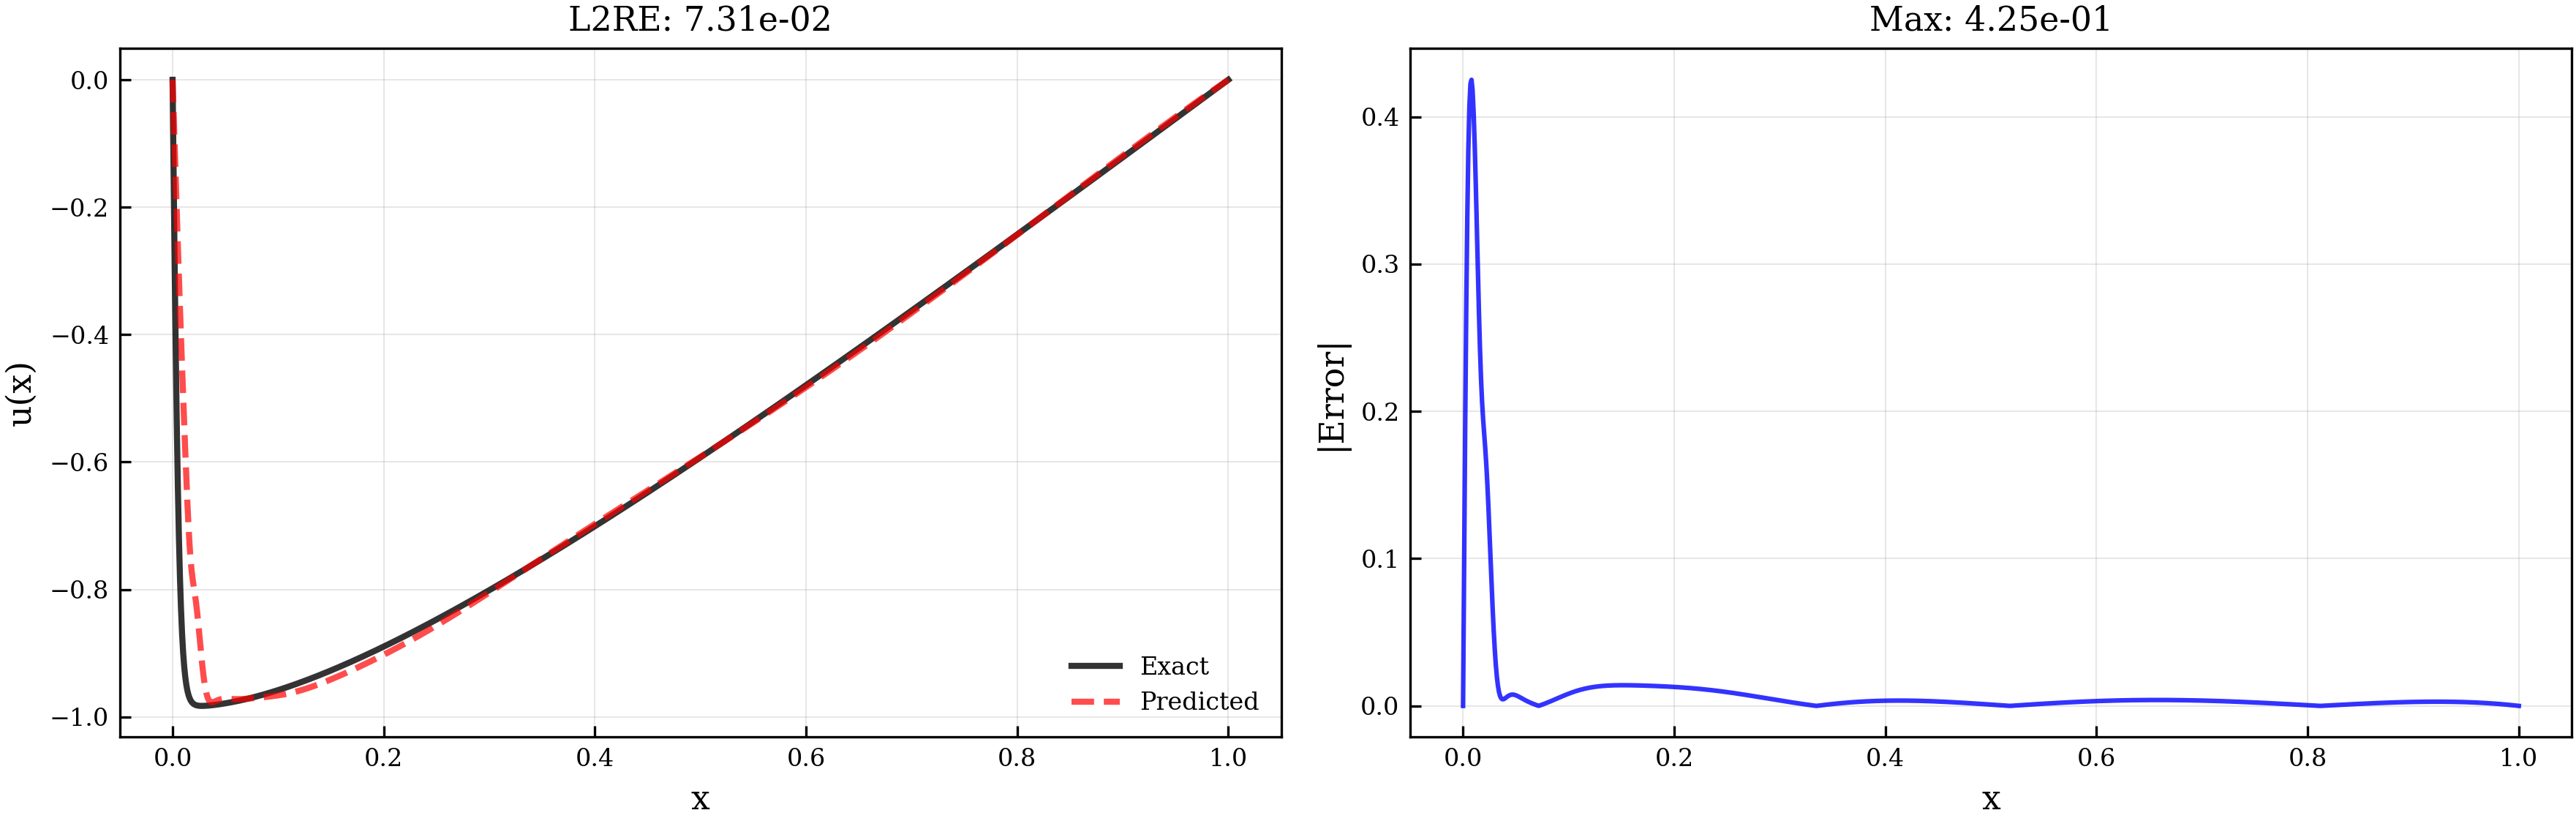

burgers_L2_lambda_100.0


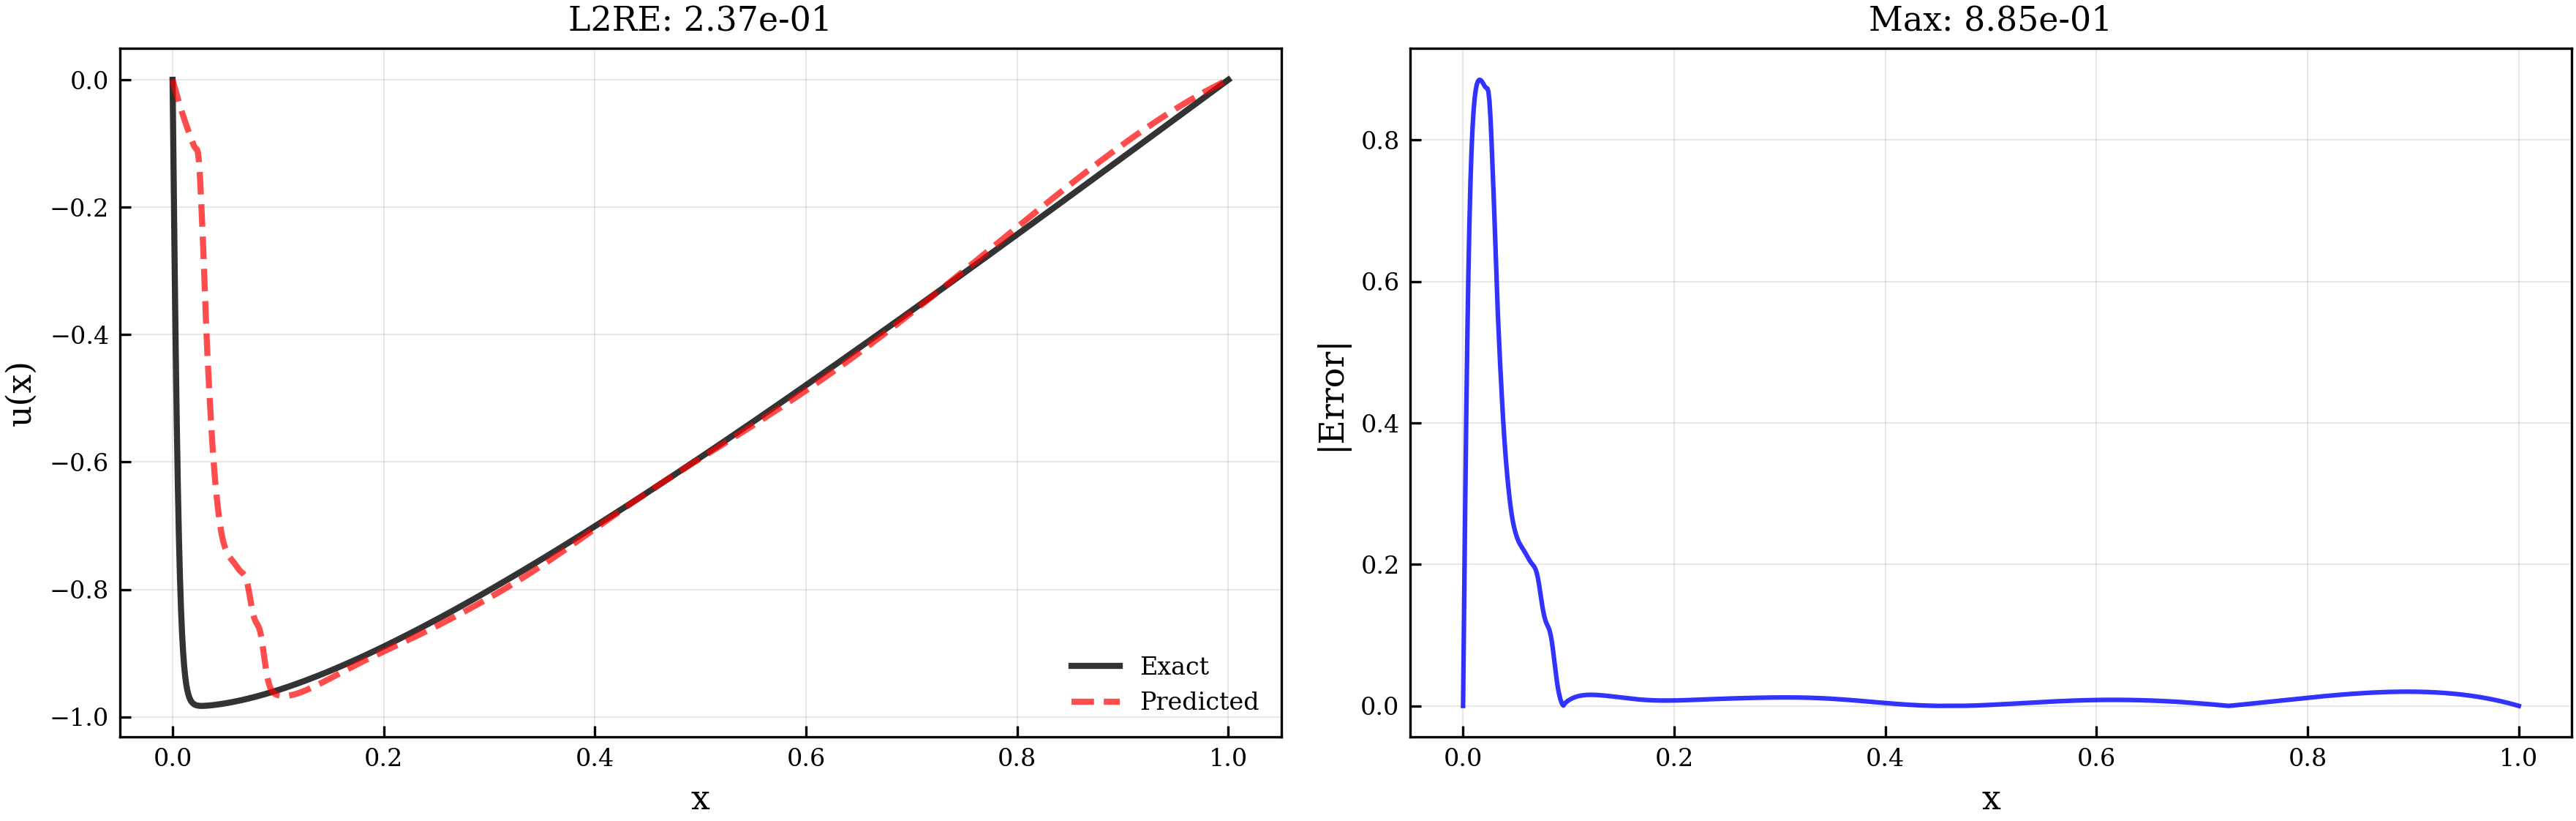

In [ ]:
for dir in burgers_dirs:
  solver = results_burgers[0]["solver"]
  load_path = f"./final_model_states/david_finall/burgers_52/{dir}/solution_epoch_5300.pt"
  solver = load_nets(load_path, solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  print(dir)
  plot_1d_solution_comparison(x, u_pred, u_ref_burgers, filename=f"solution_{dir}".replace(".", "_"), save_dir="./final_plots/burgers")

#### Fisher

In [ ]:
fisher_spec = EquationSpec(
    name="fisher",
    equation_factory=fisher_kpp_equation,
    ic_fn=fisher_ic,
    bc_left_builder=make_fisher_bc_left,
    bc_right_builder=make_fisher_bc_right,
    numerical_solution_func=solve_fisher_kpp,
    equations_number=1,
    ib_conditions_size=1,
    seed=52,
)

register_equation(fisher_spec)
fisher_run = make_run_config(
    equation_name="fisher",
    models_save_dir=f"./fisher_{52}",
    domain=DomainConfig(
        t_min=0.0,
        t_max=1.0,
        t_num=64,
        x_min=0.0,
        x_max=1.0,
        x_num=64,
        param_min=0.01,
        param_max=0.01,
        param_num=1,
    ),
    network=NetworkConfig(
        body_units=(20, 20, 20, 20),
        head_units=(16, 16),
        basis_length=8,
        use_bias=False,
        small_normal_std=1e-2,
    ),
    optimizer=OptimizerConfig(
        mode="lbfgs",
        lbfgs_epochs=1,
        lbfgs_lr=0.5,
        lbfgs_max_iter=75,
    ),
    train=TrainConfig(
        epochs=0,
        save_period=100,
        regularization_period=1,
    ),
    eval_cfg=EvalConfig(
        dx=0.1,
        t_i=0.5,
        param_i=0.0001,
        convergence_value=1e-3,
        period=1,
    ),
    regularizations={None: [0.0]},)

results_fisher = run_experiment(fisher_run)

Training Progress:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
local_head = 0
dt = 0.001
r_i = 0.1
t_i = 0.5

x = torch.arange(
    0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_fisher = solve_fisher_kpp(r_i, 1e-4, t_i, 0, 0, 1.0, dt)

In [ ]:
base = "./final_model_states/david_finall/fisher_52"
fisher_dirs = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))]

fisher_UR_lambda_1e-06


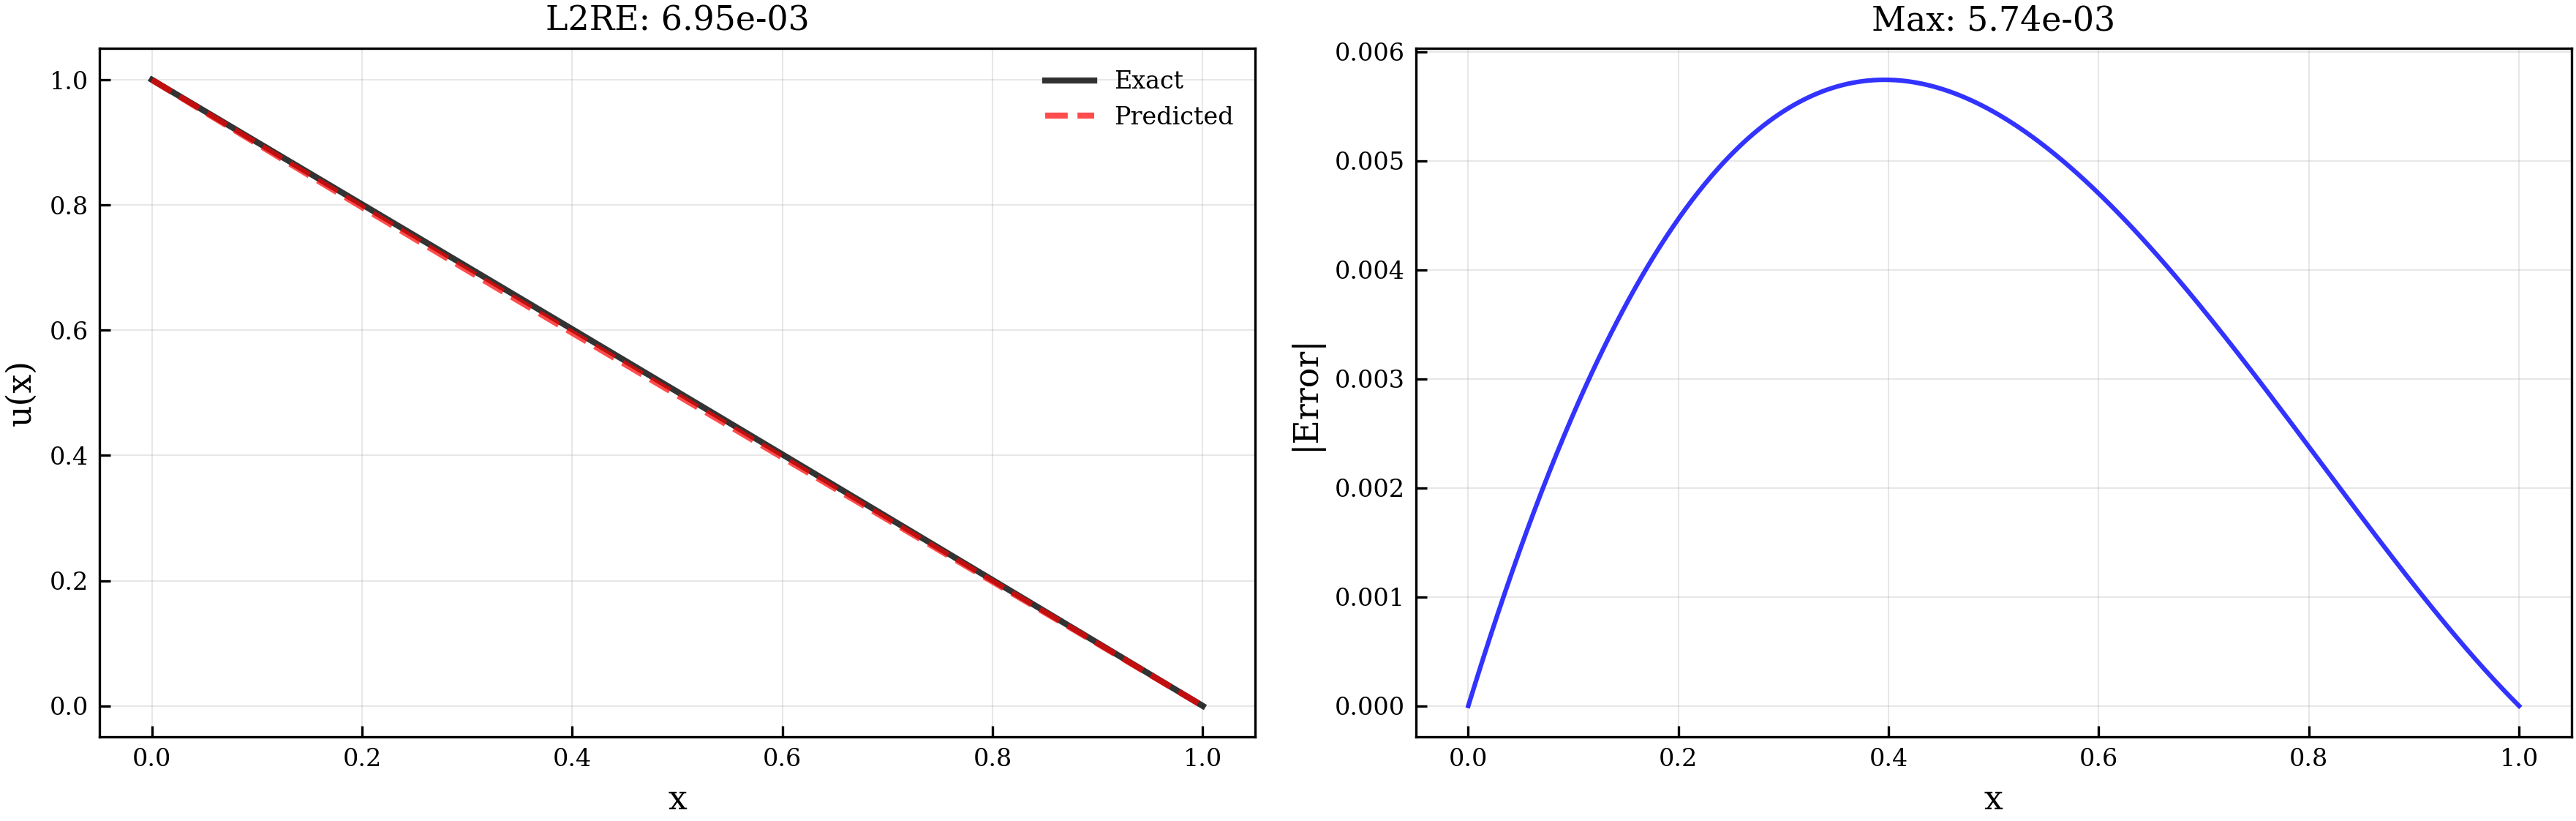

fisher_None_lambda_0.0


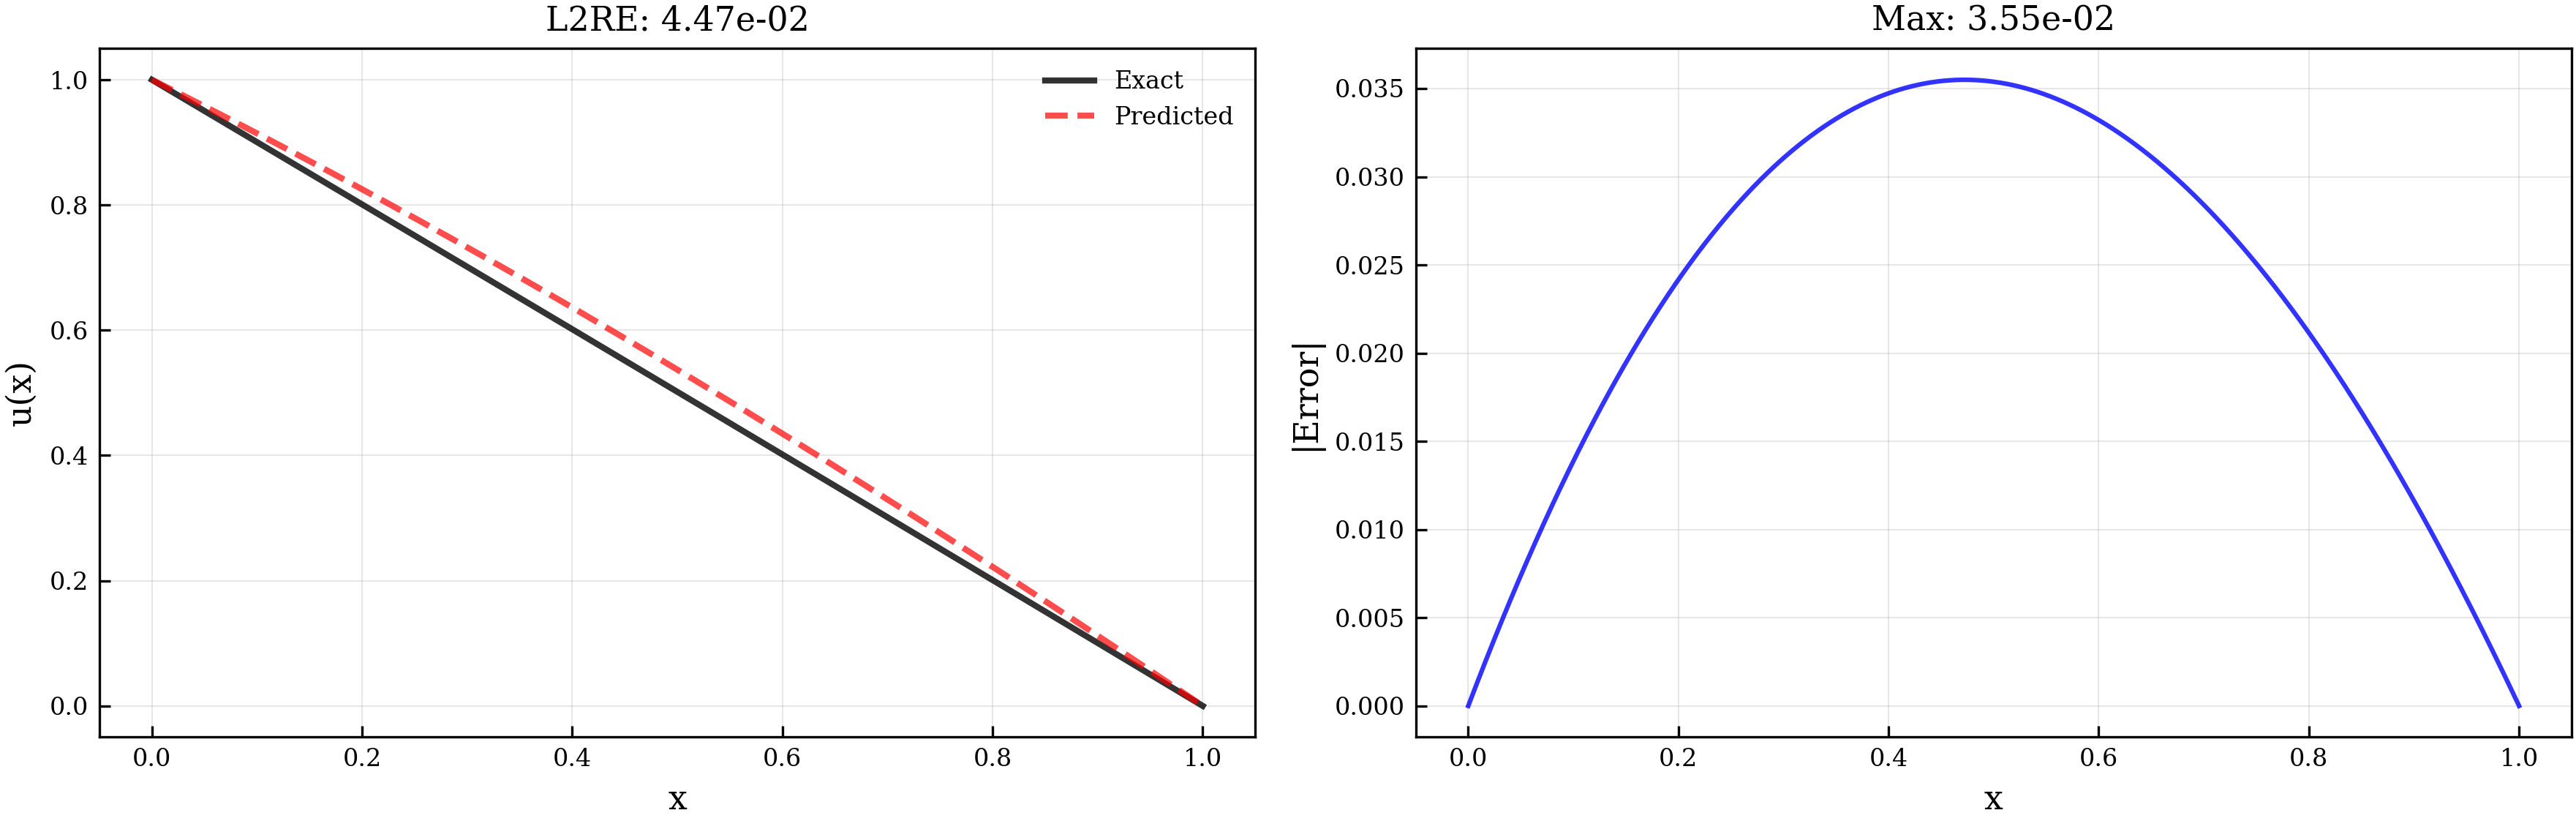

fisher_J_lambda_0.0001


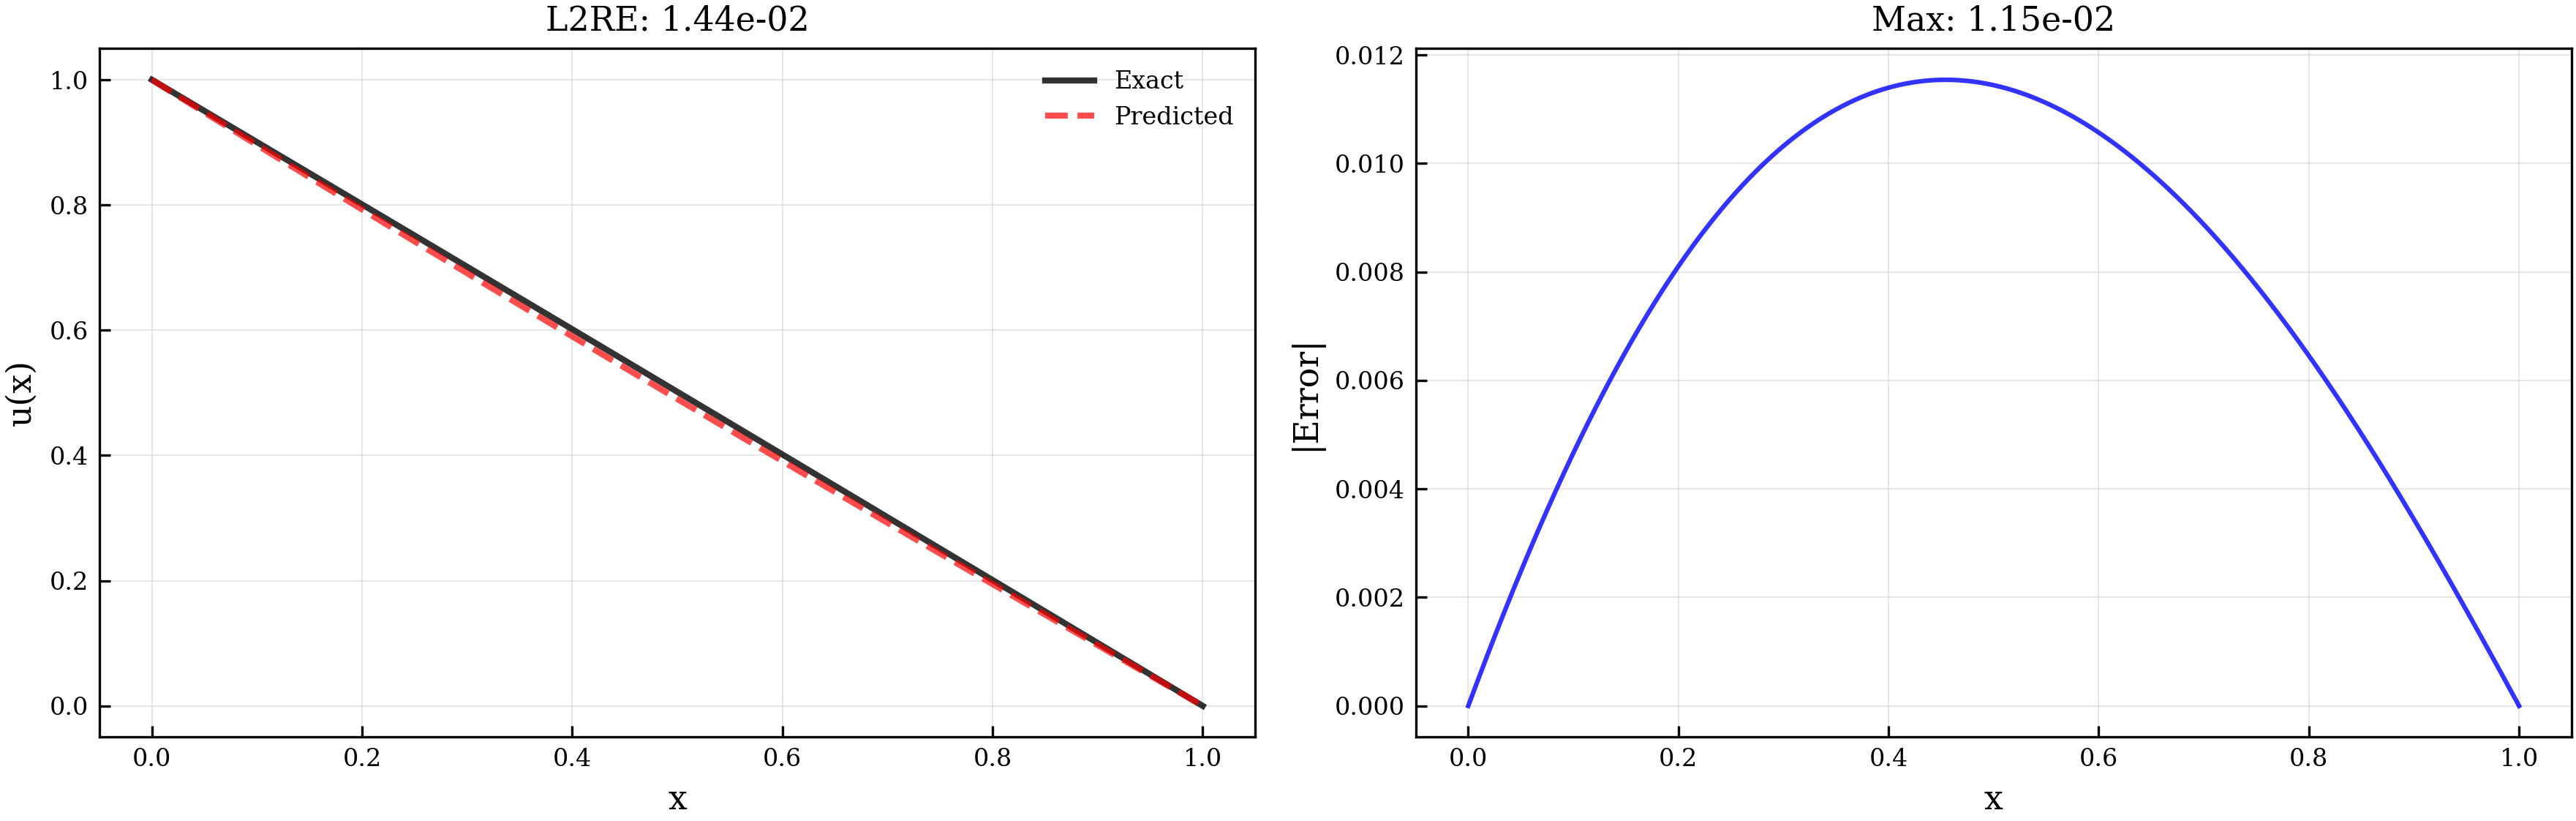

fisher_gPINN_lambda_1e-07


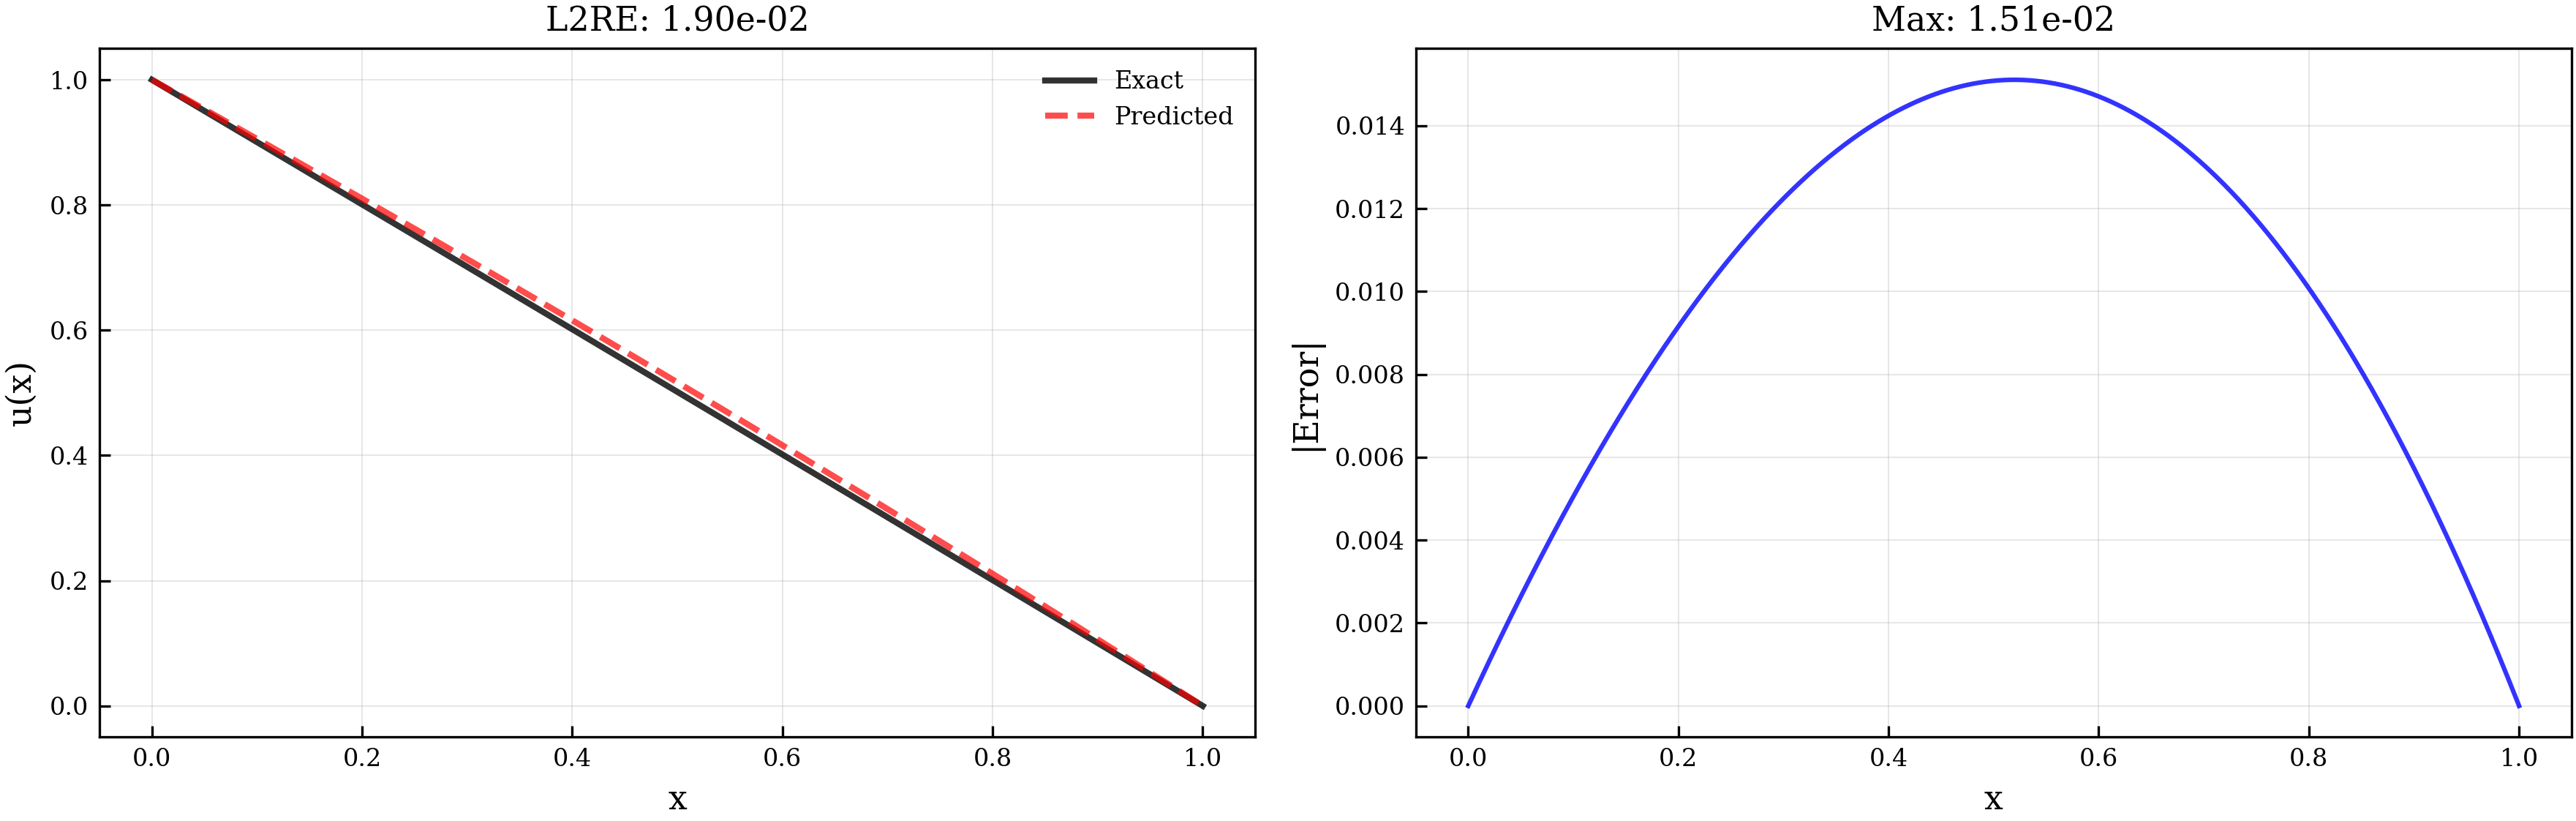

fisher_L2_lambda_1e-06


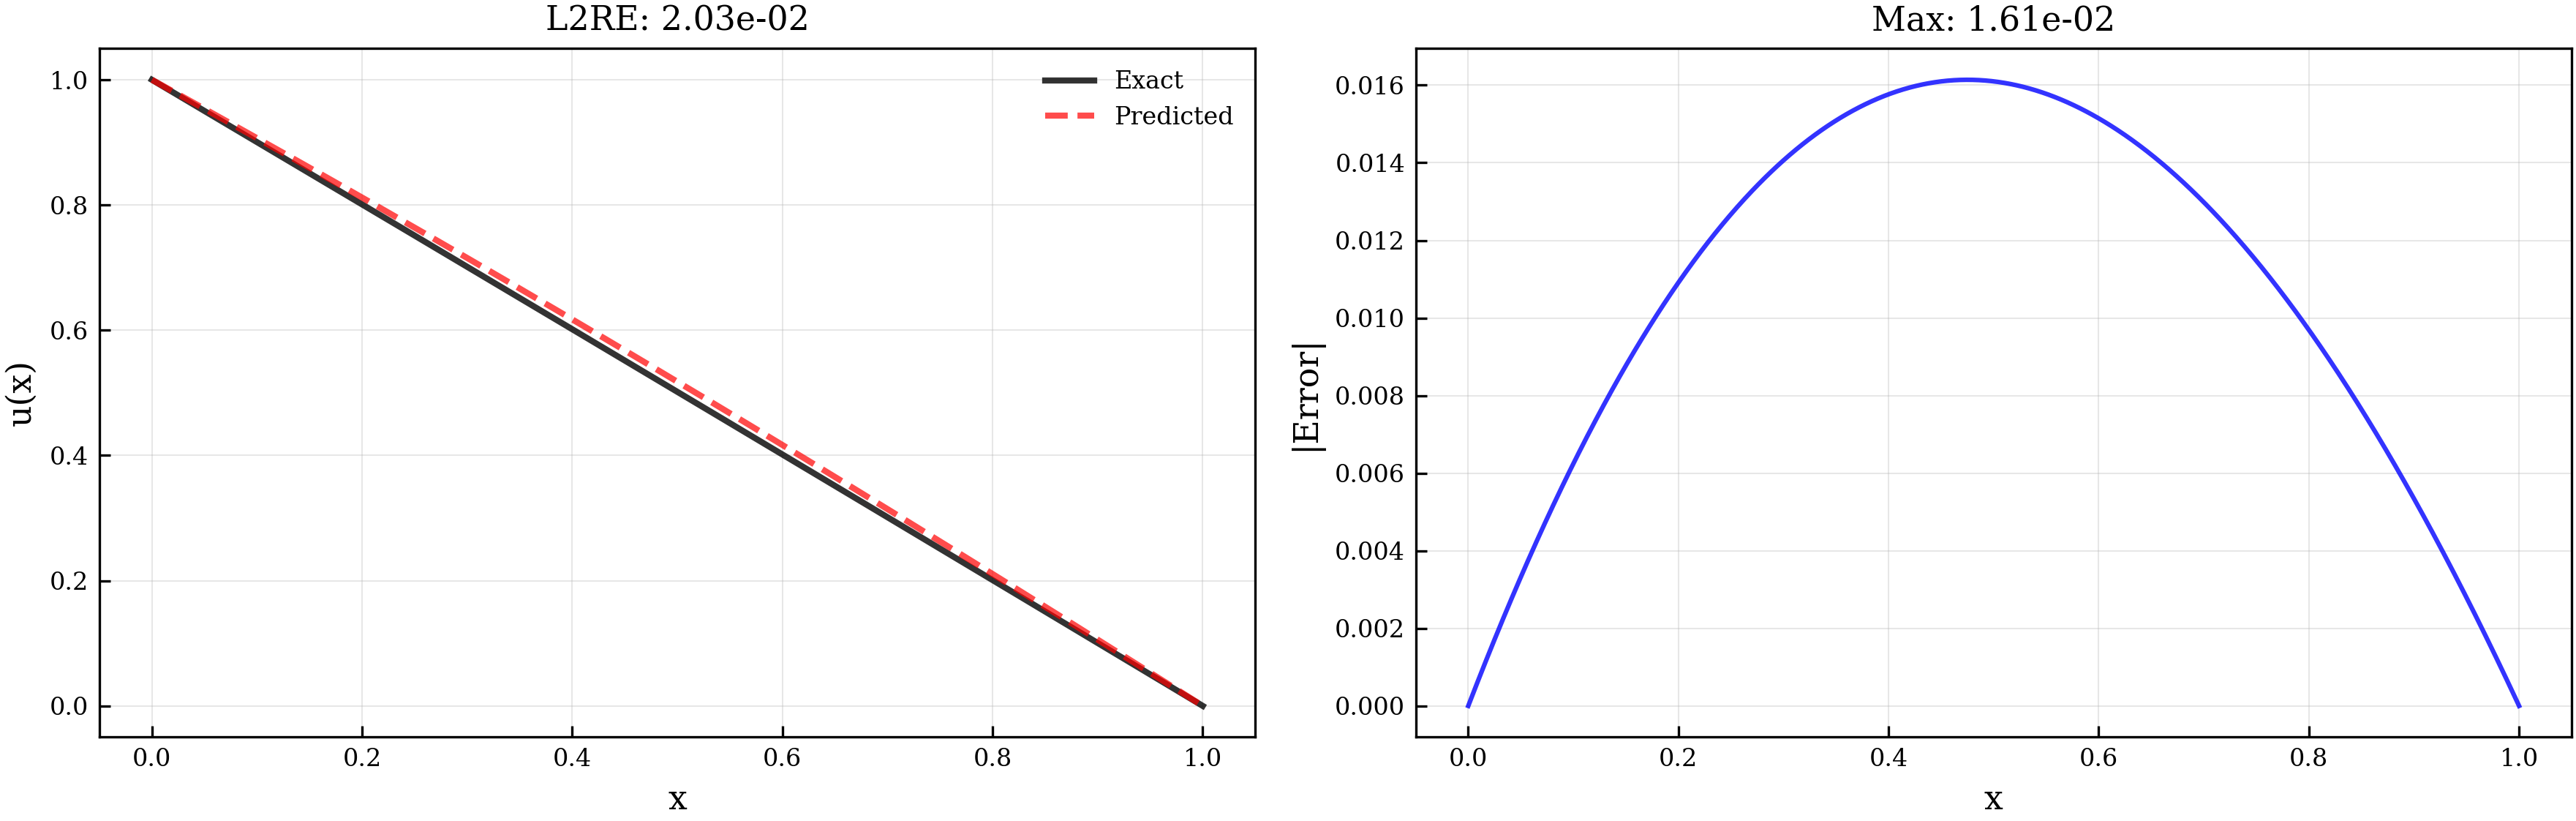

fisher_L1_lambda_1e-06


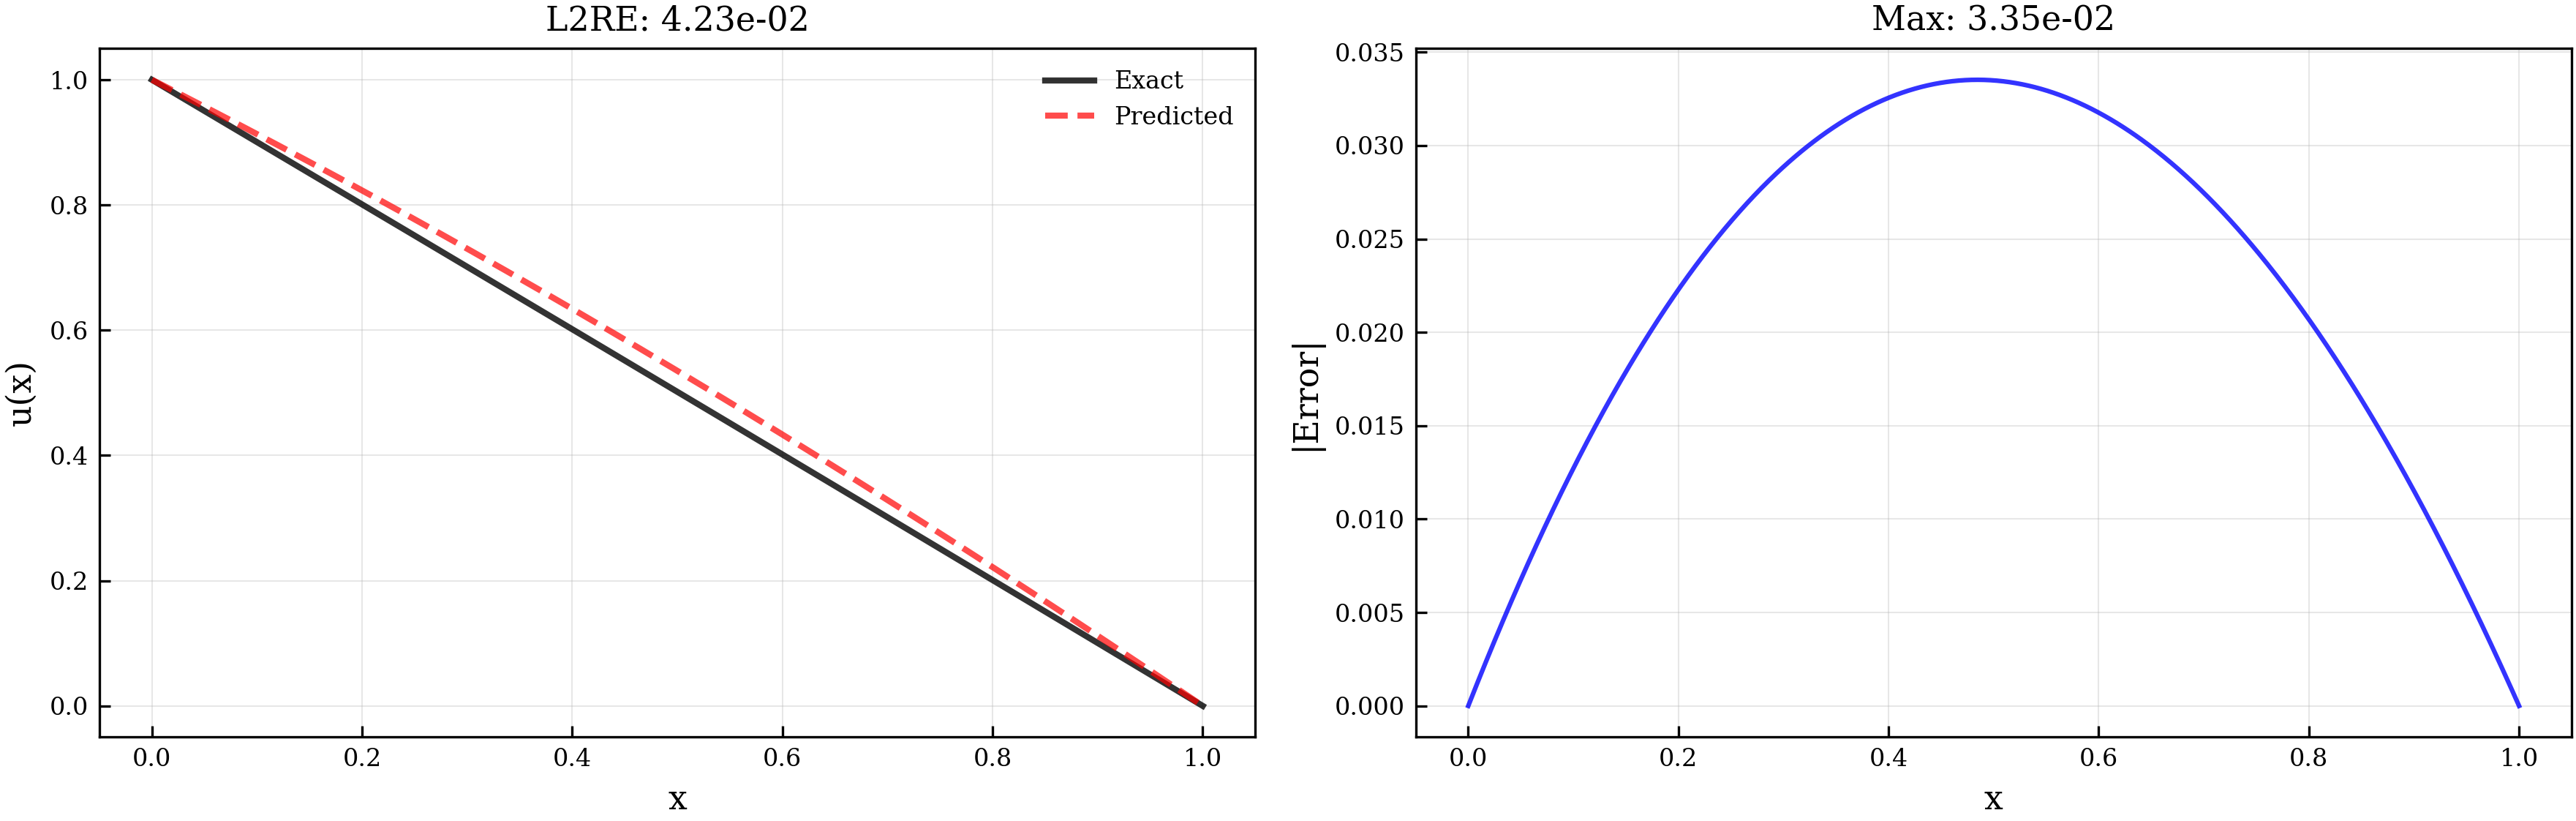

In [ ]:
for dir in fisher_dirs:
  solver = results_fisher[0]["solver"]
  load_path = f"./final_model_states/david_finall/fisher_52/{dir}/solution_epoch_5300.pt"
  solver = load_nets(load_path, solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  print(dir)
  plot_1d_solution_comparison(x, u_pred, u_ref_fisher, filename=f"solution_{dir}".replace(".", "_"), save_dir="./final_plots/fisher")

### Solution exctraction for heatmap creation

In [ ]:
EQUATION_CONFIGS = {
    "allen-cahn_52": {
        "solver": "allen_cahn",
        "parameter_name": "epsilon",
        "parameter_value": 1e-4,
        "x_left": -1.0,
        "x_right": 1.0,
        "x_num": 300,
        "t_start": 0.0,
        "t_end": 1.0,
        "t_num": 300,
    },
    "burgers_52": {
        "solver": "burgers",
        "parameter_name": "nu",
        "parameter_value": 0.01 / np.pi,
        "x_left": 0.0,
        "x_right": 1.0,
        "x_num": 300,
        "t_start": 0.0,
        "t_end": 1.0,
        "t_num": 300,
    },
    "fisher_52": {
        "solver": "fisher",
        "parameter_name": "r",
        "parameter_value": 0.01,
        "x_left": 0.0,
        "x_right": 1.0,
        "x_num": 300,
        "t_start": 0.0,
        "t_end": 1.0,
        "t_num": 300,
    },
}


def build_heatmap_inputs(config, device=None):
    x = torch.linspace(
        config["x_left"],
        config["x_right"],
        config["x_num"],
        device=device,
        requires_grad=True,
    )

    t = torch.linspace(
        config["t_start"],
        config["t_end"],
        config["t_num"],
        device=device,
        requires_grad=True,
    )

    X, T = torch.meshgrid(x, t, indexing="ij")

    P = torch.full_like(
        X,
        config["parameter_value"],
        requires_grad=True,
    )

    return x, t, X, T, P


def build_heatmap_from_solution(config, sol, device=None):
    x, t, X, T, P = build_heatmap_inputs(config, device=device)

    u_pred = sol(X, T, P)

    expected_shape = (config["x_num"], config["t_num"])
    assert u_pred.shape == expected_shape, f"Expected {expected_shape}, got {u_pred.shape}"

    return {
        "x": x,
        "t": t,
        "X": X,
        "T": T,
        "P": P,
        "u_pred": u_pred,
        "parameter_name": config["parameter_name"],
        "parameter_value": config["parameter_value"],
    }


device = device if "device" in globals() else None

heatmaps = {}

models_solvers = [
    ("fisher_52", results_fisher[0]["solver"], fisher_dirs),
    ("burgers_52", results_burgers[0]["solver"], burgers_dirs),
    ("allen-cahn_52", results_allen_cahn[0]["solver"], allen_cahn_dirs),
]

for model_path, model_solver, model_dirs in models_solvers:
  config = EQUATION_CONFIGS[model_path]

  local_heatmap = {}

  for dir in model_dirs:
      load_path = f"./final_model_states/david_finall/{model_path}/{dir}/solution_epoch_5300.pt"

      solver = load_nets(
          load_path,
          model_solver,
          load_best_nets=True,
      )[0]

      sol = solver.get_solution()

      local_heatmap[dir] = build_heatmap_from_solution(
          config=config,
          sol=sol,
          device=device,
      )
  heatmaps[model_path] = local_heatmap


In [ ]:
heatmaps["fisher_52"]["fisher_gPINN_lambda_1e-07"]["u_pred"].shape

torch.Size([300, 300])

In [ ]:
def tensor_to_list(t):
    return t.detach().cpu().numpy().tolist()


def heatmaps_to_json_serializable(heatmaps):
    result = {}

    for model_name, model_data in heatmaps.items():
        result[model_name] = {}

        for dir_name, data in model_data.items():
            result[model_name][dir_name] = {
                "x": tensor_to_list(data["x"]),
                "t": tensor_to_list(data["t"]),
                "u_pred": tensor_to_list(data["u_pred"]),
                "parameter_name": data["parameter_name"],
                "parameter_value": data["parameter_value"],
            }

    return result


json_data = heatmaps_to_json_serializable(heatmaps)

with open("heatmaps.json", "w") as f:
    json.dump(json_data, f)

### Compare plot: Numerical vs Best-Reg vs Vanilla

#### Allen-Cahn

In [ ]:
local_head = 0
dt = 0.001
r_i = 0.0001
t_i = 0.5

x = torch.arange(
    -1.0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_allen_cahn = solve_allen_cahn(r_i, 1e-4, t_i, 0, -1.0, 1.0, dt)

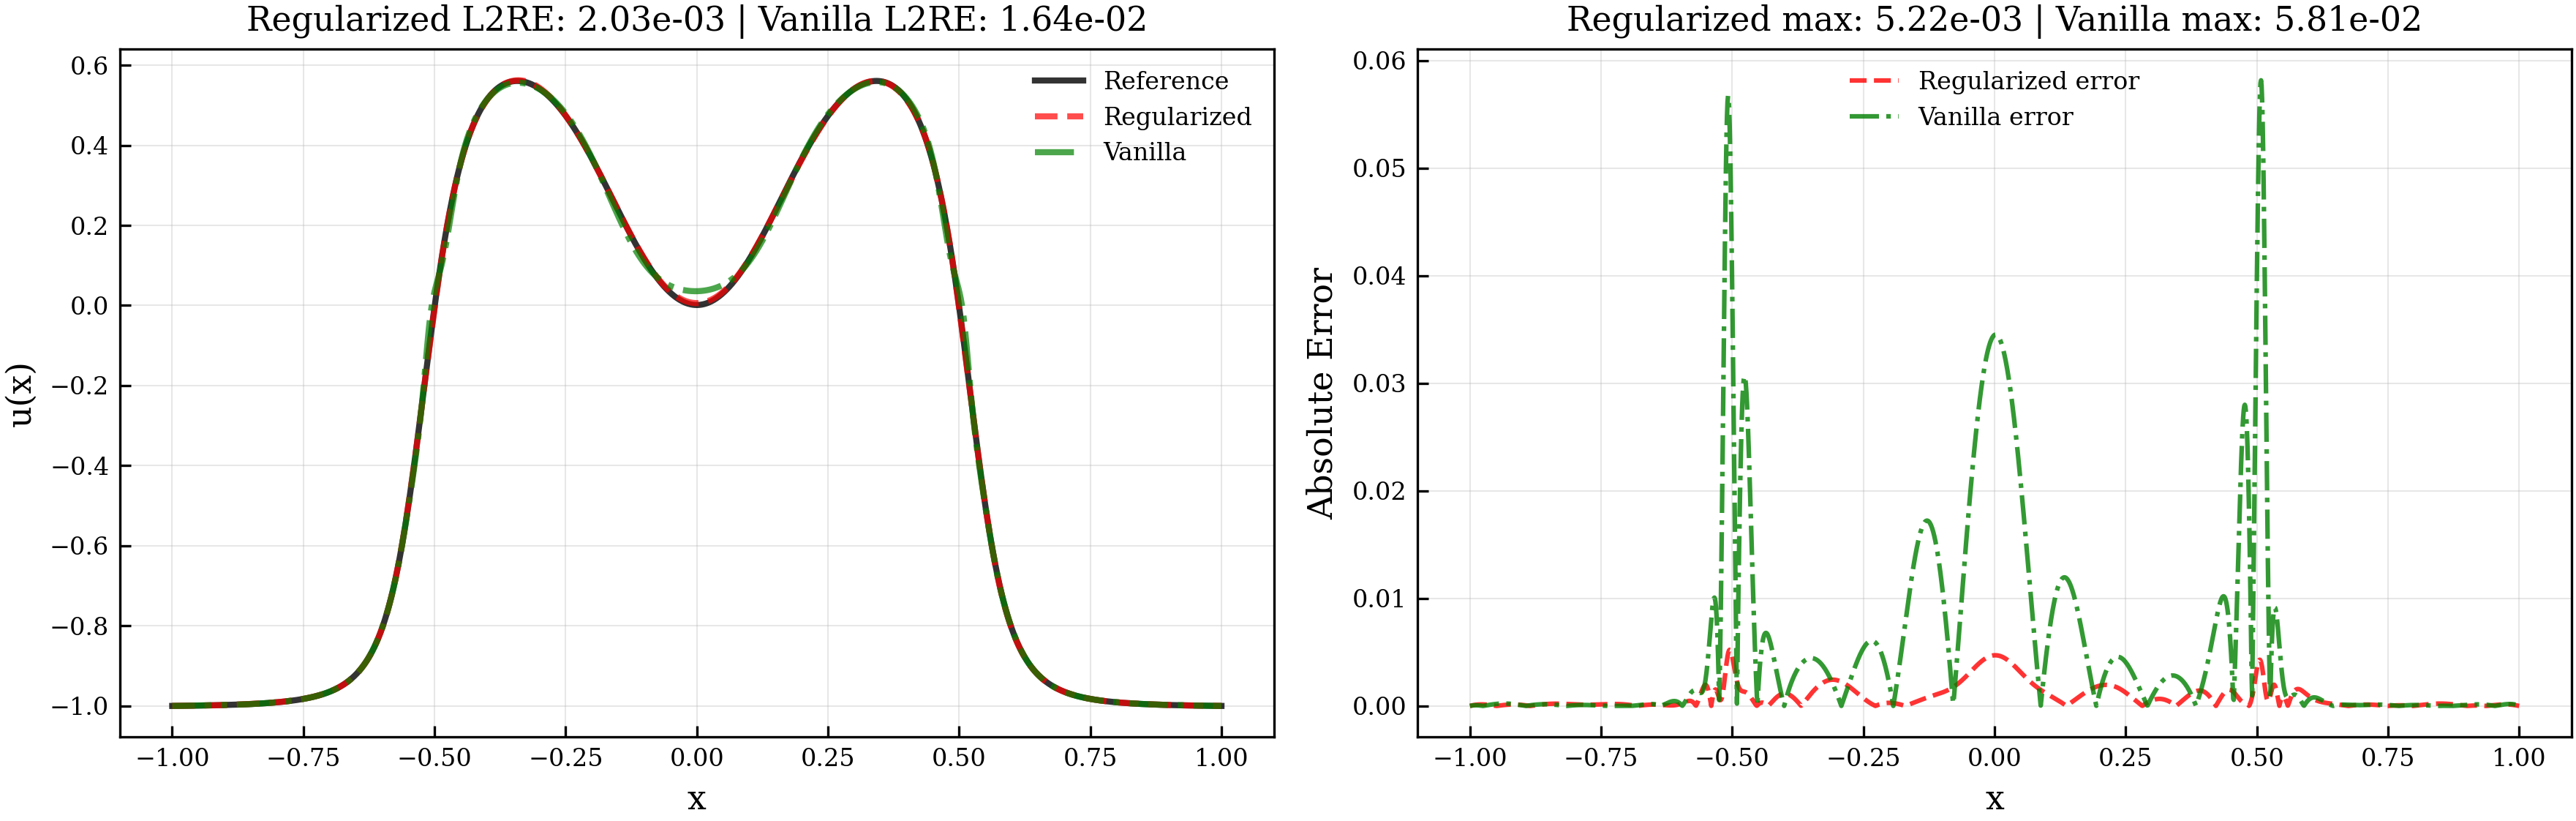

In [ ]:
allen_cahn_predictions = []
for dir in ["allen-cahn_None_lambda_0.0", "allen-cahn_L1_lambda_1e-05"]:
  solver = results_allen_cahn[0]["solver"]
  solver = load_nets(f"./final_model_states/david_finall/allen-cahn_52/{dir}/solution_epoch_5300.pt", solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  allen_cahn_predictions.append(u_pred)

plot_1d_solution_comparison_few(
    x,
    u_ref_allen_cahn,
    allen_cahn_predictions[1],
    allen_cahn_predictions[0],
    filename=f"allen_cahn_baselilne_regular_vanilla_comparison",
    save_dir="./final_plots/allen_cahn"
)


#### Burgers

In [ ]:
local_head = 0
dt = 0.001
r_i = 0.01/np.pi
t_i = 0.5

x = torch.arange(
    0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_burgers = solve_burgers(r_i, 1e-4, t_i, 0, 0, 1.0, dt)

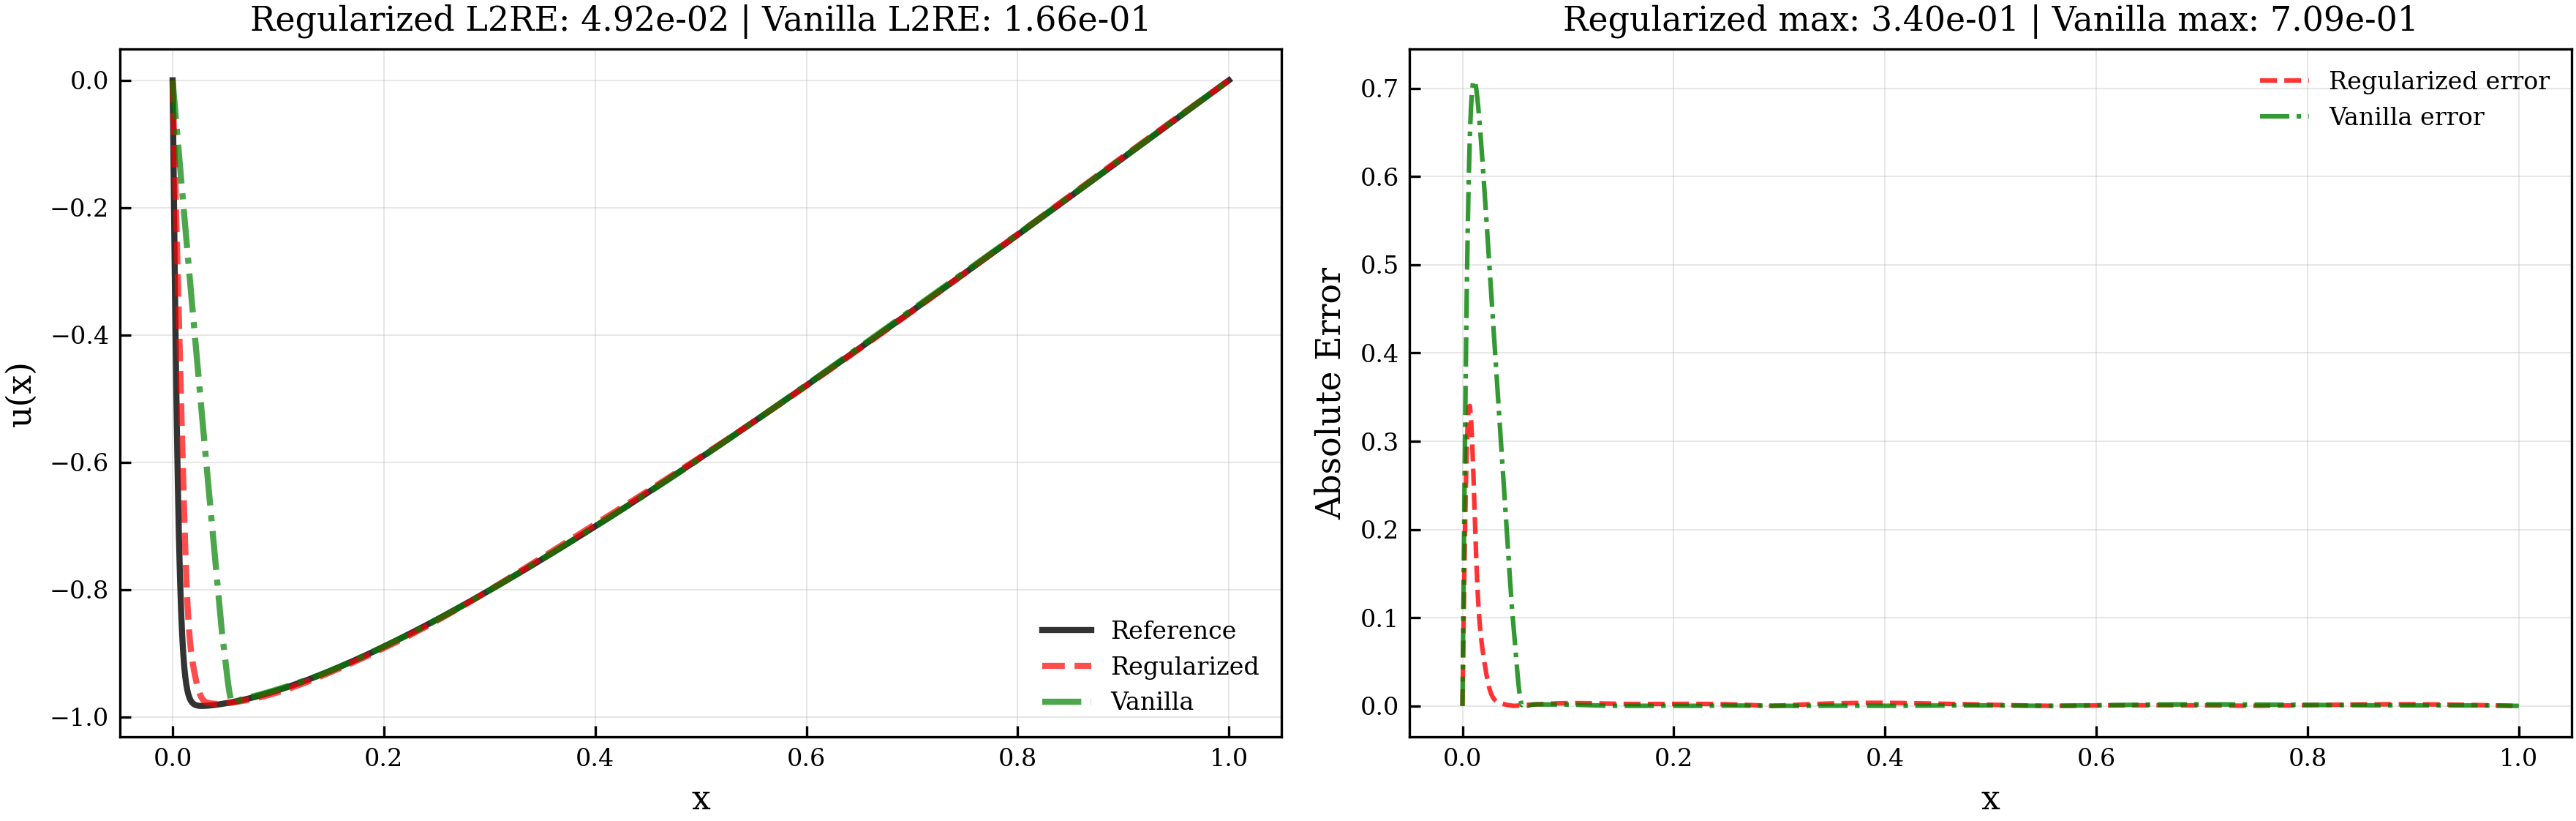

In [ ]:
burgers_predictions = []
for dir in ["burgers_None_lambda_0.0", "burgers_J_lambda_0.1"]:
  solver = results_burgers[0]["solver"]
  load_path = f"./final_model_states/david_finall/burgers_52/{dir}/solution_epoch_5300.pt"
  solver = load_nets(load_path, solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  burgers_predictions.append(u_pred)

plot_1d_solution_comparison_few(
    x,
    u_ref_burgers,
    burgers_predictions[1],
    burgers_predictions[0],
    filename=f"burgers_baselilne_regular_vanilla_comparison",
    save_dir="./final_plots/burgers"
)

#### Fisher


In [ ]:
local_head = 0
dt = 0.001
r_i = 0.1
t_i = 0.5

x = torch.arange(
    0, 1 + dt, dt, requires_grad=True, device=device if "device" in globals() else None
)
t_1d = torch.full_like(x, t_i, requires_grad=True, device=x.device)
r = torch.full_like(x, r_i, requires_grad=True, device=x.device)

_, _, u_ref_fisher = solve_fisher_kpp(r_i, 1e-4, t_i, 0, 0, 1.0, dt)

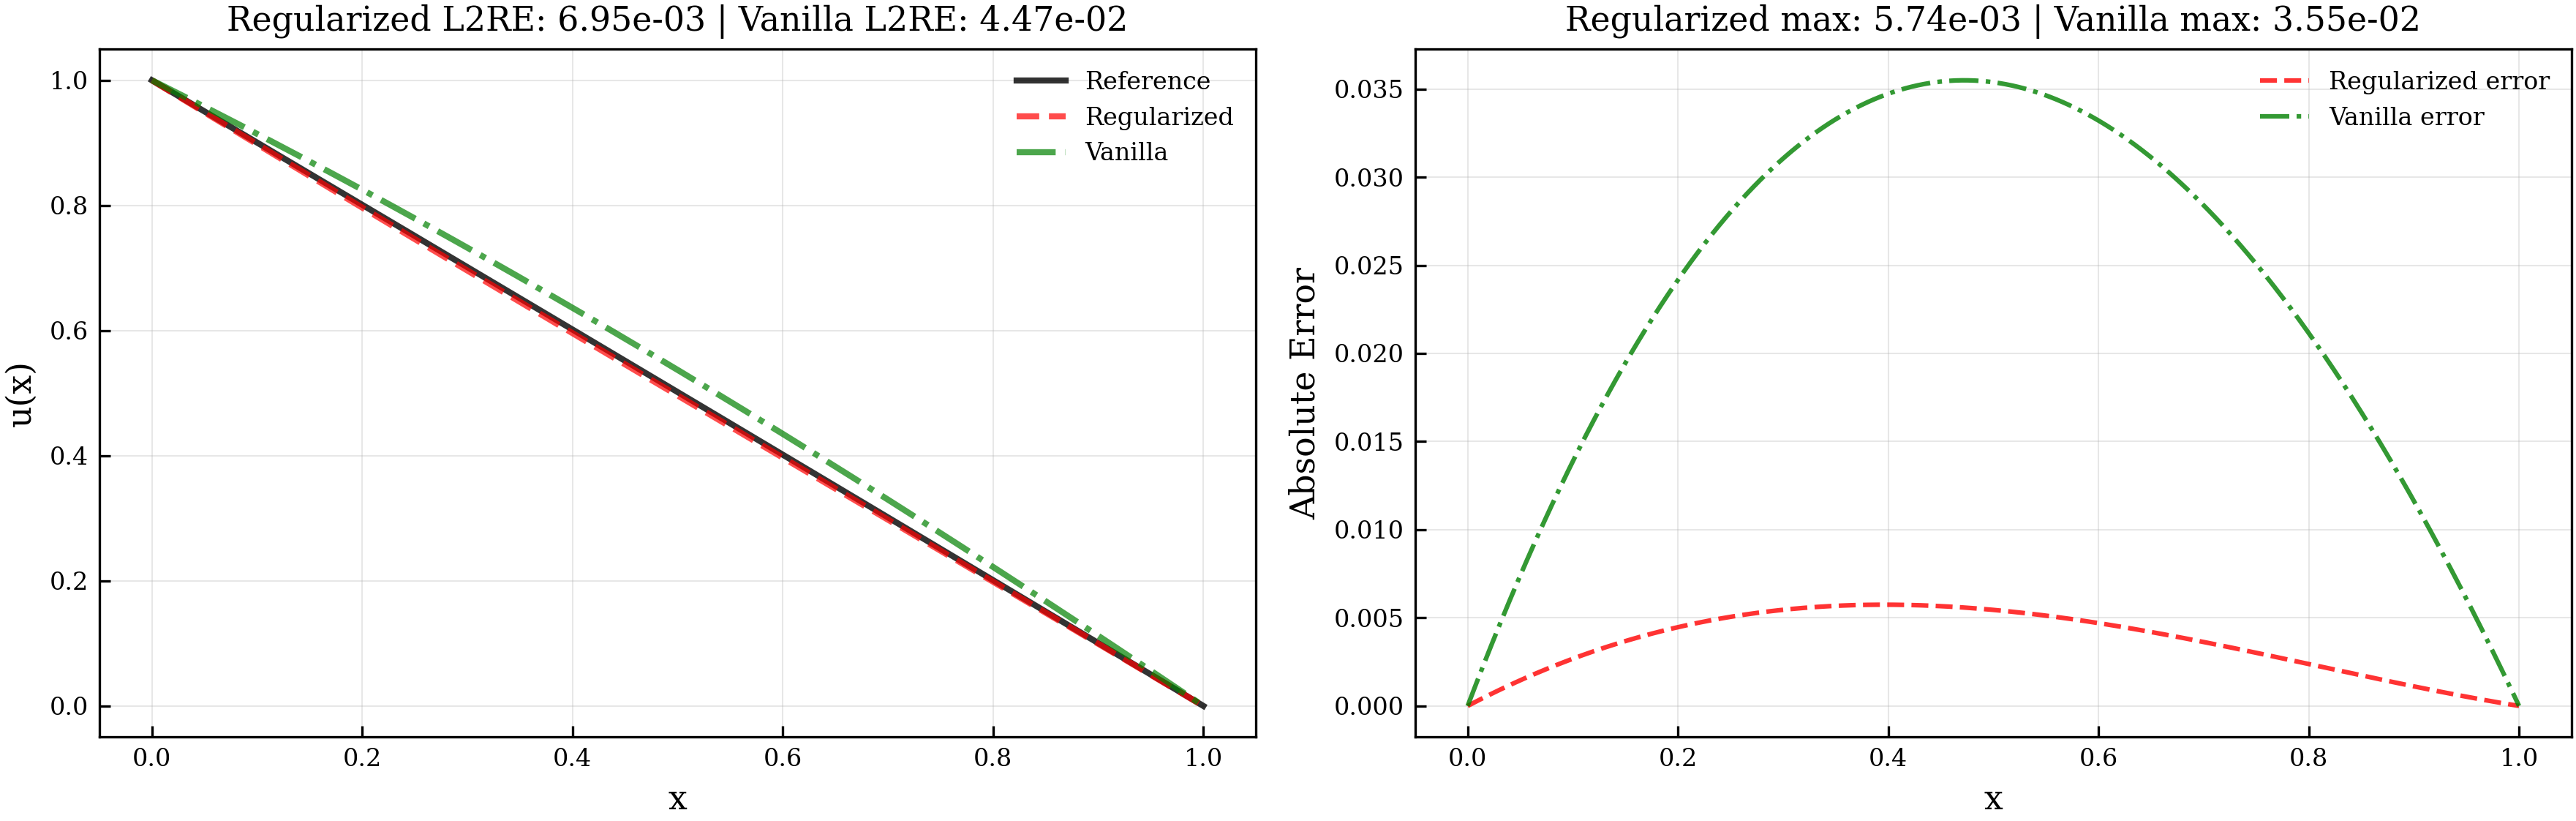

In [ ]:
fisher_predictions = []
for dir in ["fisher_None_lambda_0.0", "fisher_UR_lambda_1e-06"]:
  solver = results_fisher[0]["solver"]
  load_path = f"./final_model_states/david_finall/fisher_52/{dir}/solution_epoch_5300.pt"
  solver = load_nets(load_path, solver, load_best_nets=True)[0]
  sol = solver.get_solution()
  u_pred = sol(x, t_1d, r)
  fisher_predictions.append(u_pred)

plot_1d_solution_comparison_few(
    x,
    u_ref_fisher,
    fisher_predictions[1],
    fisher_predictions[0],
    filename=f"fisher_baselilne_regular_vanilla_comparison",
    save_dir="./final_plots/fisher"

)